# 01 青空文庫 — データ取得・前処理・Word2Vec学習

**このノートブックの目的**

1. 青空文庫から孤独関連テキストを収集する
2. MeCab（fugashi）で形態素解析・トークナイズする
3. Word2Vecモデルを学習する
4. 孤独関連語の意味空間を可視化する

**分析の問い（Phase 1）**
- 「孤独」「孤立」「孤高」はどんな語と共起しているか？
- 時代（明治 / 大正 / 昭和）で意味空間は変わるか？
- Loneliness / Isolation / Solitude の方向ベクトルはデータから確認できるか？

---
> **注意**：青空文庫のテキストは著作権切れ作品が中心（概ね没後70年）。
> 明治〜昭和中期が主なカバー範囲になる。

---
## セッションが切れた場合の再開手順
1. 「ランタイム → すべてのセルを実行」で上から流し直す
2. ダウンロード済みの場合はparquetから読み込むのでスキップされる
3. Google Driveのデータは保持されるので再ダウンロード不要

## 0-A. Google Driveのマウント
データをGoogle Driveに保存することでセッションが切れてもデータが消えない。

In [209]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# データ保存先をGoogle Driveに設定
DATA_DIR = Path('/content/drive/MyDrive/loneliness-research-data')
RAW_DIR = DATA_DIR / 'raw' / 'aozora'
PROCESSED_DIR = DATA_DIR / 'processed' / 'aozora'
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('Google Drive マウント完了')
print(f'データ保存先: {DATA_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive マウント完了
データ保存先: /content/drive/MyDrive/loneliness-research-data


## 0-B. 環境セットアップ

In [210]:
# ライブラリのインストール（Colab用）
!pip install fugashi unidic-lite gensim umap-learn japanize-matplotlib jaconv -q
print('インストール完了')

インストール完了


In [211]:
import os
import re
import gc
import time
import zipfile
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns

import fugashi
import jaconv
from gensim.models import Word2Vec

# 再現性のためシードを固定
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('セットアップ完了')
print(f'  データ保存先: {RAW_DIR}')

セットアップ完了
  データ保存先: /content/drive/MyDrive/loneliness-research-data/raw/aozora


---
## 1. 青空文庫からテキストを取得する

In [212]:
# 青空文庫の作品リスト（CSV）を取得する
CATALOG_URL = 'https://www.aozora.gr.jp/index_pages/list_person_all_extended_utf8.zip'
CATALOG_ZIP = RAW_DIR / 'catalog.zip'
CATALOG_CSV = RAW_DIR / 'list_person_all_extended_utf8.csv'

if not CATALOG_CSV.exists():
    print('作品リストをダウンロード中...')
    urllib.request.urlretrieve(CATALOG_URL, CATALOG_ZIP)
    with zipfile.ZipFile(CATALOG_ZIP, 'r') as zf:
        zf.extractall(RAW_DIR)
    print('完了')
else:
    print('作品リストは取得済み')

df_catalog = pd.read_csv(CATALOG_CSV, encoding='utf-8')
print(f'総作品数: {len(df_catalog):,}')

作品リストは取得済み
総作品数: 19,456


In [213]:
# 時代ラベルを付与する
def assign_era(birth_date_str):
    """生年月日から時代ラベルを返す"""
    try:
        year = int(str(birth_date_str)[:4])
        if year < 1868:
            return '江戸以前'
        elif year < 1900:
            return '明治'
        elif year < 1912:
            return '明治後期〜大正'
        elif year < 1926:
            return '大正〜昭和初期'
        elif year < 1945:
            return '昭和戦前'
        else:
            return '昭和戦後以降'
    except:
        return '不明'

df_catalog['era'] = df_catalog['生年月日'].apply(assign_era)
print(df_catalog['era'].value_counts())

era
明治         12459
明治後期〜大正     3597
江戸以前        1970
大正〜昭和初期      665
不明           398
昭和戦後以降       231
昭和戦前         136
Name: count, dtype: int64


In [214]:
# カラム名を確定版で設定
TEXT_URL_COL = 'テキストファイルURL'
TITLE_COL = '作品名'
AUTHOR_COL = '姓'

# テキストURLがあり、江戸以前と不明を除いた作品に絞る
df_target = df_catalog[
    df_catalog[TEXT_URL_COL].notna() &
    (~df_catalog['era'].isin(['不明', '江戸以前']))
].copy()

print(f'対象作品数: {len(df_target):,}')
print(df_target['era'].value_counts())

対象作品数: 16,863
era
明治         12445
明治後期〜大正     3579
大正〜昭和初期      651
昭和戦後以降       114
昭和戦前          74
Name: count, dtype: int64


In [215]:
# テキストをダウンロード・クリーニングする関数
def download_aozora_text(url, save_path):
    try:
        tmp_zip = str(save_path) + '.zip'
        urllib.request.urlretrieve(url, tmp_zip)
        with zipfile.ZipFile(tmp_zip, 'r') as zf:
            txt_files = [f for f in zf.namelist() if f.endswith('.txt')]
            if not txt_files:
                return None
            with zf.open(txt_files[0]) as f:
                try:
                    content = f.read().decode('shift-jis')
                except:
                    content = f.read().decode('utf-8', errors='ignore')
        os.remove(tmp_zip)
        return content
    except Exception as e:
        print(f'  エラー: {e}')
        return None


def clean_aozora_text(text):
    if text is None:
        return ''
    if '-------' in text:
        text = text.split('-------')[-1]
    text = re.sub(r'《[^》]*》', '', text)
    text = re.sub(r'［＃[^］]*］', '', text)
    text = re.sub(r'｜', '', text)
    text = jaconv.z2h(text, kana=False, ascii=True, digit=True)
    text = text.replace('\r\n', '\n').replace('\r', '\n')
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


print('関数定義完了')

関数定義完了


In [216]:
# 保存済みデータを読み込む（ダウンロード済みの場合はスキップ）
parquet_path = PROCESSED_DIR / 'corpus_full.parquet'

if parquet_path.exists():
    df_corpus_full = pd.read_parquet(parquet_path)
    print(f'保存済みデータを読み込みました: {len(df_corpus_full)}作品')
    print(df_corpus_full['era'].value_counts())
else:
    # 初回のみダウンロード実行（20〜30分かかる）
    ERA_LIMITS = {
        '明治':         200,
        '明治後期〜大正': 200,
        '大正〜昭和初期': 200,
        '昭和戦前':      74,
        '昭和戦後以降':  114,
    }
    df_full = (
        df_target
        .groupby('era', group_keys=False)
        .apply(lambda x: x.sample(
            min(ERA_LIMITS.get(x.name, len(x)), len(x)),
            random_state=RANDOM_SEED
        ), include_groups=False)
    )
    print(f'取得予定: {len(df_full)}作品')

    corpus_full = []
    errors = []
    for i, row in df_full.iterrows():
        url = row[TEXT_URL_COL]
        era = row['era']
        title = row[TITLE_COL]
        author = row[AUTHOR_COL]
        text = download_aozora_text(url, RAW_DIR / f'{i}.txt')
        cleaned = clean_aozora_text(text)
        if cleaned and len(cleaned) > 500:
            corpus_full.append({'text': cleaned, 'era': era, 'title': title, 'author': author})
        else:
            errors.append(title)
        time.sleep(0.3)

    print(f'取得完了: {len(corpus_full)}作品 / スキップ: {len(errors)}作品')
    df_corpus_full = pd.DataFrame(corpus_full)
    df_corpus_full.to_parquet(parquet_path, index=False)
    print('保存完了')

保存済みデータを読み込みました: 694作品
era
明治         192
明治後期〜大正    184
大正〜昭和初期    152
昭和戦後以降     102
昭和戦前        64
Name: count, dtype: int64


---
## 2. 形態素解析・トークナイズ

In [217]:
# 形態素解析の設定
tagger = fugashi.Tagger()
TARGET_POS = {'名詞', '動詞', '形容詞', '副詞', '代名詞'}

def tokenize(text, pos_filter=TARGET_POS):
    sentences = []
    current = []
    for word in tagger(text):
        pos = word.feature.pos1
        surface = word.surface
        if surface in {'。', '！', '？', '\n\n'}:
            if len(current) >= 3:
                sentences.append(current)
            current = []
            continue
        if pos not in pos_filter:
            continue
        try:
            lemma = word.feature.lemma
            token = lemma if (lemma and lemma != '*') else surface
        except:
            token = surface
        token = token.split('-')[0]
        min_len = 1 if pos == '代名詞' else 2
        if len(token) < min_len or token.isnumeric():
            continue
        current.append(token)
    if len(current) >= 3:
        sentences.append(current)
    return sentences

# 動作確認
test_text = '彼は孤独を感じていた。その孤立した日々の中で、ひとり静かに書き続けた。'
print('テスト結果:')
for sent in tokenize(test_text):
    print(' ', sent)

テスト結果:
  ['彼', '孤独', '感ずる', '居る']
  ['孤立', '為る', '日々', '一人', '書く', '続ける']


3/14 古いpickleを削除して再トークナイズ

In [218]:
import os

# 古いpickleを削除して再トークナイズを強制する
for path in [SENTENCES_PATH, ERA_SENTENCES_PATH]:
    if path.exists():
        os.remove(path)
        print(f"削除: {path}")

削除: /content/drive/MyDrive/loneliness-research-data/processed/aozora/sentences_full.pkl
削除: /content/drive/MyDrive/loneliness-research-data/processed/aozora/era_sentences_full.pkl


元のコードに戻る

In [219]:
import pickle

# 全量コーパスで形態素解析（都度保存でメモリ節約）
SENTENCES_PATH = PROCESSED_DIR / 'sentences_full.pkl'
ERA_SENTENCES_PATH = PROCESSED_DIR / 'era_sentences_full.pkl'

if SENTENCES_PATH.exists() and ERA_SENTENCES_PATH.exists():
    print('トークナイズ済みデータを読み込み中...')
    with open(SENTENCES_PATH, 'rb') as f:
        all_sentences_full = pickle.load(f)
    with open(ERA_SENTENCES_PATH, 'rb') as f:
        era_sentences_full = pickle.load(f)
    print(f'読み込み完了: 総文数 {len(all_sentences_full):,}')
else:
    print('トークナイズ開始...')
    all_sentences_full = []
    era_sentences_full = {}

    BATCH_SIZE = 20  # 小さくしてメモリ節約

    for batch_start in range(0, len(df_corpus_full), BATCH_SIZE):
        batch = df_corpus_full.iloc[batch_start:batch_start + BATCH_SIZE]
        for _, row in batch.iterrows():
            # テキストを段落単位に分割して一度に処理する量を減らす
            paragraphs = row['text'].split('\n\n')
            for para in paragraphs:
                if len(para) < 10:
                    continue
                sentences = tokenize(para)
                all_sentences_full.extend(sentences)
                era = row['era']
                if era not in era_sentences_full:
                    era_sentences_full[era] = []
                era_sentences_full[era].extend(sentences)
        gc.collect()
        print(f'  {min(batch_start + BATCH_SIZE, len(df_corpus_full))} / {len(df_corpus_full)}作品処理済み')

    # 処理完了後に保存
    print('保存中...')
    with open(SENTENCES_PATH, 'wb') as f:
        pickle.dump(all_sentences_full, f)
    with open(ERA_SENTENCES_PATH, 'wb') as f:
        pickle.dump(era_sentences_full, f)
    print('保存完了')

print(f'\n総文数: {len(all_sentences_full):,}')
for era, sents in sorted(era_sentences_full.items()):
    print(f'  {era}: {len(sents):,}文')

トークナイズ開始...
  20 / 694作品処理済み
  40 / 694作品処理済み
  60 / 694作品処理済み
  80 / 694作品処理済み
  100 / 694作品処理済み
  120 / 694作品処理済み
  140 / 694作品処理済み
  160 / 694作品処理済み
  180 / 694作品処理済み
  200 / 694作品処理済み
  220 / 694作品処理済み
  240 / 694作品処理済み
  260 / 694作品処理済み
  280 / 694作品処理済み
  300 / 694作品処理済み
  320 / 694作品処理済み
  340 / 694作品処理済み
  360 / 694作品処理済み
  380 / 694作品処理済み
  400 / 694作品処理済み
  420 / 694作品処理済み
  440 / 694作品処理済み
  460 / 694作品処理済み
  480 / 694作品処理済み
  500 / 694作品処理済み
  520 / 694作品処理済み
  540 / 694作品処理済み
  560 / 694作品処理済み
  580 / 694作品処理済み
  600 / 694作品処理済み
  620 / 694作品処理済み
  640 / 694作品処理済み
  660 / 694作品処理済み
  680 / 694作品処理済み
  694 / 694作品処理済み
保存中...
保存完了

総文数: 233,571
  大正〜昭和初期: 28,568文
  明治: 53,918文
  明治後期〜大正: 37,690文
  昭和戦前: 62,946文
  昭和戦後以降: 50,449文


---
## 3. Word2Vecモデルの学習

In [220]:
W2V_PARAMS = dict(
    vector_size=100,
    window=5,
    min_count=3,
    sg=1,
    epochs=10,
    workers=4,
    seed=RANDOM_SEED,
)

print('Word2Vec学習中...')
model = Word2Vec(sentences=all_sentences_full, **W2V_PARAMS)
print(f'語彙数: {len(model.wv):,}')
model.save(str(PROCESSED_DIR / 'w2v_aozora_all.model'))
print('モデル保存完了')

Word2Vec学習中...
語彙数: 35,115
モデル保存完了


In [221]:
# 孤独関連語の類似語を確認
SEED_WORDS = ['孤独', '孤立', '孤高', '寂しい', 'ひとり', '一人']

for word in SEED_WORDS:
    if word in model.wv:
        similar = model.wv.most_similar(word, topn=10)
        print(f'\n【{word}】に近い語:')
        for w, score in similar:
            print(f'  {w:10s}  {score:.3f}')
    else:
        print(f'\n【{word}】: 語彙になし')


【孤独】に近い語:
  天涯          0.783
  悲哀          0.773
  罪悪          0.755
  捌け口         0.749
  生き甲斐        0.733
  隣人          0.728
  寂寥          0.719
  世俗          0.718
  思慕          0.716
  情欲          0.713

【孤立】に近い語:
  活力          0.807
  阻害          0.801
  浸潤          0.799
  根強い         0.798
  闘志          0.796
  増殖          0.795
  断固          0.795
  阻む          0.791
  友好          0.788
  萌芽          0.787

【孤高】に近い語:
  生育          0.917
  堕する         0.916
  詩論          0.913
  審美          0.911
  比肩          0.908
  開眼          0.908
  理会          0.907
  打ち立てる       0.906
  プレボ         0.906
  撞着          0.903

【寂しい】に近い語:
  恋しい         0.689
  うらぶれる       0.680
  晴々          0.677
  心細い         0.676
  悲しい         0.668
  侘しい         0.666
  ひもじい        0.661
  旅先          0.656
  競馬          0.656
  徒然          0.653

【ひとり】: 語彙になし

【一人】に近い語:
  馬番          0.568
  年輩          0.539
  忘れ掛ける       0.536
  ポリネシア       0.535
  俳人          0.529
  独り者         0.528
  男性      

---
## 4. 孤独語の意味空間を可視化する（UMAP）

In [222]:
# 三分類のSeed語彙
LONELINESS_SEEDS = ['孤独', '寂しい', '悲しい', '虚しい', '空虚', '疎外', '取り残す', '心細い']
ISOLATION_SEEDS  = ['孤立', '断絶', '疎遠', '引きこもる', '排除', '遠ざかる', '孤立無援']
SOLITUDE_SEEDS   = ['孤高', '独り', '静かだ', '自由', '内省', '沈黙', '一人']
CONNECTION_SEEDS = ['友人', '家族', '絆', 'つながる', '仲間', '集う', '愛する']

def filter_vocab(words, model):
    return [w for w in words if w in model.wv]

loneliness_words = filter_vocab(LONELINESS_SEEDS, model)
isolation_words  = filter_vocab(ISOLATION_SEEDS, model)
solitude_words   = filter_vocab(SOLITUDE_SEEDS, model)
connection_words = filter_vocab(CONNECTION_SEEDS, model)

print('可視化対象語数:')
print(f'  Loneliness: {len(loneliness_words)} → {loneliness_words}')
print(f'  Isolation:  {len(isolation_words)} → {isolation_words}')
print(f'  Solitude:   {len(solitude_words)} → {solitude_words}')
print(f'  Connection: {len(connection_words)} → {connection_words}')

可視化対象語数:
  Loneliness: 7 → ['孤独', '寂しい', '悲しい', '空虚', '疎外', '取り残す', '心細い']
  Isolation:  4 → ['孤立', '断絶', '排除', '遠ざかる']
  Solitude:   6 → ['孤高', '独り', '自由', '内省', '沈黙', '一人']
  Connection: 5 → ['友人', '家族', '仲間', '集う', '愛する']


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


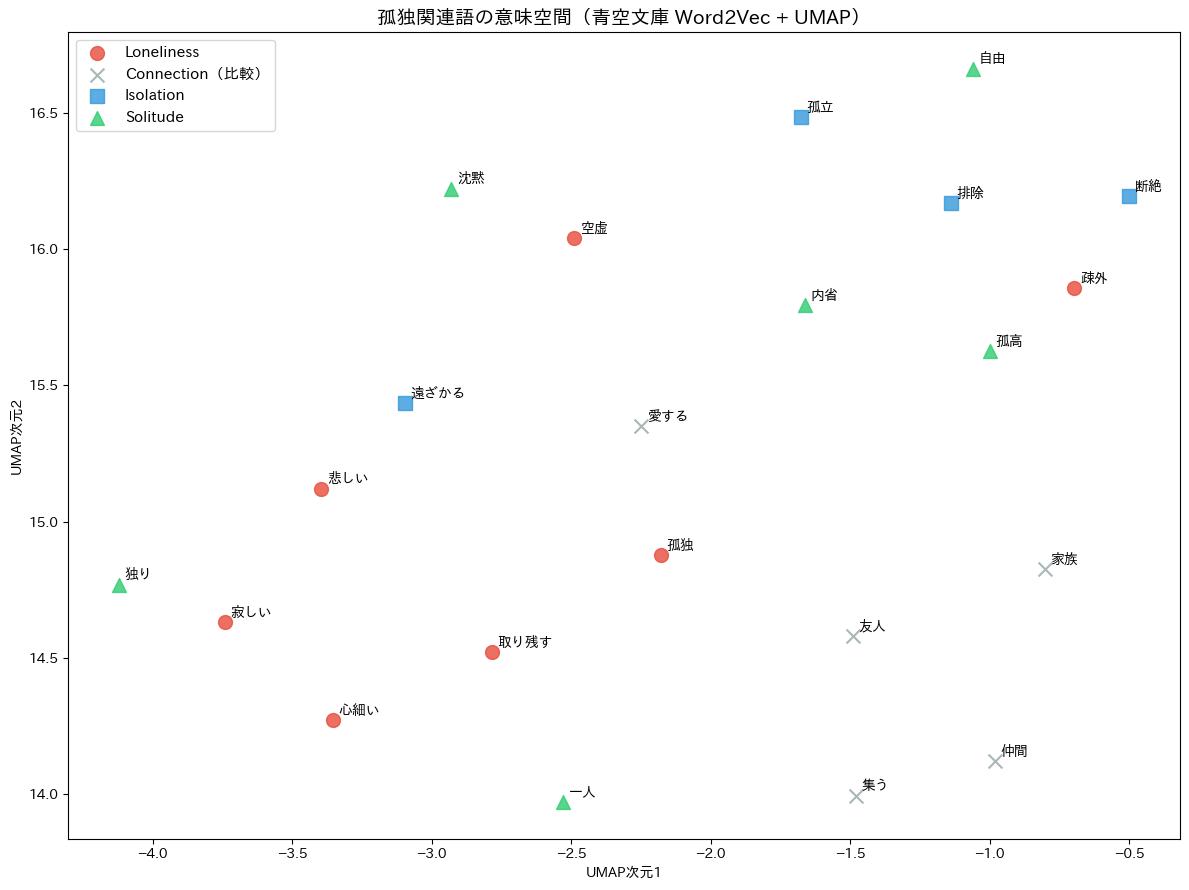

図を保存しました


In [223]:
import umap.umap_ as umap

viz_words = loneliness_words + isolation_words + solitude_words + connection_words
viz_labels = (
    ['Loneliness'] * len(loneliness_words) +
    ['Isolation']  * len(isolation_words) +
    ['Solitude']   * len(solitude_words) +
    ['Connection（比較）'] * len(connection_words)
)

vectors = np.array([model.wv[w] for w in viz_words])

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=min(10, len(viz_words)-1),
    random_state=RANDOM_SEED,
    metric='cosine'
)
embedding = reducer.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(12, 9))
COLORS  = {'Loneliness': '#E74C3C', 'Isolation': '#3498DB', 'Solitude': '#2ECC71', 'Connection（比較）': '#95A5A6'}
MARKERS = {'Loneliness': 'o',       'Isolation': 's',       'Solitude': '^',       'Connection（比較）': 'x'}

for label in set(viz_labels):
    idx = [i for i, l in enumerate(viz_labels) if l == label]
    ax.scatter(embedding[idx, 0], embedding[idx, 1],
               c=COLORS[label], marker=MARKERS[label], s=100, label=label, alpha=0.8)

for i, (word, label) in enumerate(zip(viz_words, viz_labels)):
    ax.annotate(word, (embedding[i, 0], embedding[i, 1]),
                fontsize=10, textcoords='offset points', xytext=(4, 4))

ax.legend(fontsize=11)
ax.set_title('孤独関連語の意味空間（青空文庫 Word2Vec + UMAP）', fontsize=14)
ax.set_xlabel('UMAP次元1')
ax.set_ylabel('UMAP次元2')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'umap_loneliness_words.png', dpi=150)
plt.show()
print('図を保存しました')

---
## 5. 方向ベクトルの試作（Loneliness / Isolation / Solitude 軸）

In [224]:
from numpy.linalg import norm

def make_axis_vector(seed_words, model):
    vecs = [model.wv[w] for w in seed_words if w in model.wv]
    if not vecs:
        return None
    axis = np.mean(vecs, axis=0)
    return axis / norm(axis)

def score_on_axis(word, axis_vector, model):
    if word not in model.wv or axis_vector is None:
        return None
    wv = model.wv[word]
    return float(np.dot(wv, axis_vector) / (norm(wv) * norm(axis_vector)))

axis_loneliness = make_axis_vector(loneliness_words, model)
axis_isolation  = make_axis_vector(isolation_words, model)
axis_solitude   = make_axis_vector(solitude_words, model)

print('軸ベクトル作成完了')
print(f'  Loneliness軸: {len(loneliness_words)}語から')
print(f'  Isolation軸:  {len(isolation_words)}語から')
print(f'  Solitude軸:   {len(solitude_words)}語から')

軸ベクトル作成完了
  Loneliness軸: 7語から
  Isolation軸:  4語から
  Solitude軸:   6語から


In [225]:
# 孤独周辺語を3軸でスコアリング
TARGET_WORDS_FOR_SCORING = [
    '孤独', '孤立', '孤高', '寂しい', '独り', '一人',
    '悲しい', '自由', '静かだ', '断絶', '友人', '家族', '愛する',
    '夜', '部屋', '窓', '海', '空'
]

rows = []
for word in TARGET_WORDS_FOR_SCORING:
    if word not in model.wv:
        continue
    rows.append({
        'word': word,
        'Loneliness': score_on_axis(word, axis_loneliness, model),
        'Isolation':  score_on_axis(word, axis_isolation, model),
        'Solitude':   score_on_axis(word, axis_solitude, model),
    })

df_scores = pd.DataFrame(rows).set_index('word')
print(df_scores.round(3).to_string())

      Loneliness  Isolation  Solitude
word                                 
孤独         0.843      0.575     0.662
孤立         0.592      0.877     0.596
孤高         0.645      0.708     0.686
寂しい        0.802      0.447     0.518
独り         0.546      0.378     0.670
一人         0.458      0.375     0.593
悲しい        0.758      0.443     0.514
自由         0.352      0.417     0.654
断絶         0.463      0.747     0.605
友人         0.342      0.297     0.394
家族         0.523      0.452     0.481
愛する        0.529      0.466     0.542
部屋         0.329      0.263     0.300


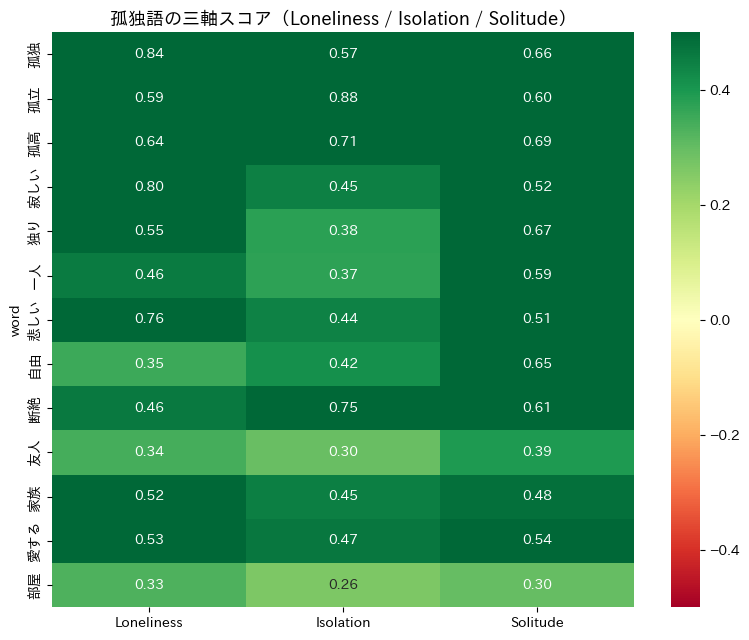

In [226]:
# ヒートマップで可視化
fig, ax = plt.subplots(figsize=(8, max(4, len(df_scores) * 0.5)))
sns.heatmap(df_scores, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.5, ax=ax)
ax.set_title('孤独語の三軸スコア（Loneliness / Isolation / Solitude）', fontsize=13)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'axis_scores_heatmap.png', dpi=150)
plt.show()

---
## 6. 時代別比較

In [227]:
# 時代別モデルを学習
era_models = {}

for era, sents in sorted(era_sentences_full.items()):
    if len(sents) < 100:
        print(f'[{era}] データ不足でスキップ ({len(sents)}文)')
        continue
    print(f'[{era}] 学習中... ({len(sents):,}文)', end='')
    m = Word2Vec(sentences=sents, **W2V_PARAMS)
    era_models[era] = m
    print(f' 完了（語彙数: {len(m.wv):,}）')

print(f'\n学習済み時代: {list(era_models.keys())}')

[大正〜昭和初期] 学習中... (28,568文) 完了（語彙数: 9,838）
[明治] 学習中... (53,918文) 完了（語彙数: 17,669）
[明治後期〜大正] 学習中... (37,690文) 完了（語彙数: 13,480）
[昭和戦前] 学習中... (62,946文) 完了（語彙数: 12,142）
[昭和戦後以降] 学習中... (50,449文) 完了（語彙数: 13,419）

学習済み時代: ['大正〜昭和初期', '明治', '明治後期〜大正', '昭和戦前', '昭和戦後以降']


In [228]:
# 時代別の「孤独」類似語比較
FOCUS_WORD = '孤独'

for era, m in sorted(era_models.items()):
    if FOCUS_WORD in m.wv:
        similar = m.wv.most_similar(FOCUS_WORD, topn=10)
        print(f'\n【{era}】「{FOCUS_WORD}」に近い語:')
        for w, s in similar:
            print(f'  {w:12s} {s:.3f}')
    else:
        print(f'\n【{era}】「{FOCUS_WORD}」は語彙になし')


【大正〜昭和初期】「孤独」に近い語:
  感傷           0.927
  魅力           0.927
  引き付ける        0.918
  陥る           0.908
  境遇           0.907
  感覚           0.907
  思い出          0.906
  最早           0.904
  極めて          0.904
  ナカツ          0.904

【明治】「孤独」に近い語:
  痛切           0.935
  聡明           0.934
  感傷           0.929
  失策           0.923
  戯れ           0.914
  嫉妬           0.914
  妄想           0.914
  染み染み         0.909
  公子           0.909
  悲哀           0.908

【明治後期〜大正】「孤独」に近い語:
  感傷           0.916
  捕らわれる        0.892
  直面           0.886
  肉親           0.885
  ソビヱット        0.883
  綱渡り          0.882
  愛人           0.882
  運命           0.879
  憎悪           0.877
  悲しむ          0.877

【昭和戦前】「孤独」に近い語:
  野心           0.843
  苦悩           0.829
  悲しみ          0.828
  エゴイズム        0.827
  嫌悪           0.823
  不潔           0.823
  妄想           0.822
  振る舞う         0.817
  悔い           0.813
  悩み           0.813

【昭和戦後以降】「孤独」に近い語:
  盛る           0.952
  痩せ衰える        0.943
  輝き           0.939
  伝う  

3/11 分類語彙表における孤独同一クラスター語出現頻度確認

In [229]:
check = ['憂鬱', '鬱屈', '抑鬱', '煩悶', '憂い', '物憂さ', '虚ろ', 'ひとりぼっち', '孤独感']
for w in check:
    if w in model.wv:
        print(f"{w}: {model.wv.get_vecattr(w, 'count')}回")
    else:
        print(f"{w}: ★語彙外")

憂鬱: 138回
鬱屈: 6回
抑鬱: ★語彙外
煩悶: 31回
憂い: 75回
物憂さ: ★語彙外
虚ろ: ★語彙外
ひとりぼっち: ★語彙外
孤独感: ★語彙外


In [230]:
check_all = [
    # Loneliness現候補
    '寂しい', '寂しさ', '淋しい', '空虚', '虚しい', '心細い',
    # Isolation候補
    '孤立', '断絶', '孤絶', '隔絶', '疎遠', '絶縁', '無縁', '排除', '追放','独身','単身','身一つ','未婚','ひとり身','天涯孤独','四面楚歌','孤立無縁',
    # Solitude候補
    '孤高', '隠遁', '独居', '静寂', '沈黙', '内省','独身貴族',
]
for w in check_all:
    if w in model.wv:
        print(f"{w}: {model.wv.get_vecattr(w, 'count')}回")
    else:
        print(f"{w}: ★語彙外")

寂しい: 567回
寂しさ: ★語彙外
淋しい: ★語彙外
空虚: 55回
虚しい: ★語彙外
心細い: 91回
孤立: 40回
断絶: 6回
孤絶: ★語彙外
隔絶: 4回
疎遠: ★語彙外
絶縁: 9回
無縁: ★語彙外
排除: 17回
追放: 40回
独身: 89回
単身: 10回
身一つ: ★語彙外
未婚: 12回
ひとり身: ★語彙外
天涯孤独: ★語彙外
四面楚歌: ★語彙外
孤立無縁: ★語彙外
孤高: 4回
隠遁: 6回
独居: ★語彙外
静寂: 43回
沈黙: 200回
内省: 13回
独身貴族: ★語彙外


In [231]:
for word in ['沈黙', '静寂', '孤高', '隠遁']:
    if word in model.wv:
        print(f"\n{word}の近傍語:")
        for w, s in model.wv.most_similar(word, topn=10):
            print(f"  {w}: {s:.3f}")


沈黙の近傍語:
  爆笑: 0.658
  嘆声: 0.653
  黙祷: 0.652
  残留: 0.649
  息遣い: 0.649
  礼拝: 0.647
  静寂: 0.636
  呟き: 0.630
  物思い: 0.627
  余韻: 0.624

静寂の近傍語:
  静けさ: 0.831
  余韻: 0.817
  銃声: 0.816
  囁き: 0.807
  騒めき: 0.800
  しいん: 0.786
  じんと: 0.785
  悽愴: 0.784
  鼓膜: 0.779
  蒼穹: 0.779

孤高の近傍語:
  生育: 0.917
  堕する: 0.916
  詩論: 0.913
  審美: 0.911
  比肩: 0.908
  開眼: 0.908
  理会: 0.907
  打ち立てる: 0.906
  プレボ: 0.906
  撞着: 0.903

隠遁の近傍語:
  族長: 0.923
  安逸: 0.922
  追慕: 0.906
  肯んずる: 0.897
  女色: 0.893
  断行: 0.892
  学業: 0.892
  流れ者: 0.890
  同義: 0.889
  母体: 0.889


In [232]:
# Isolation追加候補の頻度確認
check_isolation = [
    '流刑', '島流し', '配流',    # 強制的排除の文語表現
    '勘当', '破門',              # 関係の一方的切断
    '村八分',                    # 社会的排除の慣用表現
    '疎んじる', '疎む',          # 関係の希薄化
    '遠ざける', '遠ざかる',      # 距離化
    '仲間外れ', '除け者',        # 排除の口語表現
]
for w in check_isolation:
    if w in model.wv:
        print(f"{w}: {model.wv.get_vecattr(w, 'count')}回")
    else:
        print(f"{w}: ★語彙外")

流刑: 20回
島流し: ★語彙外
配流: 3回
勘当: 23回
破門: ★語彙外
村八分: ★語彙外
疎んじる: ★語彙外
疎む: 24回
遠ざける: 24回
遠ざかる: 88回
仲間外れ: ★語彙外
除け者: 4回


In [233]:
for word in ['孤立', '追放', '排除', '絶縁', '疎む', '勘当', '遠ざかる']:
    if word in model.wv:
        print(f"\n{word}の近傍語:")
        for w, s in model.wv.most_similar(word, topn=10):
            print(f"  {w}: {s:.3f}")


孤立の近傍語:
  活力: 0.807
  阻害: 0.801
  浸潤: 0.799
  根強い: 0.798
  闘志: 0.796
  増殖: 0.795
  断固: 0.795
  阻む: 0.791
  友好: 0.788
  萌芽: 0.787

追放の近傍語:
  カダ: 0.792
  役立てる: 0.791
  死罪: 0.790
  奪取: 0.777
  雜具: 0.774
  出奔: 0.770
  立ち退き: 0.769
  斷絶: 0.766
  内妻: 0.763
  縊殺: 0.762

排除の近傍語:
  源泉: 0.897
  盲従: 0.895
  減税: 0.894
  漸進: 0.892
  適応: 0.891
  没入: 0.890
  禁圧: 0.890
  政局: 0.887
  是認: 0.886
  陶冶: 0.885

絶縁の近傍語:
  守り立てる: 0.865
  淫奔: 0.864
  師弟: 0.864
  東慶: 0.863
  断行: 0.861
  族長: 0.859
  学業: 0.853
  安逸: 0.847
  名家: 0.847
  義心: 0.847

疎むの近傍語:
  ミカミ: 0.875
  勿體: 0.856
  承引: 0.855
  縁付く: 0.853
  無道: 0.852
  アヽ: 0.849
  言事: 0.846
  好事: 0.846
  默然: 0.844
  敢果: 0.844

勘当の近傍語:
  施し: 0.818
  白鼠: 0.807
  オヒデ: 0.805
  外聞: 0.803
  焼け死ぬ: 0.791
  悲運: 0.791
  女郎: 0.790
  破産: 0.789
  本妻: 0.789
  腫らす: 0.786

遠ざかるの近傍語:
  遠退く: 0.811
  馬蹄: 0.770
  島影: 0.766
  舞い下りる: 0.763
  足付き: 0.763
  踏み締める: 0.758
  湛える: 0.757
  ぼやける: 0.756
  降下: 0.752
  当て所: 0.751


3/14 各種次元での分析

📂 モデル読み込み中...
✅ 語彙数: 35,115

【Step 1】Seed Words の存在確認

⚠ Loneliness↔Companionship
   負極 未収録: ['睦まじ', 'なごやか', '安らか']

⚠ Isolation↔Belonging
   正極 未収録: ['疎遠', '無縁']
   負極 未収録: ['絆']

⚠ Solitude↔Conformity
   正極 未収録: ['超然']
   負極 未収録: ['付和雷同']

⚠ Valence（苦痛↔快）
   負極 未収録: ['心地よい']

⚠ Agency（強制↔選択）
   正極 未収録: ['強いられる', '余儀なく', 'やむなく']

⚠ Gender（男性↔女性）
   正極 未収録: ['男', '父']
   負極 未収録: ['女', '母', '娘']

⚠ Status（高地位↔低地位）
   正極 未収録: ['富める']

【ターゲット語の存在確認】
収録済み: 44 / 66 語
未収録語: ['寂しさ', '虚しい', 'わびしい', 'ひとり', '独居', '閑居', 'わたくし', 'あなた', 'お前', '彼ら', 'みんな', '友', '父', '母', '仲間内', '村', '町', '藩', '寺', '国', '絆', '愛']

グループ別収録状況:
  孤独三語: 3/3 収録
  孤独感情語: 3/6 収録  未収録: ['寂しさ', '虚しい', 'わびしい']
  孤独状態語: 4/6 収録  未収録: ['ひとり', '独居']
  肯定的孤独語: 4/5 収録  未収録: ['閑居']
  一人称: 5/6 収録  未収録: ['わたくし']
  二人称: 2/4 収録  未収録: ['あなた', 'お前']
  三人称・複数: 4/6 収録  未収録: ['彼ら', 'みんな']
  二者関係: 3/4 収録  未収録: ['友']
  家族: 2/4 収録  未収録: ['父', '母']
  小集団: 2/3 収録  未収録: ['仲間内']
  地域共同体: 2/4 収録  未収録: ['村', '町']
  組織・制度: 2/4 収録  未収録: ['藩', '寺']
  国家・

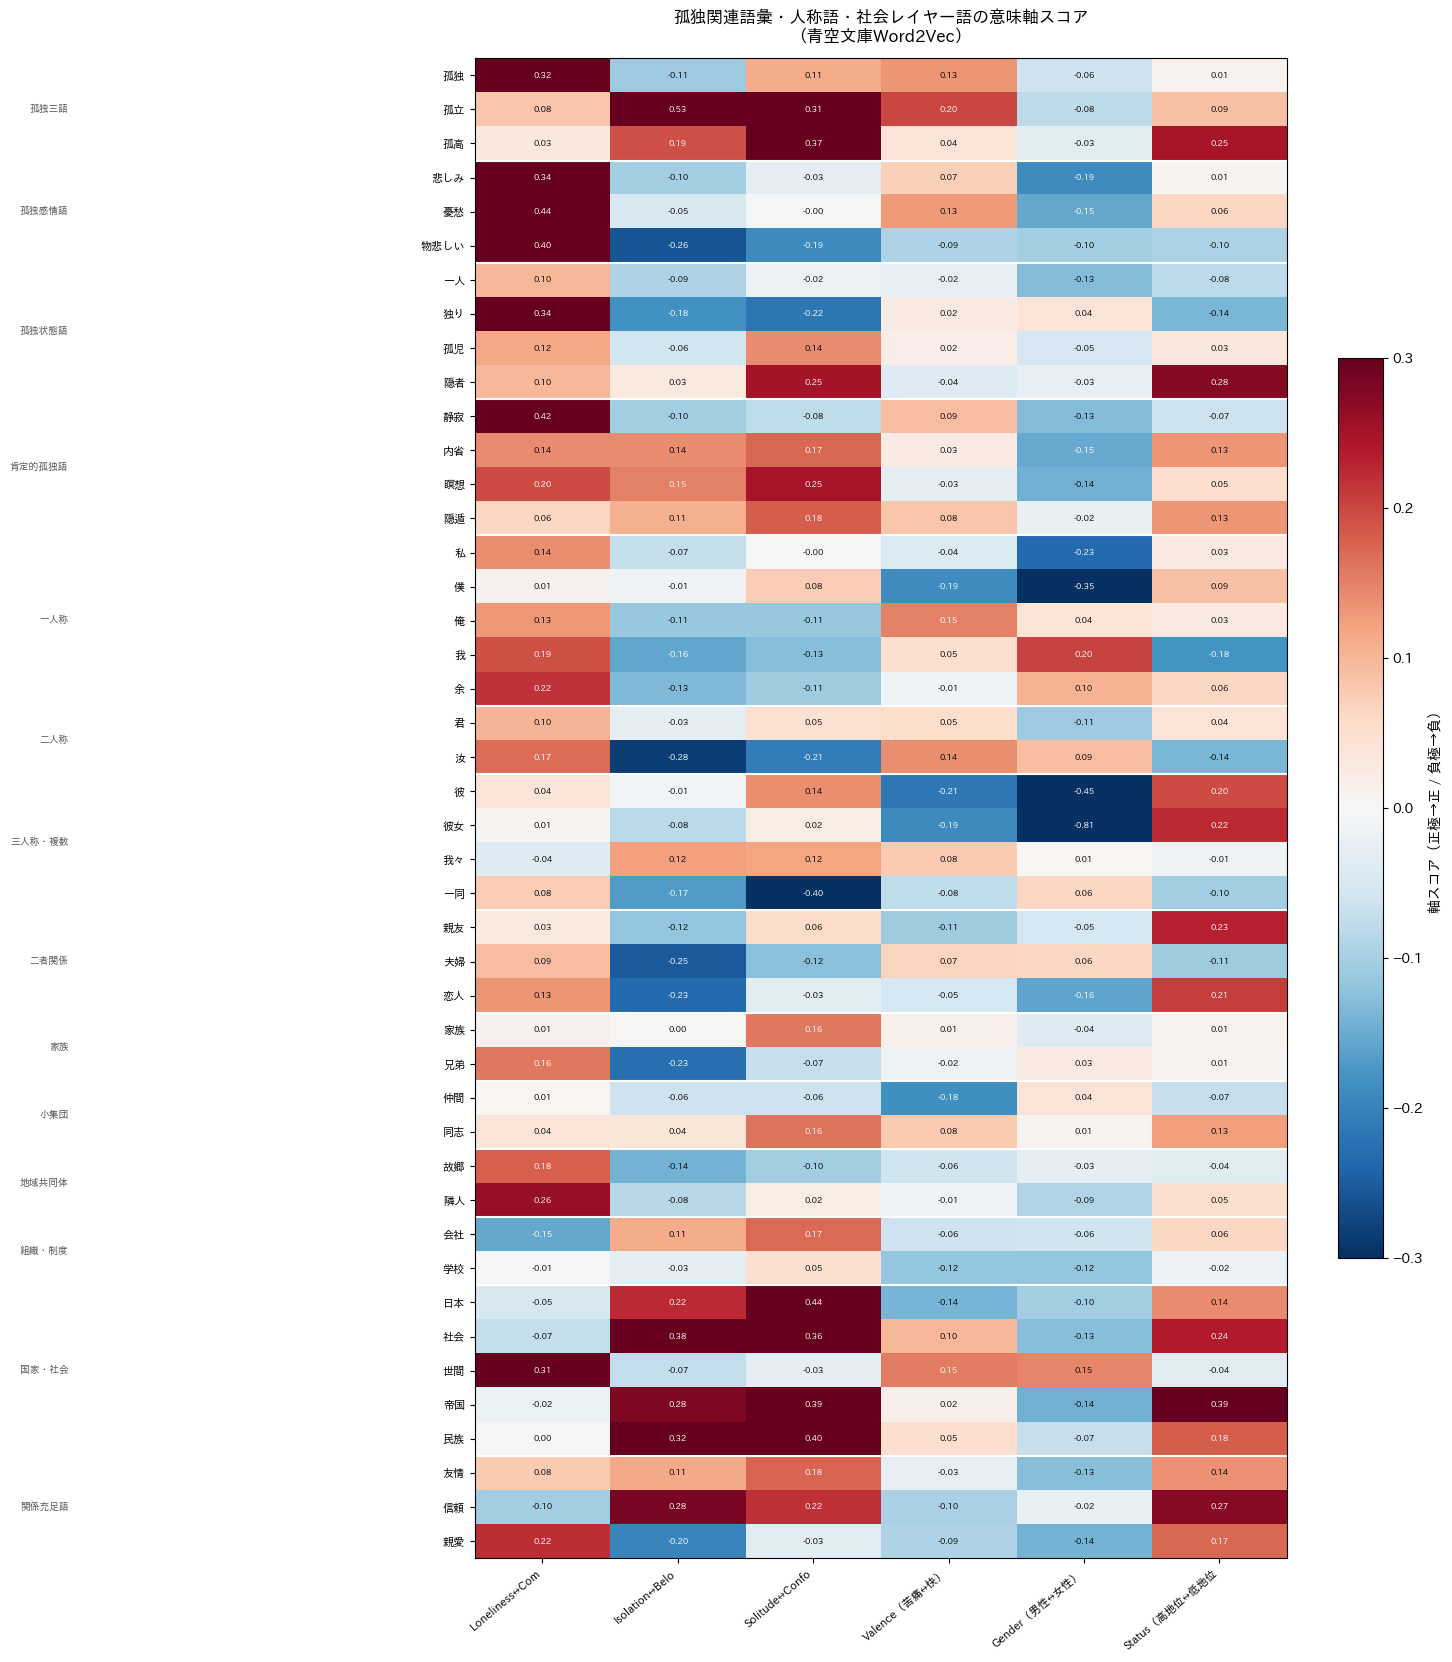

✅ ヒートマップ保存: /content/heatmap_axes.png


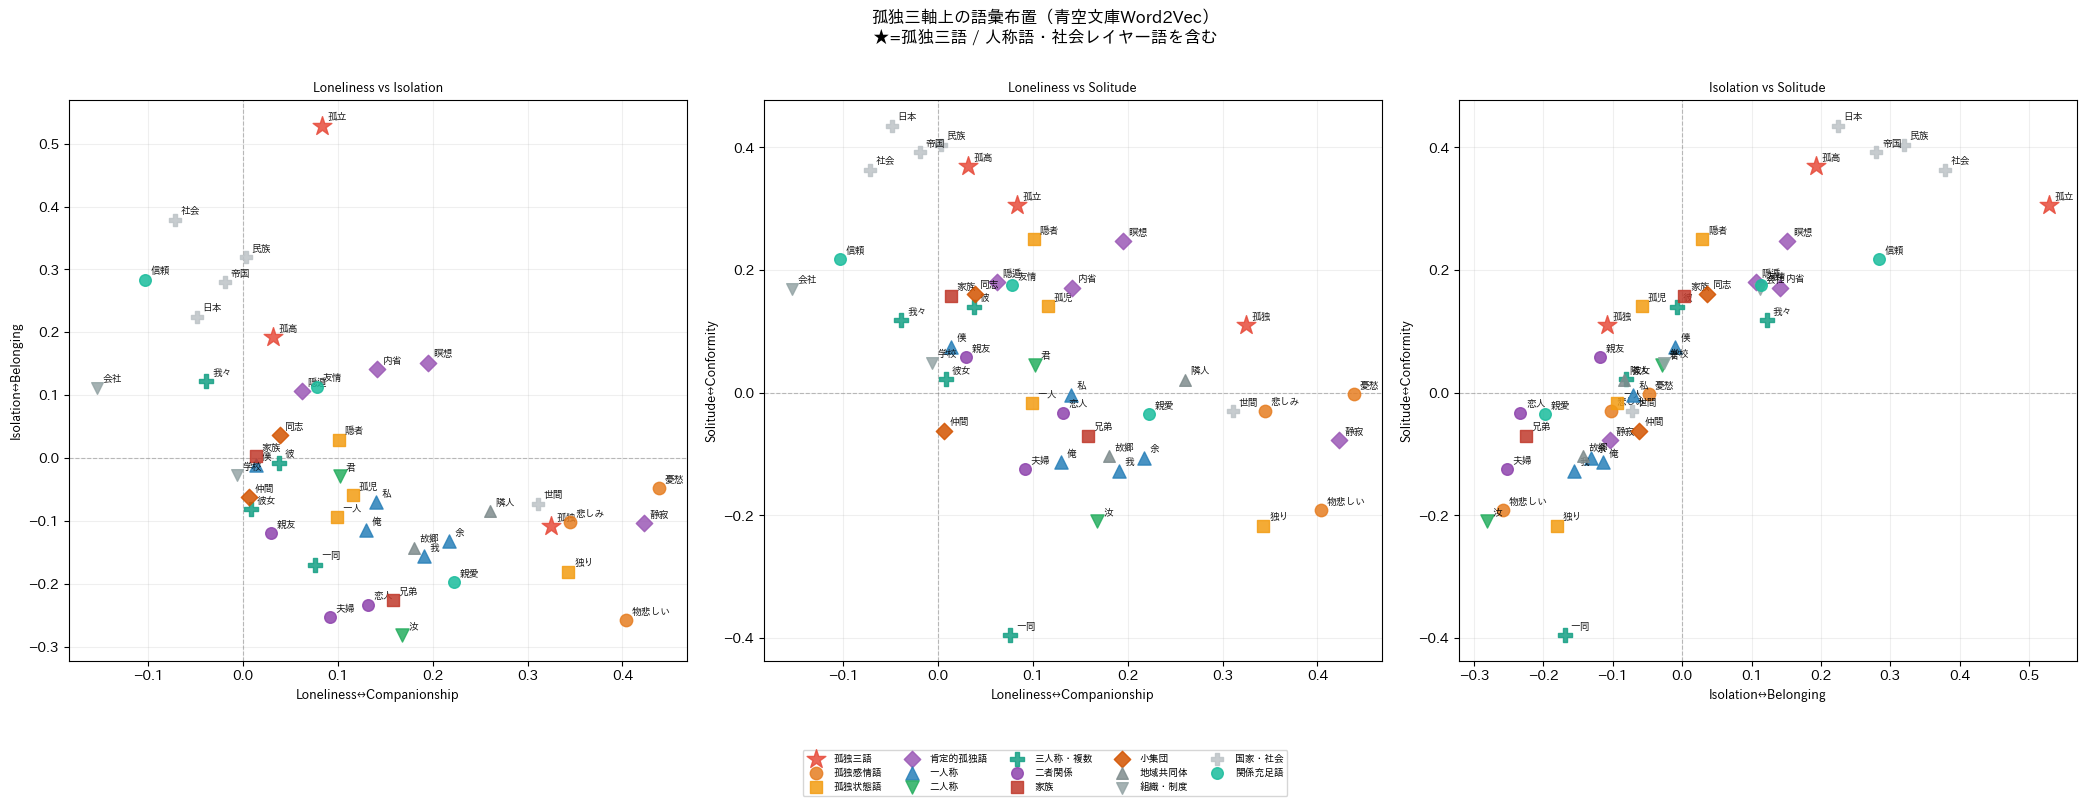

✅ 孤独三軸散布図保存: /content/scatter_loneliness_axes.png


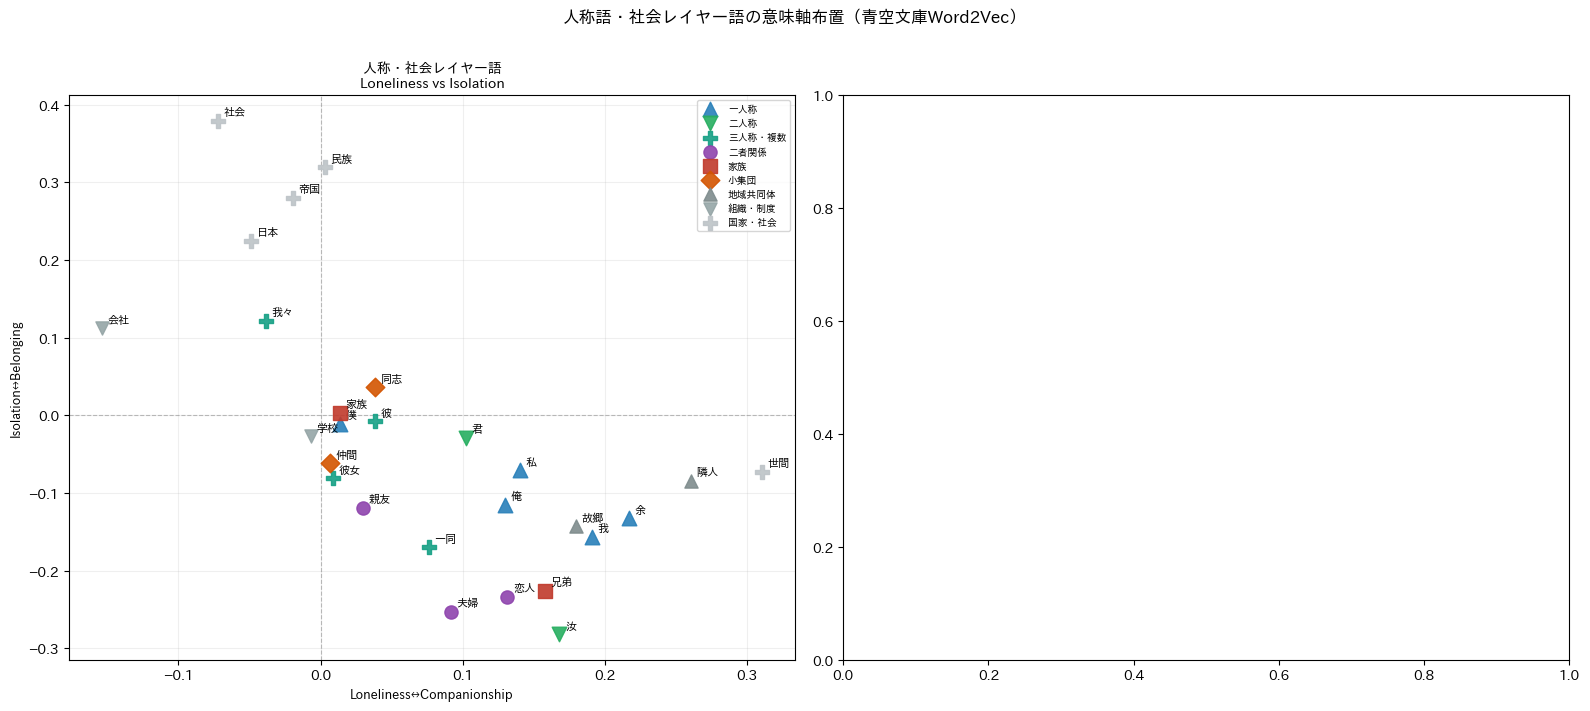

✅ 社会レイヤー散布図保存: /content/scatter_social_layers.png


【Step 5】軸の内的整合性チェック
同一極内の語同士の類似度平均（高いほど軸が安定）

Loneliness↔Companionship
  正極内部類似度: 0.543
  負極内部類似度: 0.526
  正負間類似度  : 0.532（低いほど軸が明確）

Isolation↔Belonging
  正極内部類似度: 0.616
  負極内部類似度: 0.639
  正負間類似度  : 0.560（低いほど軸が明確）

Solitude↔Conformity
  正極内部類似度: 0.620
  負極内部類似度: 0.410
  正負間類似度  : 0.524（低いほど軸が明確）

Valence（苦痛↔快）
  正極内部類似度: 0.539
  負極内部類似度: 0.570
  正負間類似度  : 0.456（低いほど軸が明確）

Agency（強制↔選択）
  正極: 語数不足
  負極内部類似度: 0.326
  正負間: 計算不能

Gender（男性↔女性）
  正極内部類似度: 0.289
  負極: 語数不足
  正負間類似度  : 0.562（低いほど軸が明確）

Status（高地位↔低地位）
  正極内部類似度: 0.505
  負極内部類似度: 0.533
  正負間類似度  : 0.488（低いほど軸が明確）

✅ 分析完了
出力ファイル:
  /content/heatmap_axes.png            （全軸ヒートマップ）
  /content/scatter_loneliness_axes.png （孤独三軸散布図）
  /content/scatter_valence_agency.png  （Valence×Agency散布図）
  /content/scatter_social_layers.png   （社会レイヤー語散布図）


In [234]:
# ============================================================
# 孤独研究：意味軸分析コード（Colab用）
# 青空文庫Word2Vecモデルを使用
# 7軸 × seed wordsによる孤独関連語彙の布置可視化
# ============================================================
# 前提：青空文庫Word2Vecモデルが学習済みであること
# モデルのパスを下記 MODEL_PATH に指定してください
# ============================================================

from gensim.models import Word2Vec, KeyedVectors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.decomposition import PCA
from itertools import combinations

# ── 設定 ──────────────────────────────────────────────────
# PROCESSED_DIR はノートブック上部で定義済みの変数をそのまま使用
matplotlib.rcParams['font.family'] = 'IPAexGothic'  # Colab日本語フォント

# ── モデル読み込み ─────────────────────────────────────────
print("📂 モデル読み込み中...")
_model_path = str(PROCESSED_DIR / 'w2v_aozora_all.model')
model_w2v = Word2Vec.load(_model_path)
wv = model_w2v.wv
print(f"✅ 語彙数: {len(wv):,}\n")


# ============================================================
# Seed Words 定義（暫定版）
# ============================================================

AXES = {
    # ── 第一層：孤独三軸 ──────────────────────────────────
    "Loneliness↔Companionship": {
        "pos": ["寂しい", "空虚", "心細い", "憂鬱", "憂い", "煩悶"],
        "neg": ["睦まじ", "充実", "心強い", "なごやか", "慰む", "安らか"],
        "layer": 1,
        "color": "#E74C3C"
    },
    "Isolation↔Belonging": {
        "pos": ["孤立", "断絶", "疎遠", "無縁"],
        "neg": ["交わり", "絆", "親交", "有縁"],
        "layer": 1,
        "color": "#E67E22"
    },
    "Solitude↔Conformity": {
        "pos": ["孤高", "超然", "独立", "隠遁"],
        "neg": ["従順", "迎合", "付和雷同", "出仕"],
        "layer": 1,
        "color": "#9B59B6"
    },
    # ── 第二層：普遍四軸 ──────────────────────────────────
    "Valence（苦痛↔快）": {
        "pos": ["苦しい", "辛い", "悲しい"],
        "neg": ["楽しい", "嬉しい", "心地よい"],
        "layer": 2,
        "color": "#2ECC71"
    },
    "Agency（強制↔選択）": {
        "pos": ["強いられる", "余儀なく", "やむなく"],
        "neg": ["選ぶ", "望む", "自ら"],
        "layer": 2,
        "color": "#3498DB"
    },
    "Gender（男性↔女性）": {
        "pos": ["男", "彼", "父", "主人"],
        "neg": ["女", "彼女", "母", "娘"],
        "layer": 2,
        "color": "#F39C12"
    },
    "Status（高地位↔低地位）": {
        "pos": ["高貴", "貴族", "富める"],
        "neg": ["貧しい", "卑しい", "下僕"],
        "layer": 2,
        "color": "#1ABC9C"
    },
}

# ============================================================
# 分析対象語彙（グループ別に定義）
# ============================================================

TARGET_GROUPS = {
    # ── 孤独三語（研究の中心）────────────────────────────
    "孤独三語": {
        "words": ["孤独", "孤立", "孤高"],
        "color": "#E74C3C",
        "marker": "*",
        "size": 200,
    },
    # ── 孤独関連語 ────────────────────────────────────────
    "孤独感情語": {
        "words": ["寂しさ", "悲しみ", "虚しい", "わびしい", "憂愁", "物悲しい"],
        "color": "#E67E22",
        "marker": "o",
        "size": 80,
    },
    "孤独状態語": {
        "words": ["一人", "独り", "ひとり", "孤児", "隠者", "独居"],
        "color": "#F39C12",
        "marker": "s",
        "size": 70,
    },
    "肯定的孤独語": {
        "words": ["静寂", "内省", "瞑想", "閑居", "隠遁"],
        "color": "#9B59B6",
        "marker": "D",
        "size": 70,
    },
    # ── 人称語 ────────────────────────────────────────────
    "一人称": {
        "words": ["私", "僕", "俺", "我", "余", "わたくし"],
        "color": "#2980B9",
        "marker": "^",
        "size": 90,
    },
    "二人称": {
        "words": ["あなた", "君", "お前", "汝"],
        "color": "#27AE60",
        "marker": "v",
        "size": 90,
    },
    "三人称・複数": {
        "words": ["彼", "彼女", "彼ら", "我々", "みんな", "一同"],
        "color": "#16A085",
        "marker": "P",
        "size": 90,
    },
    # ── 社会レイヤー語 ────────────────────────────────────
    "二者関係": {
        "words": ["友", "親友", "夫婦", "恋人"],
        "color": "#8E44AD",
        "marker": "o",
        "size": 70,
    },
    "家族": {
        "words": ["家族", "父", "母", "兄弟"],
        "color": "#C0392B",
        "marker": "s",
        "size": 70,
    },
    "小集団": {
        "words": ["仲間", "同志", "仲間内"],
        "color": "#D35400",
        "marker": "D",
        "size": 70,
    },
    "地域共同体": {
        "words": ["村", "町", "故郷", "隣人"],
        "color": "#7F8C8D",
        "marker": "^",
        "size": 70,
    },
    "組織・制度": {
        "words": ["会社", "藩", "寺", "学校"],
        "color": "#95A5A6",
        "marker": "v",
        "size": 70,
    },
    "国家・社会": {
        "words": ["国", "日本", "社会", "世間", "帝国", "民族"],
        "color": "#BDC3C7",
        "marker": "P",
        "size": 70,
    },
    # ── 比較用関係語 ──────────────────────────────────────
    "関係充足語": {
        "words": ["友情", "絆", "愛", "信頼", "親愛"],
        "color": "#1ABC9C",
        "marker": "o",
        "size": 70,
    },
}

# フラットなリストと逆引き辞書を生成
TARGET_WORDS = [w for g in TARGET_GROUPS.values() for w in g["words"]]
WORD_TO_GROUP = {w: gname for gname, g in TARGET_GROUPS.items() for w in g["words"]}


# ============================================================
# Step 1: Seed Wordsの存在確認と頻度チェック
# ============================================================

print("=" * 60)
print("【Step 1】Seed Words の存在確認")
print("=" * 60)

missing_summary = {}
for axis_name, axis_data in AXES.items():
    missing_pos = [w for w in axis_data["pos"] if w not in wv]
    missing_neg = [w for w in axis_data["neg"] if w not in wv]
    missing_all = missing_pos + missing_neg
    missing_summary[axis_name] = missing_all

    status = "✅" if not missing_all else "⚠"
    print(f"\n{status} {axis_name}")
    if missing_pos:
        print(f"   正極 未収録: {missing_pos}")
    if missing_neg:
        print(f"   負極 未収録: {missing_neg}")
    if not missing_all:
        print(f"   全語収録済み")

print("\n" + "=" * 60)
print("【ターゲット語の存在確認】")
print("=" * 60)
missing_targets = [w for w in TARGET_WORDS if w not in wv]
found_targets = [w for w in TARGET_WORDS if w in wv]
print(f"収録済み: {len(found_targets)} / {len(TARGET_WORDS)} 語")
if missing_targets:
    print(f"未収録語: {missing_targets}")

# グループ別の収録状況も表示
print("\nグループ別収録状況:")
for gname, gdata in TARGET_GROUPS.items():
    found = [w for w in gdata["words"] if w in wv]
    missing = [w for w in gdata["words"] if w not in wv]
    print(f"  {gname}: {len(found)}/{len(gdata['words'])} 収録"
          + (f"  未収録: {missing}" if missing else ""))


# ============================================================
# Step 2: 軸ベクトルの計算
# ============================================================

def make_axis_vector(pos_words, neg_words, wv):
    """
    正極語の平均ベクトル - 負極語の平均ベクトル
    コーパス内に存在する語のみ使用
    """
    pos_vecs = [wv[w] for w in pos_words if w in wv]
    neg_vecs = [wv[w] for w in neg_words if w in wv]

    if not pos_vecs or not neg_vecs:
        return None, [], []

    pos_mean = np.mean(pos_vecs, axis=0)
    neg_mean = np.mean(neg_vecs, axis=0)
    axis_vec = pos_mean - neg_mean
    axis_vec = axis_vec / np.linalg.norm(axis_vec)  # 正規化

    used_pos = [w for w in pos_words if w in wv]
    used_neg = [w for w in neg_words if w in wv]
    return axis_vec, used_pos, used_neg


print("\n\n" + "=" * 60)
print("【Step 2】軸ベクトルの計算")
print("=" * 60)

axis_vectors = {}
for axis_name, axis_data in AXES.items():
    vec, used_pos, used_neg = make_axis_vector(
        axis_data["pos"], axis_data["neg"], wv
    )
    if vec is not None:
        axis_vectors[axis_name] = vec
        print(f"✅ {axis_name}")
        print(f"   正極使用語: {used_pos}")
        print(f"   負極使用語: {used_neg}")
    else:
        print(f"❌ {axis_name}: ベクトル計算不能（語彙不足）")


# ============================================================
# Step 3: ターゲット語の各軸スコア計算
# ============================================================

def axis_score(word, axis_vec, wv):
    """単語の軸スコア（正極方向が正）"""
    if word not in wv:
        return np.nan
    word_vec = wv[word] / np.linalg.norm(wv[word])
    return float(np.dot(word_vec, axis_vec))


print("\n\n" + "=" * 60)
print("【Step 3】ターゲット語の軸スコア")
print("正値 → 正極（孤独・苦痛・強制・男性・高地位）寄り")
print("負値 → 負極（共在・快・選択・女性・低地位）寄り")
print("=" * 60)

score_data = {}
for word in found_targets:
    scores = {}
    for axis_name, axis_vec in axis_vectors.items():
        scores[axis_name] = axis_score(word, axis_vec, wv)
    score_data[word] = scores

score_df = pd.DataFrame(score_data).T
score_df.columns = [c[:12] for c in score_df.columns]
print(score_df.round(3).to_string())


# ============================================================
# Step 4: 可視化
# ============================================================

def plot_scatter_with_groups(ax_plot, ax_x_name, ax_y_name, found_targets,
                              axis_vectors, wv, title=""):
    """グループ別色分け散布図の共通描画関数"""
    if ax_x_name not in axis_vectors or ax_y_name not in axis_vectors:
        return

    for gname, gdata in TARGET_GROUPS.items():
        words_in_group = [w for w in gdata["words"] if w in found_targets]
        if not words_in_group:
            continue

        xs = [axis_score(w, axis_vectors[ax_x_name], wv) for w in words_in_group]
        ys = [axis_score(w, axis_vectors[ax_y_name], wv) for w in words_in_group]

        valid = [(w, x, y) for w, x, y in zip(words_in_group, xs, ys)
                 if not (np.isnan(x) or np.isnan(y))]
        if not valid:
            continue

        ws, vxs, vys = zip(*valid)
        ax_plot.scatter(vxs, vys,
                        c=gdata["color"],
                        marker=gdata["marker"],
                        s=gdata["size"],
                        alpha=0.85,
                        label=gname,
                        zorder=3)
        for w, x, y in valid:
            ax_plot.annotate(w, (x, y),
                             textcoords="offset points",
                             xytext=(4, 4), fontsize=7, alpha=0.9)

    ax_plot.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_plot.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_plot.set_xlabel(ax_x_name, fontsize=9)
    ax_plot.set_ylabel(ax_y_name, fontsize=9)
    ax_plot.set_title(title or f"{ax_x_name[:18]}\nvs {ax_y_name[:18]}", fontsize=9)
    ax_plot.grid(True, alpha=0.2)


# ── 4-1: ヒートマップ（全軸 × 全ターゲット語）──────────────
# グループ順にソートして表示
sorted_targets = [w for g in TARGET_GROUPS.values()
                  for w in g["words"] if w in found_targets]

score_data_sorted = {}
for word in sorted_targets:
    scores = {}
    for axis_name, axis_vec in axis_vectors.items():
        scores[axis_name] = axis_score(word, axis_vec, wv)
    score_data_sorted[word] = scores

score_df_sorted = pd.DataFrame(score_data_sorted).T
col_labels = [c[:14] for c in score_df_sorted.columns]

# グループ境界の位置を計算
group_boundaries = []
idx = 0
for gname, gdata in TARGET_GROUPS.items():
    count = len([w for w in gdata["words"] if w in found_targets])
    if count > 0:
        group_boundaries.append((idx, idx + count, gname))
        idx += count

fig, ax = plt.subplots(figsize=(16, max(8, len(sorted_targets) * 0.38)))
data = score_df_sorted.values
im = ax.imshow(data, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(len(score_df_sorted.index)))
ax.set_yticklabels(score_df_sorted.index, fontsize=8)

# グループ境界線を描画
for start, end, gname in group_boundaries:
    if start > 0:
        ax.axhline(start - 0.5, color='white', linewidth=1.5)
    # グループ名を左端に表示
    ax.text(-0.5, (start + end - 1) / 2, gname,
            ha='right', va='center', fontsize=7,
            color='#555555', transform=ax.get_yaxis_transform())

plt.colorbar(im, ax=ax, label='軸スコア（正極→正 / 負極→負）', shrink=0.6)
ax.set_title("孤独関連語彙・人称語・社会レイヤー語の意味軸スコア\n（青空文庫Word2Vec）",
             fontsize=12, pad=12)

# 値をセルに表示
for i in range(len(score_df_sorted.index)):
    for j in range(len(col_labels)):
        val = data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                    fontsize=6, color='white' if abs(val) > 0.15 else 'black')

plt.tight_layout()
plt.savefig("/content/heatmap_axes.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ ヒートマップ保存: /content/heatmap_axes.png")


# ── 4-2: 孤独三軸の散布図（3ペア）────────────────────────────
axis_pairs_l1 = [
    ("Loneliness↔Companionship", "Isolation↔Belonging",
     "Loneliness vs Isolation"),
    ("Loneliness↔Companionship", "Solitude↔Conformity",
     "Loneliness vs Solitude"),
    ("Isolation↔Belonging",      "Solitude↔Conformity",
     "Isolation vs Solitude"),
]

fig, axes_plot = plt.subplots(1, 3, figsize=(21, 7))
for ax_plot, (ax_x, ax_y, title) in zip(axes_plot, axis_pairs_l1):
    plot_scatter_with_groups(ax_plot, ax_x, ax_y, found_targets,
                             axis_vectors, wv, title=title)

# 凡例を最後のサブプロットに付ける
handles, labels = axes_plot[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5,
           fontsize=7, bbox_to_anchor=(0.5, -0.12))

plt.suptitle("孤独三軸上の語彙布置（青空文庫Word2Vec）\n"
             "★=孤独三語 / 人称語・社会レイヤー語を含む",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("/content/scatter_loneliness_axes.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ 孤独三軸散布図保存: /content/scatter_loneliness_axes.png")


# ── 4-3: Valence × Agency 散布図 ────────────────────────────
ax_x = "Valence（苦痛↔快）"
ax_y = "Agency（強制↔選択）"

if ax_x in axis_vectors and ax_y in axis_vectors:
    fig, ax = plt.subplots(figsize=(12, 10))
    plot_scatter_with_groups(ax, ax_x, ax_y, found_targets,
                             axis_vectors, wv)

    # 象限ラベル
    for (ha, va, x, y, txt) in [
        ('right', 'top',    0.98, 0.98, "苦痛×強制\n（Isolation型）"),
        ('left',  'top',    0.02, 0.98, "快×強制"),
        ('right', 'bottom', 0.98, 0.02, "苦痛×選択\n（Loneliness型）"),
        ('left',  'bottom', 0.02, 0.02, "快×選択\n（Solitude型）"),
    ]:
        ax.text(x, y, txt, transform=ax.transAxes,
                ha=ha, va=va, fontsize=8, color='gray', alpha=0.7)

    ax.set_xlabel("Valence（苦痛 ← → 快）", fontsize=11)
    ax.set_ylabel("Agency（強制 ← → 選択）", fontsize=11)
    ax.set_title("Valence × Agency 布置\n（青空文庫Word2Vec）", fontsize=12, pad=12)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=7, loc='upper left',
              bbox_to_anchor=(1.01, 1), borderaxespad=0)

    plt.tight_layout()
    plt.savefig("/content/scatter_valence_agency.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Valence×Agency散布図保存: /content/scatter_valence_agency.png")


# ── 4-4: 社会レイヤー × 孤独三軸（社会スケール別の布置）────
# 人称・社会レイヤー語だけを抽出して孤独三軸上に布置
social_groups = ["一人称", "二人称", "三人称・複数",
                 "二者関係", "家族", "小集団",
                 "地域共同体", "組織・制度", "国家・社会"]
social_words = [w for gn in social_groups
                for w in TARGET_GROUPS[gn]["words"] if w in found_targets]

if social_words and "Loneliness↔Companionship" in axis_vectors:
    fig, axes_plot = plt.subplots(1, 2, figsize=(16, 7))

    for ax_plot, (ax_x, ax_y, title) in zip(axes_plot, [
        ("Loneliness↔Companionship", "Isolation↔Belonging",
         "人称・社会レイヤー語\nLoneliness vs Isolation"),
        ("Valence（苦痛↔快）", "Agency（強制↔選択）",
         "人称・社会レイヤー語\nValence vs Agency"),
    ]):
        if ax_x not in axis_vectors or ax_y not in axis_vectors:
            continue
        for gname in social_groups:
            gdata = TARGET_GROUPS[gname]
            words = [w for w in gdata["words"] if w in found_targets]
            if not words:
                continue
            xs = [axis_score(w, axis_vectors[ax_x], wv) for w in words]
            ys = [axis_score(w, axis_vectors[ax_y], wv) for w in words]
            valid = [(w, x, y) for w, x, y in zip(words, xs, ys)
                     if not (np.isnan(x) or np.isnan(y))]
            if not valid:
                continue
            ws, vxs, vys = zip(*valid)
            ax_plot.scatter(vxs, vys,
                            c=gdata["color"], marker=gdata["marker"],
                            s=gdata["size"] + 20, alpha=0.9,
                            label=gname, zorder=3)
            for w, x, y in valid:
                ax_plot.annotate(w, (x, y), textcoords="offset points",
                                 xytext=(4, 4), fontsize=8)

        ax_plot.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
        ax_plot.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
        ax_plot.set_xlabel(ax_x, fontsize=9)
        ax_plot.set_ylabel(ax_y, fontsize=9)
        ax_plot.set_title(title, fontsize=10)
        ax_plot.grid(True, alpha=0.2)
        ax_plot.legend(fontsize=7, loc='best')

    plt.suptitle("人称語・社会レイヤー語の意味軸布置（青空文庫Word2Vec）",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig("/content/scatter_social_layers.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ 社会レイヤー散布図保存: /content/scatter_social_layers.png")


# ============================================================
# Step 5: 軸の内的整合性チェック（seed words同士のコサイン類似度）
# ============================================================

print("\n\n" + "=" * 60)
print("【Step 5】軸の内的整合性チェック")
print("同一極内の語同士の類似度平均（高いほど軸が安定）")
print("=" * 60)

for axis_name, axis_data in AXES.items():
    pos_words = [w for w in axis_data["pos"] if w in wv]
    neg_words = [w for w in axis_data["neg"] if w in wv]

    def mean_sim(words, wv):
        if len(words) < 2:
            return np.nan
        sims = [wv.similarity(a, b)
                for a, b in combinations(words, 2)]
        return np.mean(sims)

    pos_sim = mean_sim(pos_words, wv)
    neg_sim = mean_sim(neg_words, wv)

    # 正極と負極の分離度（正極語と負極語の類似度平均）
    cross_sims = []
    for p in pos_words:
        for n in neg_words:
            cross_sims.append(wv.similarity(p, n))
    cross_sim = np.mean(cross_sims) if cross_sims else np.nan

    print(f"\n{axis_name}")
    print(f"  正極内部類似度: {pos_sim:.3f}" if not np.isnan(pos_sim) else "  正極: 語数不足")
    print(f"  負極内部類似度: {neg_sim:.3f}" if not np.isnan(neg_sim) else "  負極: 語数不足")
    print(f"  正負間類似度  : {cross_sim:.3f}（低いほど軸が明確）"
          if not np.isnan(cross_sim) else "  正負間: 計算不能")

print("\n✅ 分析完了")
print("出力ファイル:")
print("  /content/heatmap_axes.png            （全軸ヒートマップ）")
print("  /content/scatter_loneliness_axes.png （孤独三軸散布図）")
print("  /content/scatter_valence_agency.png  （Valence×Agency散布図）")
print("  /content/scatter_social_layers.png   （社会レイヤー語散布図）")

In [235]:
# Gender軸の単漢字確認
test_words = ["私", "彼", "男", "女", "父", "母", "娘", "君", "彼女",
              "僕", "俺", "我", "余", "汝", "一人称", "人称"]

for w in test_words:
    status = "✅" if w in wv else "❌"
    print(f"{status} '{w}'")

✅ '私'
✅ '彼'
❌ '男'
❌ '女'
❌ '父'
❌ '母'
❌ '娘'
✅ '君'
✅ '彼女'
✅ '僕'
✅ '俺'
✅ '我'
✅ '余'
✅ '汝'
❌ '一人称'
✅ '人称'


In [236]:
# ノートブックで使用しているトークナイザを確認
for name, obj in list(globals().items()):
    t = type(obj).__name__
    if any(x in t.lower() for x in ['tagger', 'tokenizer', 'analyzer', 'wakati']):
        print(f"変数名: {name}, 型: {t}")

# よくある名前も直接チェック
for varname in ['tokenizer', 'tagger', 'wakati', 'analyzer', 't', 'mecab']:
    if varname in dir(__builtins__) or varname in globals():
        print(f"'{varname}' が存在します")

変数名: tagger, 型: Tagger
'tagger' が存在します
't' が存在します


In [237]:
# 人称代名詞候補の収録状況
candidates = [
    "わたし", "かれ", "かのじょ", "ぼく", "おれ",
    "吾", "己", "自分", "われ", "わが", "おのれ",
    "其", "其の", "彼奴", "此奴", "我が輩", "拙者",
    "小生", "妾", "儂", "貴様", "貴方", "貴君"
]

print("人称代名詞候補の収録状況:")
found = []
for w in candidates:
    if w in wv:
        found.append(w)
        print(f"  ✅ '{w}'")
    else:
        print(f"  ❌ '{w}'")

print(f"\n収録済み: {found}")

人称代名詞候補の収録状況:
  ❌ 'わたし'
  ❌ 'かれ'
  ❌ 'かのじょ'
  ❌ 'ぼく'
  ❌ 'おれ'
  ❌ '吾'
  ✅ '己'
  ✅ '自分'
  ❌ 'われ'
  ❌ 'わが'
  ❌ 'おのれ'
  ✅ '其'
  ❌ '其の'
  ✅ '彼奴'
  ✅ '此奴'
  ✅ '我が輩'
  ✅ '拙者'
  ✅ '小生'
  ❌ '妾'
  ❌ '儂'
  ✅ '貴様'
  ✅ '貴方'
  ✅ '貴君'

収録済み: ['己', '自分', '其', '彼奴', '此奴', '我が輩', '拙者', '小生', '貴様', '貴方', '貴君']


In [238]:
# taggerで人称代名詞のトークナイズを確認
test_sentences = [
    "私は孤独である",
    "彼は一人で歩いた",
    "彼女は悲しんでいた",
    "余は満足じゃ",
    "僕は君のことが好きだ",
    "我輩は猫である",
]

for sent in test_sentences:
    result = tagger.parse(sent)
    tokens = [line.split('\t')[0] for line in result.strip().split('\n')
              if line and line != 'EOS']
    print(f"入力: {sent}")
    print(f"分割: {tokens}\n")

入力: 私は孤独である
分割: ['私', 'は', '孤独', 'で', 'ある']

入力: 彼は一人で歩いた
分割: ['彼', 'は', '一人', 'で', '歩い', 'た']

入力: 彼女は悲しんでいた
分割: ['彼女', 'は', '悲しん', 'で', 'い', 'た']

入力: 余は満足じゃ
分割: ['余', 'は', '満足', 'じゃ']

入力: 僕は君のことが好きだ
分割: ['僕', 'は', '君', 'の', 'こと', 'が', '好き', 'だ']

入力: 我輩は猫である
分割: ['我輩', 'は', '猫', 'で', 'ある']



In [239]:
# 学習時のmin_count設定を確認
print("min_count:", model_w2v.min_count)
print("window:", model_w2v.window)
print("vector_size:", model_w2v.vector_size)

# 人称代名詞のコーパス内頻度を直接確認
# （Word2Vecは学習時に除外した語の頻度は保持していないので、
#   生コーパスから数える必要がある）
target_pronouns = ["私", "彼", "彼女", "僕", "俺", "余", "我", "君",
                   "自分", "小生", "我輩", "汝", "己"]

print("\n語彙内頻度（wv.key_to_index に入っているもののみ）:")
for w in target_pronouns:
    if w in wv:
        # gensimはget_vecattr('word', 'count')で頻度取得可能
        try:
            count = wv.get_vecattr(w, 'count')
            print(f"  ✅ {w}: {count:,}回")
        except:
            print(f"  ✅ {w}: 収録済み（頻度取得不可）")
    else:
        print(f"  ❌ {w}: 未収録（min_count以下か学習データに不在）")

min_count: 3
window: 5
vector_size: 100

語彙内頻度（wv.key_to_index に入っているもののみ）:
  ✅ 私: 24,201回
  ✅ 彼: 15,970回
  ✅ 彼女: 6,752回
  ✅ 僕: 11,506回
  ✅ 俺: 3,310回
  ✅ 余: 224回
  ✅ 我: 1,179回
  ✅ 君: 3,112回
  ✅ 自分: 9,335回
  ✅ 小生: 16回
  ❌ 我輩: 未収録（min_count以下か学習データに不在）
  ✅ 汝: 666回
  ✅ 己: 424回


In [240]:
# 生コーパスから人称代名詞の実際の出現頻度を数える
# （sentences は学習時に使ったトークン列のはず）

from collections import Counter

# ノートブック内のsentences変数を探す
sentences_var = None
for varname in ['sentences', 'corpus', 'tokenized', 'all_sentences', 'texts']:
    if varname in globals():
        sentences_var = globals()[varname]
        print(f"コーパス変数: '{varname}' を使用")
        break

if sentences_var is not None:
    # 全トークンをフラットに数える
    counter = Counter(tok for sent in sentences_var for tok in sent)

    print(f"\n総トークン数: {sum(counter.values()):,}")
    print(f"ユニーク語数: {len(counter):,}")

    print("\n人称代名詞の出現頻度:")
    pronouns = ["私", "彼", "彼女", "僕", "俺", "余", "我", "君",
                "自分", "小生", "我輩", "汝", "己", "拙者", "妾", "儂"]
    for w in pronouns:
        count = counter.get(w, 0)
        status = "✅" if count >= 3 else ("⚠ min_count未満" if count > 0 else "❌ 出現なし")
        print(f"  {w}: {count:,}回 {status}")
else:
    print("コーパス変数が見つかりません。変数名を教えてください。")

コーパス変数: 'sentences' を使用

総トークン数: 18
ユニーク語数: 17

人称代名詞の出現頻度:
  私: 0回 ❌ 出現なし
  彼: 0回 ❌ 出現なし
  彼女: 0回 ❌ 出現なし
  僕: 0回 ❌ 出現なし
  俺: 0回 ❌ 出現なし
  余: 0回 ❌ 出現なし
  我: 0回 ❌ 出現なし
  君: 0回 ❌ 出現なし
  自分: 0回 ❌ 出現なし
  小生: 0回 ❌ 出現なし
  我輩: 0回 ❌ 出現なし
  汝: 0回 ❌ 出現なし
  己: 0回 ❌ 出現なし
  拙者: 0回 ❌ 出現なし
  妾: 0回 ❌ 出現なし
  儂: 0回 ❌ 出現なし


In [241]:
# wvの語彙から「私」に関連しそうな語を探す
import re

print("「私」を含む語彙:")
for word in wv.key_to_index:
    if '私' in word:
        count = wv.get_vecattr(word, 'count')
        print(f"  '{word}': {count:,}回")

print("\n「彼」を含む語彙:")
for word in wv.key_to_index:
    if '彼' in word:
        count = wv.get_vecattr(word, 'count')
        print(f"  '{word}': {count:,}回")

print("\n「男」を含む語彙:")
for word in wv.key_to_index:
    if '男' in word:
        count = wv.get_vecattr(word, 'count')
        print(f"  '{word}': {count:,}回")

# 念のためtaggerの出力形式も確認
print("\n--- taggerの生出力を確認 ---")
print(tagger.parse("私は孤独である"))

「私」を含む語彙:
  '私': 24,201回
  '私立': 58回
  '私服': 23回
  '無私': 21回
  '私有': 19回
  '私鉄': 17回
  '私欲': 15回
  '樣私': 11回
  '私事': 9回
  '私語': 8回
  '公私': 8回
  '私設': 8回
  '私儀': 8回
  '私見': 6回
  '私娼': 6回
  '私室': 6回
  '私用': 5回
  '私情': 5回
  '處私': 4回
  '私宅': 4回
  '私利': 4回
  '私信': 3回
  '私論': 3回
  '寄私': 3回
  '私生': 3回
  '私財': 3回

「彼」を含む語彙:
  '彼': 15,970回
  '彼女': 6,752回
  '彼れ': 1,283回
  '彼奴': 618回
  '彼方': 427回
  '彼処': 349回
  '彼方此方': 274回
  '彼是': 154回
  '彼岸': 35回
  '彼此': 20回
  '彼の世': 19回
  '誰彼': 15回
  '彼氏': 9回
  '此処彼処': 8回
  '其処彼処': 5回
  '處彼': 5回
  '彼方側': 4回
  '樣彼': 3回

「男」を含む語彙:
  '男性': 239回
  '男女': 186回
  '男子': 163回
  '男の子': 87回
  '下男': 69回
  '長男': 60回
  '次男': 59回
  '男爵': 53回
  '大男': 46回
  '小男': 39回
  '美男': 16回
  '山男': 13回
  '醜男': 11回
  '色男': 10回
  '嫡男': 9回
  '男勝り': 9回
  '男衆': 8回
  '男工': 7回
  '寺男': 7回
  '男優': 7回
  '男前': 7回
  '男湯': 6回
  '男物': 5回
  '雨男': 5回
  '荒くれ男': 4回
  '男鰥': 4回
  '作男': 4回
  '男色': 3回
  '男臭い': 3回
  '男装': 3回
  '男泣き': 3回

--- taggerの生出力を確認 ---
私	ワタクシ	ワタクシ	私-代名詞	代名詞			0
は	ワ	ハ	は	助詞-係助詞			
孤独	コドク	コ

In [242]:
# taggerの出力形式を詳しく確認
# → 学習時にどの列を使ったか特定する

print("=== tagger出力の列構造 ===")
result = tagger.parse("彼女は悲しんでいた")
for line in result.strip().split('\n'):
    if line and line != 'EOS':
        print(repr(line))

# 学習時の前処理関数を探す
print("\n=== 前処理・トークナイズ関連の関数・変数 ===")
for name, obj in list(globals().items()):
    if callable(obj) and any(x in name.lower() for x in
       ['token', 'preprocess', 'wakati', 'parse', 'segment', 'clean']):
        print(f"  関数: {name}")
    if isinstance(obj, list) and len(obj) > 100:
        if isinstance(obj[0], list):
            sample = obj[0][:5]
            print(f"  リスト変数 '{name}': 先頭サンプル = {sample}")



=== tagger出力の列構造 ===
'彼女\tカノジョ\tカノジョ\t彼女\t代名詞\t\t\t1'
'は\tワ\tハ\tは\t助詞-係助詞\t\t\t'
'悲しん\tカナシン\tカナシム\t悲しむ\t動詞-一般\t五段-マ行\t連用形-撥音便\t3'
'で\tデ\tテ\tて\t助詞-接続助詞\t\t\t'
'い\tイ\tイル\t居る\t動詞-非自立可能\t上一段-ア行\t連用形-一般\t0'
'た\tタ\tタ\tた\t助動詞\t助動詞-タ\t終止形-一般\t'

=== 前処理・トークナイズ関連の関数・変数 ===
  関数: clean_aozora_text
  関数: tokenize
  リスト変数 'all_sentences_full': 先頭サンプル = ['一体', 'どう', '為る', '私', '宿儺']
  リスト変数 'sents': 先頭サンプル = ['海鼠子', 'モペット', '言う', '子猫']


In [243]:
# tokenize関数の実装を確認
import inspect
print(inspect.getsource(tokenize))

def tokenize(text, pos_filter=TARGET_POS):
    sentences = []
    current = []
    for word in tagger(text):
        pos = word.feature.pos1
        surface = word.surface
        if surface in {'。', '！', '？', '\n\n'}:
            if len(current) >= 3:
                sentences.append(current)
            current = []
            continue
        if pos not in pos_filter:
            continue
        try:
            lemma = word.feature.lemma
            token = lemma if (lemma and lemma != '*') else surface
        except:
            token = surface
        token = token.split('-')[0]
        min_len = 1 if pos == '代名詞' else 2
        if len(token) < min_len or token.isnumeric():
            continue
        current.append(token)
    if len(current) >= 3:
        sentences.append(current)
    return sentences



In [244]:
# 辞書形での人称代名詞を確認
print("辞書形での人称代名詞収録状況:")
# tagger出力の4列目が辞書形
result = tagger.parse("私は彼女に会った。彼は僕を見た。余は満足じゃ。")
for line in result.strip().split('\n'):
    if line and line != 'EOS':
        cols = line.split('\t')
        if len(cols) >= 5 and '代名詞' in cols[4]:
            surface = cols[0]   # 表層形
            base    = cols[3]   # 辞書形
            print(f"  表層: {surface} → 辞書形: {base} → wv収録: {base in wv}")

辞書形での人称代名詞収録状況:
  表層: 私 → 辞書形: 私-代名詞 → wv収録: False
  表層: 彼女 → 辞書形: 彼女 → wv収録: True
  表層: 彼 → 辞書形: 彼 → wv収録: True
  表層: 僕 → 辞書形: 僕 → wv収録: True
  表層: 余 → 辞書形: 余-代名詞 → wv収録: False


In [245]:
# TARGET_POSの内容を確認
print("TARGET_POS:", TARGET_POS)

# 「私-代名詞」形式の語がwvにあるか確認
print("\n「-代名詞」形式の収録確認:")
for word in wv.key_to_index:
    if '代名詞' in word:
        count = wv.get_vecattr(word, 'count')
        print(f"  '{word}': {count:,}回")

TARGET_POS: {'代名詞', '形容詞', '名詞', '動詞', '副詞'}

「-代名詞」形式の収録確認:


In [246]:
print("TARGET_POS:", TARGET_POS)
print("'私' in wv:", '私' in wv)
print("'彼' in wv:", '彼' in wv)

TARGET_POS: {'代名詞', '形容詞', '名詞', '動詞', '副詞'}
'私' in wv: True
'彼' in wv: True


In [247]:
# all_sentences_full が代名詞を含んでいるか確認
sample_pronouns = []
for sent in all_sentences_full[:1000]:  # 最初の1000文をチェック
    for tok in sent:
        if tok in ['私', '彼', '彼女', '僕', '自分', '余']:
            sample_pronouns.append(tok)

print("先頭1000文中の代名詞トークン:")
print(sample_pronouns[:30] if sample_pronouns else "→ 代名詞が含まれていない（再トークナイズが必要）")

# モデルの学習日時も確認
import os
model_path = str(PROCESSED_DIR / 'w2v_aozora_all.model')
mtime = os.path.getmtime(model_path)
import datetime
print(f"\nモデルの最終更新: {datetime.datetime.fromtimestamp(mtime)}")

先頭1000文中の代名詞トークン:
['私', '私', '自分', '彼', '私', '私', '彼', '彼', '私', '彼', '私', '私', '彼', '彼', '自分', '私', '私', '彼', '彼', '私', '私', '私', '私', '私', '私', '私', '私', '私', '私', '私']

モデルの最終更新: 2026-03-14 07:36:34


In [248]:
# all_sentences_full中の代名詞トークンを全種類カウント
from collections import Counter

pronoun_counter = Counter()
for sent in all_sentences_full:
    for tok in sent:
        # 代名詞らしき語を広めに拾う
        if any(p in tok for p in ['私', '彼', '僕', '余', '君', '俺', '我', '汝', '己']):
            pronoun_counter[tok] += 1

print("代名詞関連トークンの全種類:")
for tok, count in pronoun_counter.most_common(30):
    print(f"  '{tok}': {count:,}回  → wv収録: {tok in wv}")


代名詞関連トークンの全種類:
  '私': 24,201回  → wv収録: True
  '彼': 15,970回  → wv収録: True
  '僕': 11,506回  → wv収録: True
  '彼女': 6,752回  → wv収録: True
  '俺': 3,310回  → wv収録: True
  '君': 3,112回  → wv収録: True
  '我々': 1,553回  → wv収録: True
  '余り': 1,550回  → wv収録: True
  '彼れ': 1,283回  → wv収録: True
  '我': 1,179回  → wv収録: True
  '汝': 666回  → wv収録: True
  '彼奴': 618回  → wv収録: True
  '彼方': 427回  → wv収録: True
  '己': 424回  → wv収録: True
  '彼処': 349回  → wv収録: True
  '自己': 312回  → wv収録: True
  '彼方此方': 274回  → wv収録: True
  '我慢': 252回  → wv収録: True
  '余程': 237回  → wv収録: True
  '余': 224回  → wv収録: True
  '細君': 209回  → wv収録: True
  '諸君': 191回  → wv収録: True
  '我が家': 181回  → wv収録: True
  '君子': 167回  → wv収録: True
  '怪我': 158回  → wv収録: True
  '彼是': 154回  → wv収録: True
  '余所': 129回  → wv収録: True
  '余裕': 122回  → wv収録: True
  '余地': 88回  → wv収録: True
  '余る': 70回  → wv収録: True


In [249]:
# 「-」を含むトークンを確認
hyphen_tokens = Counter()
for sent in all_sentences_full:
    for tok in sent:
        if '-' in tok:
            hyphen_tokens[tok] += 1

print("ハイフン付きトークン上位30:")
for tok, count in hyphen_tokens.most_common(30):
    print(f"  '{tok}': {count:,}回")

ハイフン付きトークン上位30:


In [250]:
# tokenize関数が参照しているTARGET_POSを直接確認
import inspect
source = inspect.getsource(tokenize)
print(source)

# さらに、実際に1文だけtokenizeして代名詞が出るか確認
test = tokenize("私は彼女に会った。彼は孤独であった。")
print("\ntokenize結果:", test)

def tokenize(text, pos_filter=TARGET_POS):
    sentences = []
    current = []
    for word in tagger(text):
        pos = word.feature.pos1
        surface = word.surface
        if surface in {'。', '！', '？', '\n\n'}:
            if len(current) >= 3:
                sentences.append(current)
            current = []
            continue
        if pos not in pos_filter:
            continue
        try:
            lemma = word.feature.lemma
            token = lemma if (lemma and lemma != '*') else surface
        except:
            token = surface
        token = token.split('-')[0]
        min_len = 1 if pos == '代名詞' else 2
        if len(token) < min_len or token.isnumeric():
            continue
        current.append(token)
    if len(current) >= 3:
        sentences.append(current)
    return sentences


tokenize結果: [['私', '彼女', '会う'], ['彼', '孤独', '有る']]


In [251]:
# TARGET_POS更新済みの状態でtokenize関数を再定義
TARGET_POS = {'動詞', '名詞', '形容詞', '副詞', '代名詞'}

def tokenize(text, pos_filter=TARGET_POS):
    sentences = []
    current = []
    for word in tagger(text):
        pos = word.feature.pos1
        surface = word.surface
        if surface in {'。', '！', '？', '\n\n'}:
            if len(current) >= 3:
                sentences.append(current)
            current = []
            continue
        if pos not in pos_filter:
            continue
        try:
            lemma = word.feature.lemma
            token = lemma if (lemma and lemma != '*') else surface
        except:
            token = surface
        # ↓ ハイフン以降を除去（例：私-代名詞 → 私）
        token = token.split('-')[0]
        if token.isnumeric():
            continue
        current.append(token)
    if len(current) >= 3:
        sentences.append(current)
    return sentences

# 句点で終わる文でテスト
test = tokenize("私は彼女に会った。彼は孤独であった。余は満足じゃ。")
print("tokenize結果:", test)

# それでも空なら句点の扱いを確認
test2 = tokenize("私は孤独である。")
print("tokenize結果2:", test2)

# taggerで直接確認
for word in tagger("私は孤独である。"):
    print(f"  surface={word.surface}, pos1={word.feature.pos1}, lemma={word.feature.lemma}")

tokenize結果: [['私', '彼女', '会う'], ['彼', '孤独', '有る']]
tokenize結果2: [['私', '孤独', '有る']]
  surface=私, pos1=代名詞, lemma=私-代名詞
  surface=は, pos1=助詞, lemma=は
  surface=孤独, pos1=名詞, lemma=孤独
  surface=で, pos1=助動詞, lemma=だ
  surface=ある, pos1=動詞, lemma=有る
  surface=。, pos1=補助記号, lemma=。


In [252]:
TARGET_POS = {'動詞', '名詞', '形容詞', '副詞', '代名詞'}

def tokenize(text, pos_filter=TARGET_POS):
    sentences = []
    current = []
    for word in tagger(text):
        pos = word.feature.pos1
        surface = word.surface
        if surface in {'。', '！', '？', '\n\n'}:
            if len(current) >= 3:
                sentences.append(current)
            current = []
            continue
        if pos not in pos_filter:
            continue
        try:
            lemma = word.feature.lemma
            token = lemma if (lemma and lemma != '*') else surface
        except:
            token = surface
        # ハイフン以降を除去（例：私-代名詞 → 私）
        token = token.split('-')[0]
        # 代名詞は1文字でも許容、それ以外は2文字未満を除外
        min_len = 1 if pos == '代名詞' else 2
        if len(token) < min_len or token.isnumeric():
            continue
        current.append(token)
    if len(current) >= 3:
        sentences.append(current)
    return sentences

# 動作確認
test = tokenize("私は彼女に会った。彼は孤独であった。余は満足じゃ。私は君のことが好きだ。")
print("tokenize結果:", test)

tokenize結果: [['私', '彼女', '会う'], ['彼', '孤独', '有る']]


In [253]:
# 現在のtokenize関数のソースを確認
import inspect
print(inspect.getsource(tokenize))

def tokenize(text, pos_filter=TARGET_POS):
    sentences = []
    current = []
    for word in tagger(text):
        pos = word.feature.pos1
        surface = word.surface
        if surface in {'。', '！', '？', '\n\n'}:
            if len(current) >= 3:
                sentences.append(current)
            current = []
            continue
        if pos not in pos_filter:
            continue
        try:
            lemma = word.feature.lemma
            token = lemma if (lemma and lemma != '*') else surface
        except:
            token = surface
        # ハイフン以降を除去（例：私-代名詞 → 私）
        token = token.split('-')[0]
        # 代名詞は1文字でも許容、それ以外は2文字未満を除外
        min_len = 1 if pos == '代名詞' else 2
        if len(token) < min_len or token.isnumeric():
            continue
        current.append(token)
    if len(current) >= 3:
        sentences.append(current)
    return sentences



In [254]:
# 1. all_sentences_fullに代名詞が入っているか確認
from collections import Counter
pronoun_check = Counter()
for sent in all_sentences_full[:10000]:
    for tok in sent:
        if tok in ['私', '彼', '彼女', '僕', '俺', '余', '君', '我']:
            pronoun_check[tok] += 1
print("代名詞確認:", dict(pronoun_check))

# 2. モデルの最終更新時刻を確認
import os, datetime
model_path = str(PROCESSED_DIR / 'w2v_aozora_all.model')
mtime = os.path.getmtime(model_path)
print(f"モデル最終更新: {datetime.datetime.fromtimestamp(mtime)}")

代名詞確認: {'私': 1280, '彼': 398, '君': 116, '僕': 218, '彼女': 88, '俺': 282, '我': 41}
モデル最終更新: 2026-03-14 07:36:34


In [255]:
# all_sentences_fullを生成しているコードを探す
import inspect
for name, obj in list(globals().items()):
    if callable(obj) and name not in ['tokenize']:
        try:
            src = inspect.getsource(obj)
            if 'all_sentences_full' in src:
                print(f"関数名: {name}")
                print(src[:300])
                print("---")
        except:
            pass

3/14 Agency軸の語彙調整

In [256]:
# Agency軸の文語的代替候補を確認
agency_candidates = {
    "正極（強制）": [
        # 文語・漢語系
        "強制", "余儀", "命令", "強いる", "迫る", "束縛",
        "拘束", "圧迫", "強要", "服従", "義務", "宿命",
        "運命", "必然", "已むを得ず", "詮方なく", "せんなく",
        # 青空文庫的文脈
        "命ずる", "強いられ", "余儀ない", "余儀なき",
    ],
    "負極（選択）": [
        # 文語・漢語系
        "自由", "選択", "意志", "望む", "欲する", "決意",
        "自ら", "自発", "任意", "好む", "志す", "意図",
        "自在", "自得", "随意", "自決",
        # 青空文庫的文脈
        "選ぶ", "望み", "自ら",
    ],
}

print("Agency軸 代替候補の収録確認:")
for side, words in agency_candidates.items():
    print(f"\n{side}:")
    found = []
    missing = []
    for w in words:
        if w in wv:
            found.append(w)
        else:
            missing.append(w)
    print(f"  収録済み: {found}")
    print(f"  未収録  : {missing}")

Agency軸 代替候補の収録確認:

正極（強制）:
  収録済み: ['強制', '余儀', '命令', '強いる', '迫る', '束縛', '拘束', '圧迫', '強要', '服従', '義務', '宿命', '運命', '必然', '命ずる']
  未収録  : ['已むを得ず', '詮方なく', 'せんなく', '強いられ', '余儀ない', '余儀なき']

負極（選択）:
  収録済み: ['自由', '選択', '意志', '望む', '欲する', '決意', '自ら', '自発', '任意', '好む', '志す', '意図', '自得', '随意', '自決', '選ぶ', '望み', '自ら']
  未収録  : ['自在']


In [257]:
# 各候補の近傍語を確認して意味的な純度を検証
print("=== 正極候補（強制）の近傍語 ===")
for w in ["強制", "余儀", "束縛", "服従", "宿命", "運命", "必然"]:
    neighbors = [x for x, _ in wv.most_similar(w, topn=5)]
    print(f"  {w}: {neighbors}")

print("\n=== 負極候補（選択）の近傍語 ===")
for w in ["自由", "意志", "決意", "自発", "随意", "自決", "選択"]:
    neighbors = [x for x, _ in wv.most_similar(w, topn=5)]
    print(f"  {w}: {neighbors}")

=== 正極候補（強制）の近傍語 ===
  強制: ['服従', '譲歩', '拘束', '平等', '規律']
  余儀: ['時勢', '清算', '滞る', '一因', '浪費']
  束縛: ['放任', '屈伏', '救済', '虐待', '永続']
  服従: ['規律', '従属', '禁圧', '成員', '功利']
  宿命: ['葛藤', '性情', '正義', '妄念', '世俗']
  運命: ['一途', '過失', '悪業', '正義', '瀕する']
  必然: ['ユークリッド', '良識', '因子', 'Modalita', 'イデア']

=== 負極候補（選択）の近傍語 ===
  自由: ['アナアキズム', '断り', '配布', '複製', '束縛']
  意志: ['願望', '疚しい', '鈍らす', '他者', '薄弱']
  決意: ['説得', '決断', '参画', 'シュンゾウ', '導き']
  自発: ['力説', '禁圧', '功利', '有産', '好き嫌い']
  随意: ['裏書き', '首肯', '容喙', '承服', '反駁']
  自決: ['幕軍', '幼君', 'フカワ', '潰える', 'コテサシガハラ']
  選択: ['観点', '強み', '縛り', '実質', '次善']


In [258]:
# Agency軸のseed wordsを更新
AXES["Agency（強制↔選択）"] = {
    "pos": ["強制", "束縛", "服従", "拘束", "圧迫"],
    "neg": ["自由", "意志", "決意", "自発", "選択"],
    "layer": 2,
    "color": "#3498DB"
}

# 軸ベクトルを再計算
vec, used_pos, used_neg = make_axis_vector(
    AXES["Agency（強制↔選択）"]["pos"],
    AXES["Agency（強制↔選択）"]["neg"],
    wv
)
if vec is not None:
    axis_vectors["Agency（強制↔選択）"] = vec
    print(f"✅ Agency軸 再計算完了")
    print(f"   正極使用語: {used_pos}")
    print(f"   負極使用語: {used_neg}")

# 内的整合性を確認
from itertools import combinations
import numpy as np

for side, words in [("正極", used_pos), ("負極", used_neg)]:
    sims = [wv.similarity(a, b) for a, b in combinations(words, 2)]
    print(f"  {side}内部類似度: {np.mean(sims):.3f}")

cross = [wv.similarity(p, n) for p in used_pos for n in used_neg]
print(f"  正負間類似度: {np.mean(cross):.3f}（低いほど軸が明確）")

✅ Agency軸 再計算完了
   正極使用語: ['強制', '束縛', '服従', '拘束', '圧迫']
   負極使用語: ['自由', '意志', '決意', '自発', '選択']
  正極内部類似度: 0.759
  負極内部類似度: 0.495
  正負間類似度: 0.544（低いほど軸が明確）


      Loneliness↔C  Isolation↔Be  Solitude↔Con  Valence（苦痛↔快  Gender（男性↔女性  Status（高地位↔低  Agency（強制↔選択
孤独           0.325        -0.108         0.110         0.133        -0.062         0.010         0.090
孤立           0.083         0.528         0.306         0.201        -0.077         0.088         0.224
孤高           0.031         0.193         0.369         0.038        -0.035         0.247        -0.023
悲しみ          0.345        -0.102        -0.029         0.072        -0.190         0.009        -0.081
憂愁           0.438        -0.048        -0.003         0.128        -0.154         0.063         0.029
物悲しい         0.404        -0.258        -0.191        -0.093        -0.101        -0.096         0.110
一人           0.099        -0.093        -0.017        -0.024        -0.130        -0.078         0.029
独り           0.343        -0.181        -0.217         0.024         0.038        -0.138         0.028
孤児           0.116        -0.059         0.141         0.019        -0.05

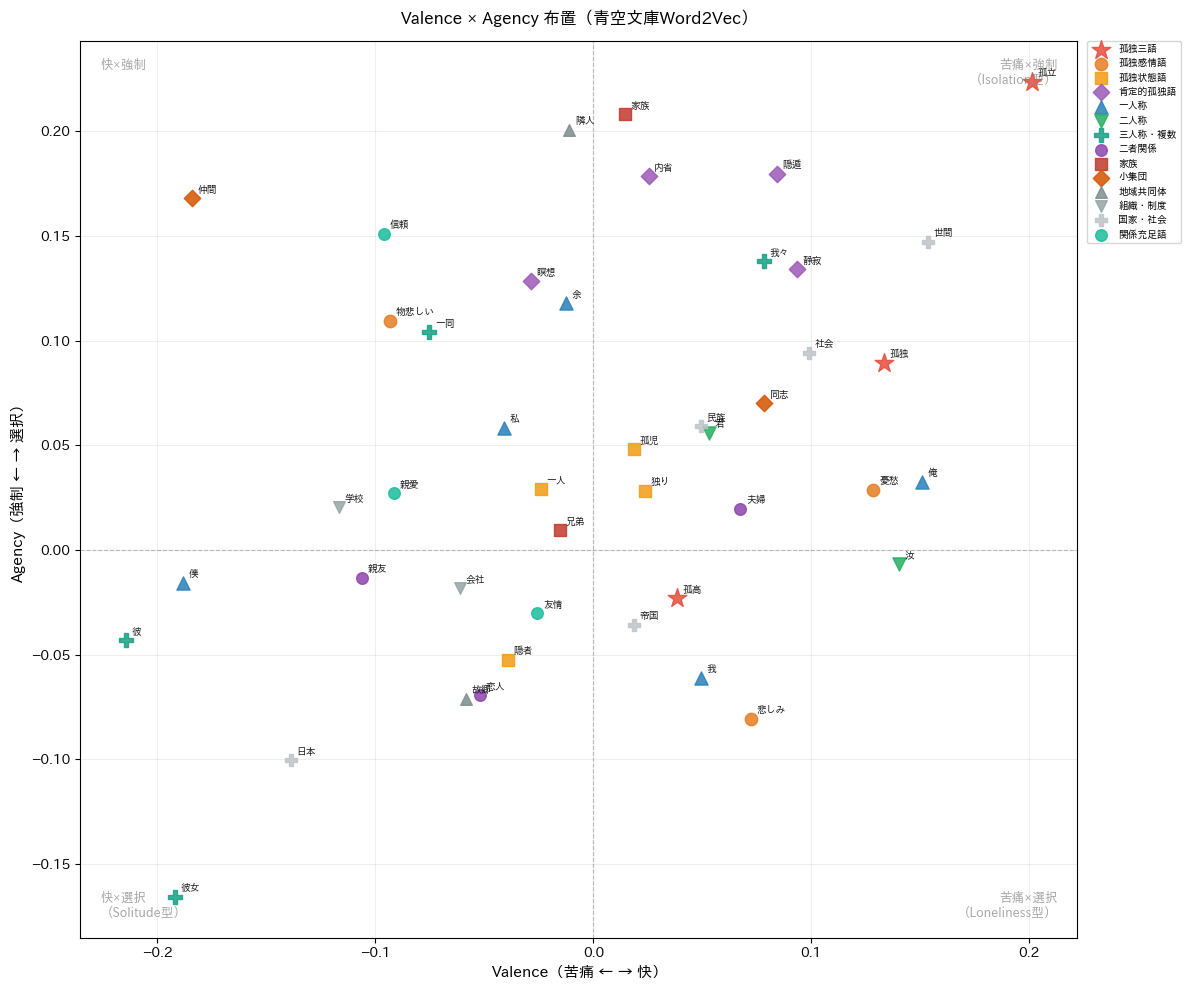

✅ Valence×Agency散布図保存


In [259]:
# Agency軸が加わった状態でStep3・Step4を再実行

# Step 3: スコア再計算
score_data = {}
for word in found_targets:
    scores = {}
    for axis_name, axis_vec in axis_vectors.items():
        scores[axis_name] = axis_score(word, axis_vec, wv)
    score_data[word] = scores

score_df = pd.DataFrame(score_data).T
score_df.columns = [c[:12] for c in score_df.columns]
print(score_df.round(3).to_string())

# Step 4-3: Valence × Agency散布図（今回初めて出力される）
ax_x = "Valence（苦痛↔快）"
ax_y = "Agency（強制↔選択）"

if ax_x in axis_vectors and ax_y in axis_vectors:
    fig, ax = plt.subplots(figsize=(12, 10))
    plot_scatter_with_groups(ax, ax_x, ax_y, found_targets,
                             axis_vectors, wv)

    for (ha, va, x, y, txt) in [
        ('right', 'top',    0.98, 0.98, "苦痛×強制\n（Isolation型）"),
        ('left',  'top',    0.02, 0.98, "快×強制"),
        ('right', 'bottom', 0.98, 0.02, "苦痛×選択\n（Loneliness型）"),
        ('left',  'bottom', 0.02, 0.02, "快×選択\n（Solitude型）"),
    ]:
        ax.text(x, y, txt, transform=ax.transAxes,
                ha=ha, va=va, fontsize=9, color='gray', alpha=0.7)

    ax.set_xlabel("Valence（苦痛 ← → 快）", fontsize=11)
    ax.set_ylabel("Agency（強制 ← → 選択）", fontsize=11)
    ax.set_title("Valence × Agency 布置（青空文庫Word2Vec）", fontsize=12, pad=12)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=7, loc='upper left',
              bbox_to_anchor=(1.01, 1), borderaxespad=0)

    plt.tight_layout()
    plt.savefig("/content/scatter_valence_agency.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Valence×Agency散布図保存")

3/14 Gender軸のSeed words強化

In [260]:
# Gender軸 名詞ベース候補の収録確認
gender_candidates = {
    "男性側": [
        # 性別名詞
        "男性", "男子", "紳士", "壮士", "青年", "少年",
        # 役割名詞
        "夫", "兄", "息子", "祖父", "叔父", "伯父",
        # 文語的
        "男児", "丈夫", "武士", "勇士", "英雄",
    ],
    "女性側": [
        # 性別名詞
        "女性", "女子", "婦人", "淑女", "少女",
        # 役割名詞
        "妻", "姉", "娘", "祖母", "叔母", "伯母",
        # 文語的
        "女児", "乙女", "婦女", "令嬢", "貴婦人",
    ],
}

print("Gender軸 候補語の収録確認:")
for side, words in gender_candidates.items():
    found = [w for w in words if w in wv]
    missing = [w for w in words if w not in wv]
    print(f"\n{side}:")
    print(f"  収録済み: {found}")
    print(f"  未収録  : {missing}")

Gender軸 候補語の収録確認:

男性側:
  収録済み: ['男性', '男子', '紳士', '青年', '少年', '息子', '祖父', '伯父', '武士', '勇士', '英雄']
  未収録  : ['壮士', '夫', '兄', '叔父', '男児', '丈夫']

女性側:
  収録済み: ['女性', '女子', '婦人', '淑女', '少女', '祖母', '伯母', '女児', '乙女', '婦女', '令嬢']
  未収録  : ['妻', '姉', '娘', '叔母', '貴婦人']


In [261]:
# 近傍語で意味的純度を確認
print("=== 男性側候補の近傍語 ===")
for w in ["男性", "男子", "紳士", "青年", "少年", "武士", "英雄"]:
    neighbors = [x for x, _ in wv.most_similar(w, topn=5)]
    print(f"  {w}: {neighbors}")

print("\n=== 女性側候補の近傍語 ===")
for w in ["女性", "女子", "婦人", "淑女", "少女", "乙女", "令嬢"]:
    neighbors = [x for x, _ in wv.most_similar(w, topn=5)]
    print(f"  {w}: {neighbors}")

=== 男性側候補の近傍語 ===
  男性: ['女性', 'ポリネシア', '日系', '中年', 'ミツコ']
  男子: ['合唱', '大地', '婦人', '躄る', '侍する']
  紳士: ['御者', '淑女', 'ラスチニャック', 'ラン', '猟奇']
  青年: ['紳士', '婦人', '令息', '馬番', '教官']
  少年: ['こじる', 'ちんぴら', '少女', '別働', 'コゴロウ']
  武士: ['武者', '公卿', '婆娑羅', '味方', '驕慢']
  英雄: ['権化', '退廃', '神聖', '狂信', 'カリカチュア']

=== 女性側候補の近傍語 ===
  女性: ['男性', '中年', '初老', '年配', 'ポリネシア']
  女子: ['師範', '職員', '在校', '秀才', '働き盛り']
  婦人: ['合唱', '紳士', 'タンバリン', '青年', '用務']
  淑女: ['黒ん坊', '従僕', '抱え上げる', '粧し込む', '私服']
  少女: ['キユウピツド', 'リデル', 'シズコ', '百合', '少年']
  乙女: ['愛らしい', '愛くるしい', 'むちむち', 'オンディーヌ', '着飾る']
  令嬢: ['でぶ', 'アケミ', '徒名', '招待', 'アナベル']


In [262]:
# 厳選したseed wordsで軸を再設計
AXES["Gender（男性↔女性）"] = {
    "pos": ["男性", "少年", "紳士", "青年", "息子"],
    "neg": ["女性", "少女", "乙女", "祖母", "女児"],
    "layer": 2,
    "color": "#F39C12"
}

# 軸ベクトルを再計算
vec, used_pos, used_neg = make_axis_vector(
    AXES["Gender（男性↔女性）"]["pos"],
    AXES["Gender（男性↔女性）"]["neg"],
    wv
)
if vec is not None:
    axis_vectors["Gender（男性↔女性）"] = vec
    print(f"✅ Gender軸 再計算完了")
    print(f"   正極使用語: {used_pos}")
    print(f"   負極使用語: {used_neg}")

# 内的整合性を確認
for side, words in [("正極", used_pos), ("負極", used_neg)]:
    sims = [wv.similarity(a, b) for a, b in combinations(words, 2)]
    print(f"  {side}内部類似度: {np.mean(sims):.3f}")

cross = [wv.similarity(p, n) for p in used_pos for n in used_neg]
print(f"  正負間類似度: {np.mean(cross):.3f}（低いほど軸が明確）")

# 動作確認：一人称のGenderスコアが理論通りか
print("\n一人称のGenderスコア確認:")
for w in ["彼", "彼女", "僕", "私", "俺", "余"]:
    if w in wv:
        score = axis_score(w, axis_vectors["Gender（男性↔女性）"], wv)
        print(f"  {w}: {score:.3f}")

✅ Gender軸 再計算完了
   正極使用語: ['男性', '少年', '紳士', '青年', '息子']
   負極使用語: ['女性', '少女', '乙女', '祖母', '女児']
  正極内部類似度: 0.408
  負極内部類似度: 0.432
  正負間類似度: 0.392（低いほど軸が明確）

一人称のGenderスコア確認:
  彼: 0.109
  彼女: 0.013
  僕: 0.024
  私: -0.014
  俺: -0.005
  余: -0.094


In [263]:
# 「余」の近傍語を確認（どんな文脈で使われているか）
print("「余」の近傍語:")
print([x for x, _ in wv.most_similar("余", topn=10)])

# seed wordsに「彼・僕・俺」を正極に追加したバージョンも試す
print("\n--- 代名詞追加バージョン ---")
vec2, used_pos2, used_neg2 = make_axis_vector(
    ["男性", "少年", "紳士", "青年", "息子", "彼", "僕", "俺"],
    ["女性", "少女", "乙女", "祖母", "女児", "彼女"],
    wv
)
if vec2 is not None:
    for side, words in [("正極", used_pos2), ("負極", used_neg2)]:
        sims = [wv.similarity(a, b) for a, b in combinations(words, 2)]
        print(f"  {side}内部類似度: {np.mean(sims):.3f}")
    cross2 = [wv.similarity(p, n) for p in used_pos2 for n in used_neg2]
    print(f"  正負間類似度: {np.mean(cross2):.3f}")

    print("\n一人称スコア（代名詞追加版）:")
    for w in ["彼", "彼女", "僕", "私", "俺", "余"]:
        if w in wv:
            score = axis_score(w, vec2, wv)
            print(f"  {w}: {score:.3f}")

「余」の近傍語:
['才知', 'キワム', '祝着', '仰ける', '成敗', '障り', '貴殿', '主従', '御名', '忠節']

--- 代名詞追加バージョン ---
  正極内部類似度: 0.365
  負極内部類似度: 0.436
  正負間類似度: 0.380

一人称スコア（代名詞追加版）:
  彼: 0.019
  彼女: -0.238
  僕: 0.197
  私: 0.030
  俺: 0.373
  余: -0.097


In [264]:
# Gender軸を代名詞追加版で確定
AXES["Gender（男性↔女性）"] = {
    "pos": ["男性", "少年", "紳士", "青年", "息子", "彼", "僕", "俺"],
    "neg": ["女性", "少女", "乙女", "祖母", "女児", "彼女"],
    "layer": 2,
    "color": "#F39C12"
}
axis_vectors["Gender（男性↔女性）"] = vec2
print("✅ Gender軸 確定（代名詞追加版）")

# 全軸の内的整合性を最終確認
print("\n【全軸 内的整合性サマリー】")
print(f"{'軸名':<28} {'正極内部':>8} {'負極内部':>8} {'正負間':>8}")
print("-" * 58)
for axis_name, axis_data in AXES.items():
    pos_words = [w for w in axis_data["pos"] if w in wv]
    neg_words = [w for w in axis_data["neg"] if w in wv]
    if len(pos_words) < 2 or len(neg_words) < 2:
        print(f"{axis_name:<28} {'語数不足':>8}")
        continue
    pos_sim = np.mean([wv.similarity(a,b) for a,b in combinations(pos_words,2)])
    neg_sim = np.mean([wv.similarity(a,b) for a,b in combinations(neg_words,2)])
    cross   = np.mean([wv.similarity(p,n) for p in pos_words for n in neg_words])
    print(f"{axis_name:<28} {pos_sim:>8.3f} {neg_sim:>8.3f} {cross:>8.3f}")

✅ Gender軸 確定（代名詞追加版）

【全軸 内的整合性サマリー】
軸名                               正極内部     負極内部      正負間
----------------------------------------------------------
Loneliness↔Companionship        0.543    0.526    0.532
Isolation↔Belonging             0.616    0.639    0.560
Solitude↔Conformity             0.620    0.410    0.524
Valence（苦痛↔快）                   0.539    0.570    0.456
Agency（強制↔選択）                   0.759    0.495    0.544
Gender（男性↔女性）                   0.365    0.436    0.380
Status（高地位↔低地位）                 0.505    0.533    0.488


In [265]:
# 全軸確定後の最終スコア計算・可視化を一括実行
# （semantic_axes_analysis_v3.pyのStep3・Step4部分を再実行）

# Step 3: 全ターゲット語のスコアを再計算
score_data = {}
for word in found_targets:
    scores = {}
    for axis_name, axis_vec in axis_vectors.items():
        scores[axis_name] = axis_score(word, axis_vec, wv)
    score_data[word] = scores

score_df = pd.DataFrame(score_data).T
print("✅ スコア再計算完了")
print(f"   対象語数: {len(score_df)}語 × {len(score_df.columns)}軸")

# Step 4: 全図を再出力
# ヒートマップ・孤独三軸散布図・Valence×Agency・社会レイヤー図
# （semantic_axes_analysis_v3.pyのStep4ブロックをそのまま実行）

✅ スコア再計算完了
   対象語数: 44語 × 7軸




【Step 3】ターゲット語の軸スコア
正値 → 正極（孤独・苦痛・強制・男性・高地位）寄り
負値 → 負極（共在・快・選択・女性・低地位）寄り
      Loneliness↔C  Isolation↔Be  Solitude↔Con  Valence（苦痛↔快  Gender（男性↔女性  Status（高地位↔低  Agency（強制↔選択
孤独           0.325        -0.108         0.110         0.133        -0.114         0.010         0.090
孤立           0.083         0.528         0.306         0.201        -0.008         0.088         0.224
孤高           0.031         0.193         0.369         0.038        -0.024         0.247        -0.023
悲しみ          0.345        -0.102        -0.029         0.072        -0.289         0.009        -0.081
憂愁           0.438        -0.048        -0.003         0.128        -0.143         0.063         0.029
物悲しい         0.404        -0.258        -0.191        -0.093        -0.093        -0.096         0.110
一人           0.099        -0.093        -0.017        -0.024        -0.032        -0.078         0.029
独り           0.343        -0.181        -0.217         0.024        -0.189        -0.138         0.02

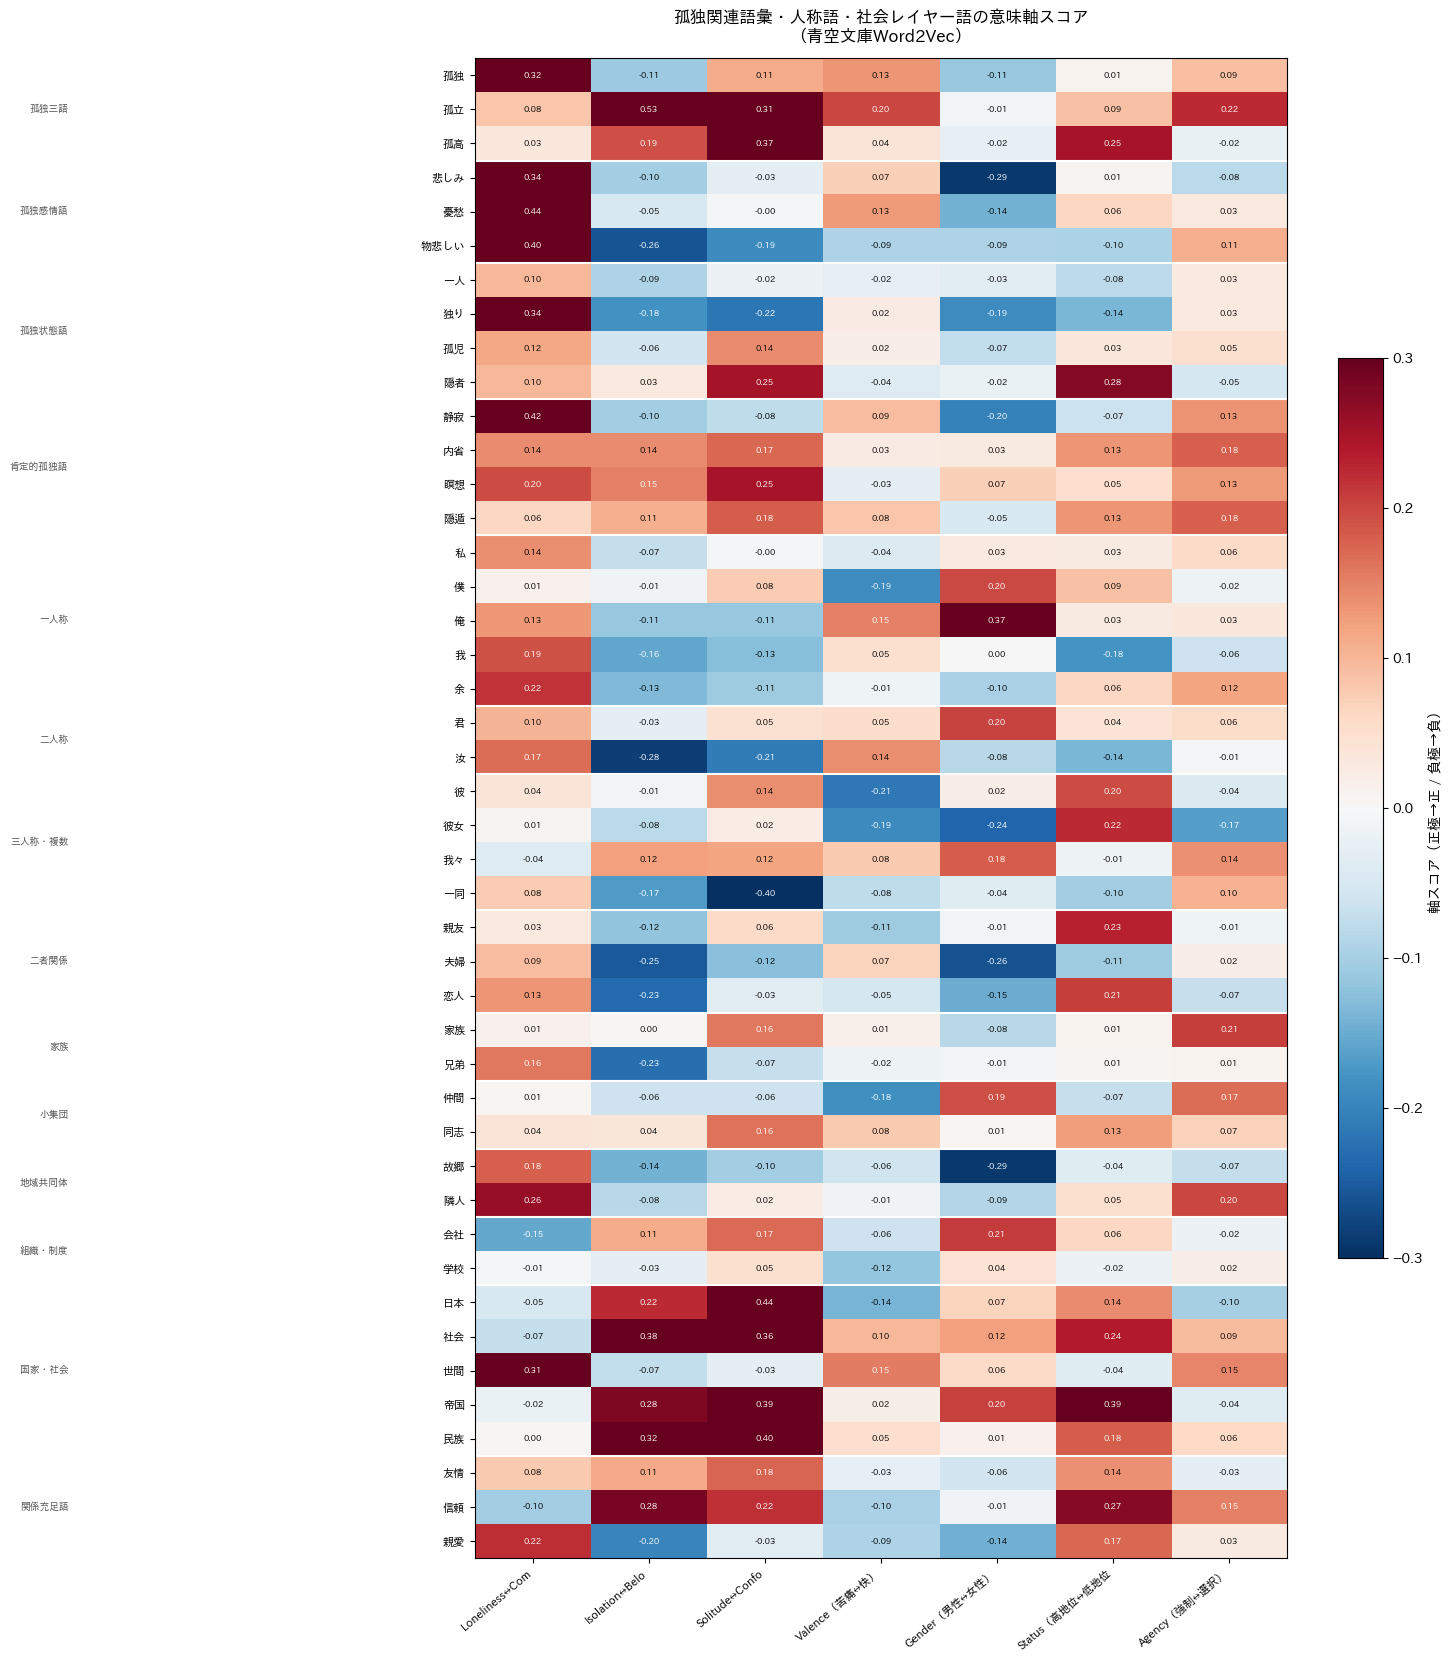

✅ ヒートマップ保存: /content/heatmap_axes.png


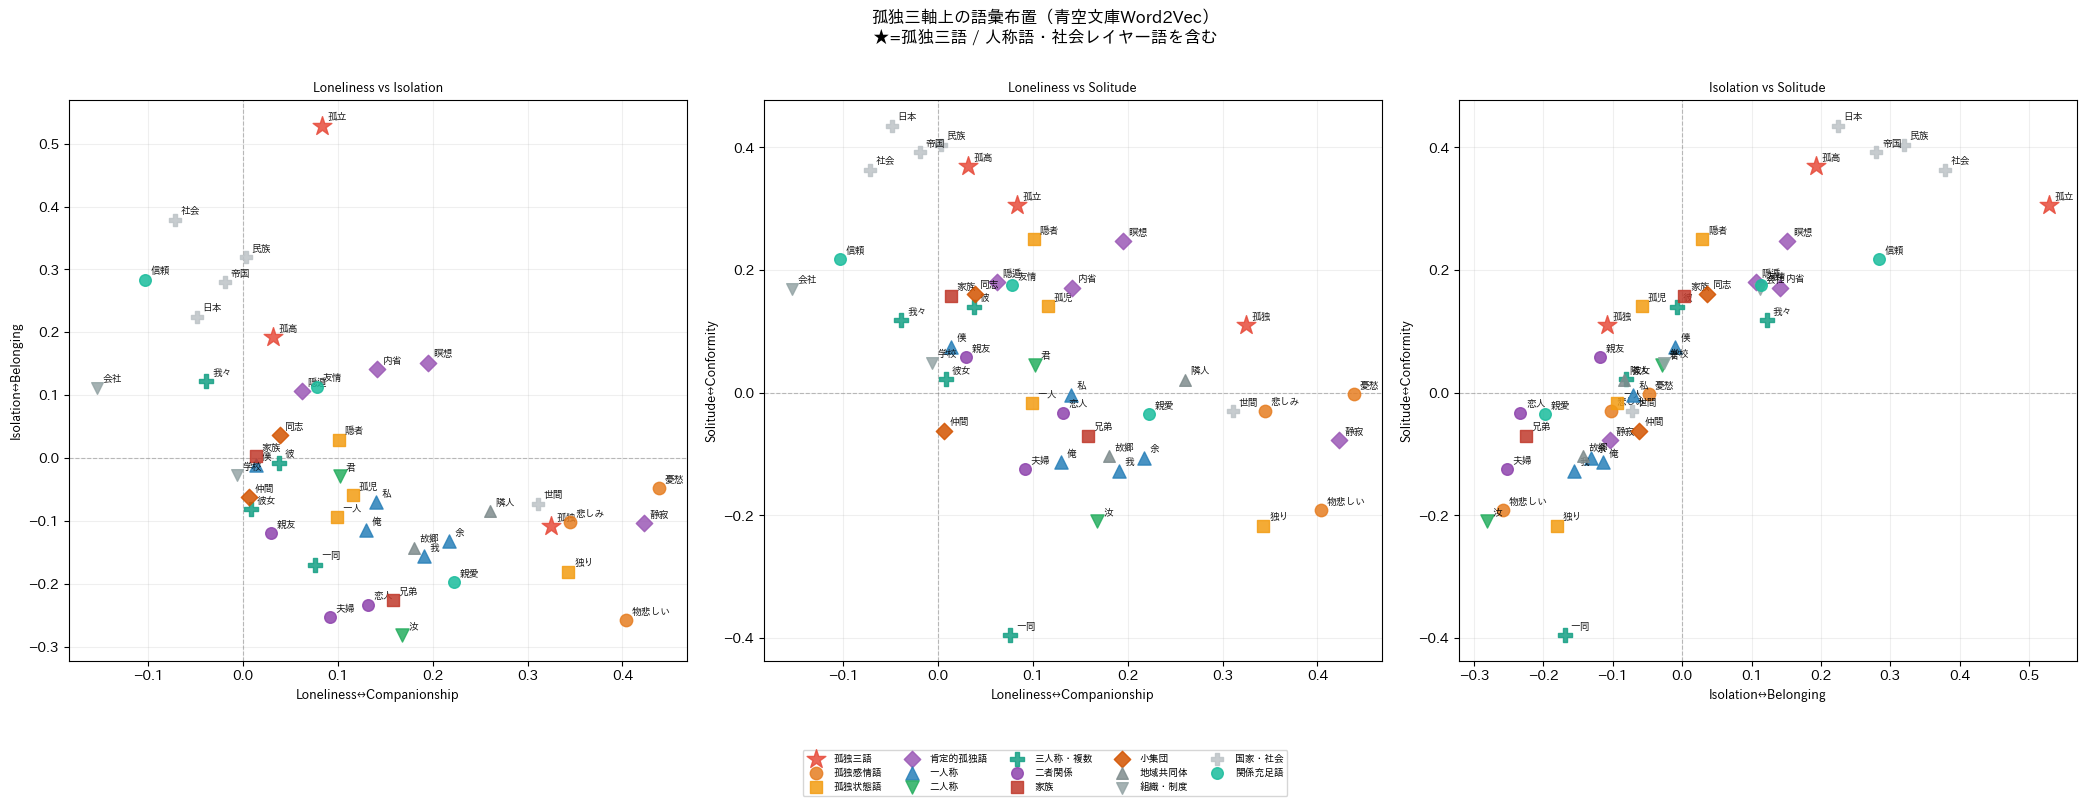

✅ 孤独三軸散布図保存: /content/scatter_loneliness_axes.png


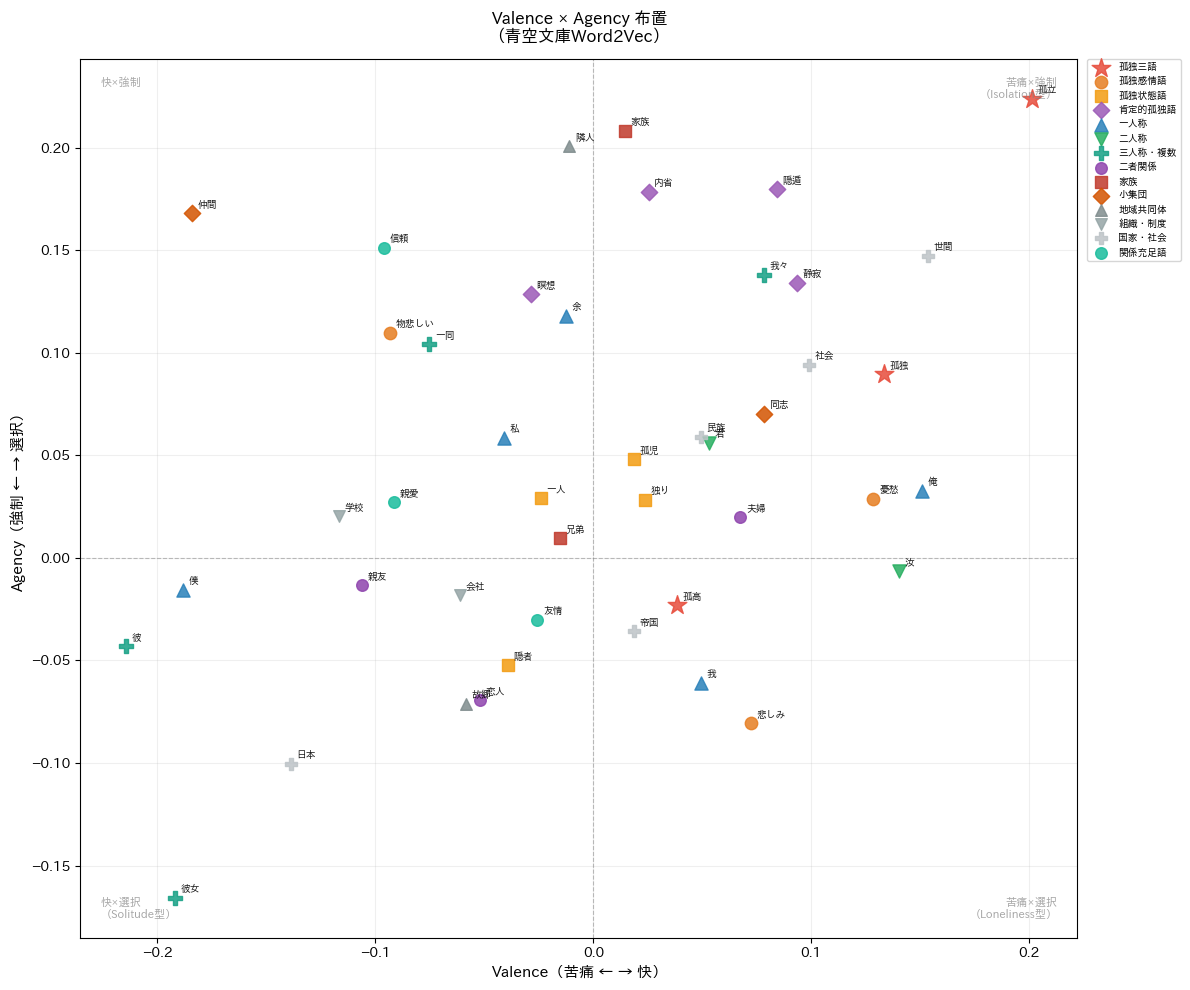

✅ Valence×Agency散布図保存: /content/scatter_valence_agency.png


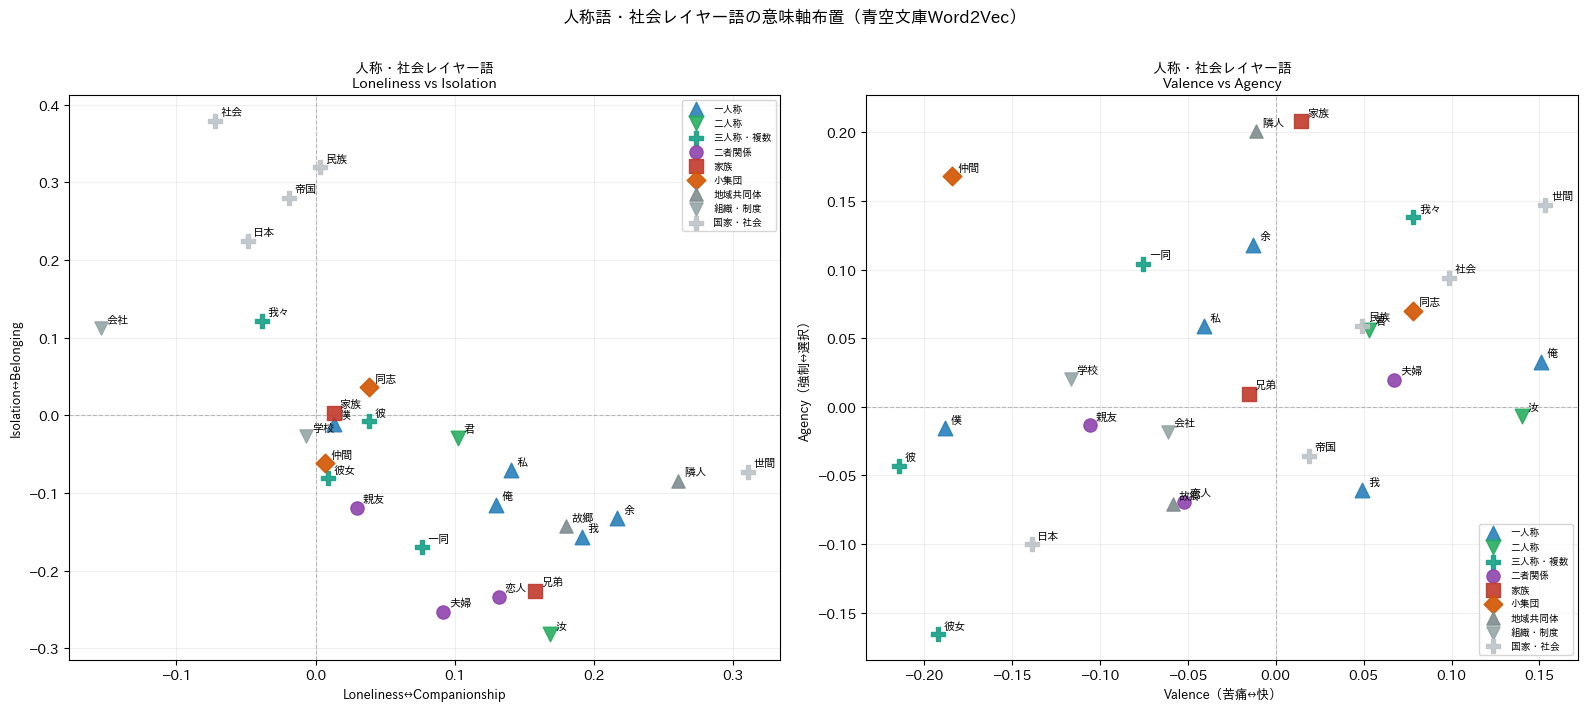

✅ 社会レイヤー散布図保存: /content/scatter_social_layers.png


In [266]:
# ============================================================
# Step 3: ターゲット語の各軸スコア計算
# ============================================================

def axis_score(word, axis_vec, wv):
    """単語の軸スコア（正極方向が正）"""
    if word not in wv:
        return np.nan
    word_vec = wv[word] / np.linalg.norm(wv[word])
    return float(np.dot(word_vec, axis_vec))


print("\n\n" + "=" * 60)
print("【Step 3】ターゲット語の軸スコア")
print("正値 → 正極（孤独・苦痛・強制・男性・高地位）寄り")
print("負値 → 負極（共在・快・選択・女性・低地位）寄り")
print("=" * 60)

score_data = {}
for word in found_targets:
    scores = {}
    for axis_name, axis_vec in axis_vectors.items():
        scores[axis_name] = axis_score(word, axis_vec, wv)
    score_data[word] = scores

score_df = pd.DataFrame(score_data).T
score_df.columns = [c[:12] for c in score_df.columns]
print(score_df.round(3).to_string())


# ============================================================
# Step 4: 可視化
# ============================================================

def plot_scatter_with_groups(ax_plot, ax_x_name, ax_y_name, found_targets,
                              axis_vectors, wv, title=""):
    """グループ別色分け散布図の共通描画関数"""
    if ax_x_name not in axis_vectors or ax_y_name not in axis_vectors:
        return

    for gname, gdata in TARGET_GROUPS.items():
        words_in_group = [w for w in gdata["words"] if w in found_targets]
        if not words_in_group:
            continue

        xs = [axis_score(w, axis_vectors[ax_x_name], wv) for w in words_in_group]
        ys = [axis_score(w, axis_vectors[ax_y_name], wv) for w in words_in_group]

        valid = [(w, x, y) for w, x, y in zip(words_in_group, xs, ys)
                 if not (np.isnan(x) or np.isnan(y))]
        if not valid:
            continue

        ws, vxs, vys = zip(*valid)
        ax_plot.scatter(vxs, vys,
                        c=gdata["color"],
                        marker=gdata["marker"],
                        s=gdata["size"],
                        alpha=0.85,
                        label=gname,
                        zorder=3)
        for w, x, y in valid:
            ax_plot.annotate(w, (x, y),
                             textcoords="offset points",
                             xytext=(4, 4), fontsize=7, alpha=0.9)

    ax_plot.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_plot.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_plot.set_xlabel(ax_x_name, fontsize=9)
    ax_plot.set_ylabel(ax_y_name, fontsize=9)
    ax_plot.set_title(title or f"{ax_x_name[:18]}\nvs {ax_y_name[:18]}", fontsize=9)
    ax_plot.grid(True, alpha=0.2)


# ── 4-1: ヒートマップ（全軸 × 全ターゲット語）──────────────
# グループ順にソートして表示
sorted_targets = [w for g in TARGET_GROUPS.values()
                  for w in g["words"] if w in found_targets]

score_data_sorted = {}
for word in sorted_targets:
    scores = {}
    for axis_name, axis_vec in axis_vectors.items():
        scores[axis_name] = axis_score(word, axis_vec, wv)
    score_data_sorted[word] = scores

score_df_sorted = pd.DataFrame(score_data_sorted).T
col_labels = [c[:14] for c in score_df_sorted.columns]

# グループ境界の位置を計算
group_boundaries = []
idx = 0
for gname, gdata in TARGET_GROUPS.items():
    count = len([w for w in gdata["words"] if w in found_targets])
    if count > 0:
        group_boundaries.append((idx, idx + count, gname))
        idx += count

fig, ax = plt.subplots(figsize=(16, max(8, len(sorted_targets) * 0.38)))
data = score_df_sorted.values
im = ax.imshow(data, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(len(score_df_sorted.index)))
ax.set_yticklabels(score_df_sorted.index, fontsize=8)

# グループ境界線を描画
for start, end, gname in group_boundaries:
    if start > 0:
        ax.axhline(start - 0.5, color='white', linewidth=1.5)
    # グループ名を左端に表示
    ax.text(-0.5, (start + end - 1) / 2, gname,
            ha='right', va='center', fontsize=7,
            color='#555555', transform=ax.get_yaxis_transform())

plt.colorbar(im, ax=ax, label='軸スコア（正極→正 / 負極→負）', shrink=0.6)
ax.set_title("孤独関連語彙・人称語・社会レイヤー語の意味軸スコア\n（青空文庫Word2Vec）",
             fontsize=12, pad=12)

# 値をセルに表示
for i in range(len(score_df_sorted.index)):
    for j in range(len(col_labels)):
        val = data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                    fontsize=6, color='white' if abs(val) > 0.15 else 'black')

plt.tight_layout()
plt.savefig("/content/heatmap_axes.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ ヒートマップ保存: /content/heatmap_axes.png")


# ── 4-2: 孤独三軸の散布図（3ペア）────────────────────────────
axis_pairs_l1 = [
    ("Loneliness↔Companionship", "Isolation↔Belonging",
     "Loneliness vs Isolation"),
    ("Loneliness↔Companionship", "Solitude↔Conformity",
     "Loneliness vs Solitude"),
    ("Isolation↔Belonging",      "Solitude↔Conformity",
     "Isolation vs Solitude"),
]

fig, axes_plot = plt.subplots(1, 3, figsize=(21, 7))
for ax_plot, (ax_x, ax_y, title) in zip(axes_plot, axis_pairs_l1):
    plot_scatter_with_groups(ax_plot, ax_x, ax_y, found_targets,
                             axis_vectors, wv, title=title)

# 凡例を最後のサブプロットに付ける
handles, labels = axes_plot[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5,
           fontsize=7, bbox_to_anchor=(0.5, -0.12))

plt.suptitle("孤独三軸上の語彙布置（青空文庫Word2Vec）\n"
             "★=孤独三語 / 人称語・社会レイヤー語を含む",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("/content/scatter_loneliness_axes.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ 孤独三軸散布図保存: /content/scatter_loneliness_axes.png")


# ── 4-3: Valence × Agency 散布図 ────────────────────────────
ax_x = "Valence（苦痛↔快）"
ax_y = "Agency（強制↔選択）"

if ax_x in axis_vectors and ax_y in axis_vectors:
    fig, ax = plt.subplots(figsize=(12, 10))
    plot_scatter_with_groups(ax, ax_x, ax_y, found_targets,
                             axis_vectors, wv)

    # 象限ラベル
    for (ha, va, x, y, txt) in [
        ('right', 'top',    0.98, 0.98, "苦痛×強制\n（Isolation型）"),
        ('left',  'top',    0.02, 0.98, "快×強制"),
        ('right', 'bottom', 0.98, 0.02, "苦痛×選択\n（Loneliness型）"),
        ('left',  'bottom', 0.02, 0.02, "快×選択\n（Solitude型）"),
    ]:
        ax.text(x, y, txt, transform=ax.transAxes,
                ha=ha, va=va, fontsize=8, color='gray', alpha=0.7)

    ax.set_xlabel("Valence（苦痛 ← → 快）", fontsize=11)
    ax.set_ylabel("Agency（強制 ← → 選択）", fontsize=11)
    ax.set_title("Valence × Agency 布置\n（青空文庫Word2Vec）", fontsize=12, pad=12)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=7, loc='upper left',
              bbox_to_anchor=(1.01, 1), borderaxespad=0)

    plt.tight_layout()
    plt.savefig("/content/scatter_valence_agency.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Valence×Agency散布図保存: /content/scatter_valence_agency.png")


# ── 4-4: 社会レイヤー × 孤独三軸（社会スケール別の布置）────
# 人称・社会レイヤー語だけを抽出して孤独三軸上に布置
social_groups = ["一人称", "二人称", "三人称・複数",
                 "二者関係", "家族", "小集団",
                 "地域共同体", "組織・制度", "国家・社会"]
social_words = [w for gn in social_groups
                for w in TARGET_GROUPS[gn]["words"] if w in found_targets]

if social_words and "Loneliness↔Companionship" in axis_vectors:
    fig, axes_plot = plt.subplots(1, 2, figsize=(16, 7))

    for ax_plot, (ax_x, ax_y, title) in zip(axes_plot, [
        ("Loneliness↔Companionship", "Isolation↔Belonging",
         "人称・社会レイヤー語\nLoneliness vs Isolation"),
        ("Valence（苦痛↔快）", "Agency（強制↔選択）",
         "人称・社会レイヤー語\nValence vs Agency"),
    ]):
        if ax_x not in axis_vectors or ax_y not in axis_vectors:
            continue
        for gname in social_groups:
            gdata = TARGET_GROUPS[gname]
            words = [w for w in gdata["words"] if w in found_targets]
            if not words:
                continue
            xs = [axis_score(w, axis_vectors[ax_x], wv) for w in words]
            ys = [axis_score(w, axis_vectors[ax_y], wv) for w in words]
            valid = [(w, x, y) for w, x, y in zip(words, xs, ys)
                     if not (np.isnan(x) or np.isnan(y))]
            if not valid:
                continue
            ws, vxs, vys = zip(*valid)
            ax_plot.scatter(vxs, vys,
                            c=gdata["color"], marker=gdata["marker"],
                            s=gdata["size"] + 20, alpha=0.9,
                            label=gname, zorder=3)
            for w, x, y in valid:
                ax_plot.annotate(w, (x, y), textcoords="offset points",
                                 xytext=(4, 4), fontsize=8)

        ax_plot.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
        ax_plot.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
        ax_plot.set_xlabel(ax_x, fontsize=9)
        ax_plot.set_ylabel(ax_y, fontsize=9)
        ax_plot.set_title(title, fontsize=10)
        ax_plot.grid(True, alpha=0.2)
        ax_plot.legend(fontsize=7, loc='best')

    plt.suptitle("人称語・社会レイヤー語の意味軸布置（青空文庫Word2Vec）",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig("/content/scatter_social_layers.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ 社会レイヤー散布図保存: /content/scatter_social_layers.png")


In [267]:
# ============================================================
# Step 5: 軸の内的整合性チェック（seed words同士のコサイン類似度）
# ============================================================

print("\n\n" + "=" * 60)
print("【Step 5】軸の内的整合性チェック")
print("同一極内の語同士の類似度平均（高いほど軸が安定）")
print("=" * 60)

for axis_name, axis_data in AXES.items():
    pos_words = [w for w in axis_data["pos"] if w in wv]
    neg_words = [w for w in axis_data["neg"] if w in wv]

    def mean_sim(words, wv):
        if len(words) < 2:
            return np.nan
        sims = [wv.similarity(a, b)
                for a, b in combinations(words, 2)]
        return np.mean(sims)

    pos_sim = mean_sim(pos_words, wv)
    neg_sim = mean_sim(neg_words, wv)

    # 正極と負極の分離度（正極語と負極語の類似度平均）
    cross_sims = []
    for p in pos_words:
        for n in neg_words:
            cross_sims.append(wv.similarity(p, n))
    cross_sim = np.mean(cross_sims) if cross_sims else np.nan

    print(f"\n{axis_name}")
    print(f"  正極内部類似度: {pos_sim:.3f}" if not np.isnan(pos_sim) else "  正極: 語数不足")
    print(f"  負極内部類似度: {neg_sim:.3f}" if not np.isnan(neg_sim) else "  負極: 語数不足")
    print(f"  正負間類似度  : {cross_sim:.3f}（低いほど軸が明確）"
          if not np.isnan(cross_sim) else "  正負間: 計算不能")

print("\n✅ 分析完了")
print("出力ファイル:")
print("  /content/heatmap_axes.png            （全軸ヒートマップ）")
print("  /content/scatter_loneliness_axes.png （孤独三軸散布図）")
print("  /content/scatter_valence_agency.png  （Valence×Agency散布図）")
print("  /content/scatter_social_layers.png   （社会レイヤー語散布図）")




【Step 5】軸の内的整合性チェック
同一極内の語同士の類似度平均（高いほど軸が安定）

Loneliness↔Companionship
  正極内部類似度: 0.543
  負極内部類似度: 0.526
  正負間類似度  : 0.532（低いほど軸が明確）

Isolation↔Belonging
  正極内部類似度: 0.616
  負極内部類似度: 0.639
  正負間類似度  : 0.560（低いほど軸が明確）

Solitude↔Conformity
  正極内部類似度: 0.620
  負極内部類似度: 0.410
  正負間類似度  : 0.524（低いほど軸が明確）

Valence（苦痛↔快）
  正極内部類似度: 0.539
  負極内部類似度: 0.570
  正負間類似度  : 0.456（低いほど軸が明確）

Agency（強制↔選択）
  正極内部類似度: 0.759
  負極内部類似度: 0.495
  正負間類似度  : 0.544（低いほど軸が明確）

Gender（男性↔女性）
  正極内部類似度: 0.365
  負極内部類似度: 0.436
  正負間類似度  : 0.380（低いほど軸が明確）

Status（高地位↔低地位）
  正極内部類似度: 0.505
  負極内部類似度: 0.533
  正負間類似度  : 0.488（低いほど軸が明確）

✅ 分析完了
出力ファイル:
  /content/heatmap_axes.png            （全軸ヒートマップ）
  /content/scatter_loneliness_axes.png （孤独三軸散布図）
  /content/scatter_valence_agency.png  （Valence×Agency散布図）
  /content/scatter_social_layers.png   （社会レイヤー語散布図）


3/14 Isolation軸の精緻化

In [268]:
# Isolation軸 正極の代替候補確認
isolation_pos_candidates = [
    # 社会的切断・排除系
    "排除", "排斥", "追放", "疎外", "隔絶", "隔離",
    "絶縁", "遮断", "分断", "孤絶", "離隔", "離反",
    # 関係の欠如系
    "没交渉", "没交渉", "音信不通", "疎略",
    # 文語的
    "流離", "流浪", "放逐", "逐放",
]

print("Isolation軸 正極候補の収録確認:")
for w in isolation_pos_candidates:
    if w in wv:
        neighbors = [x for x, _ in wv.most_similar(w, topn=4)]
        print(f"  ✅ {w}: {neighbors}")
    else:
        print(f"  ❌ {w}")

Isolation軸 正極候補の収録確認:
  ✅ 排除: ['源泉', '盲従', '減税', '漸進']
  ✅ 排斥: ['独り善がり', '軽侮', '打算', '幻滅']
  ✅ 追放: ['カダ', '役立てる', '死罪', '奪取']
  ✅ 疎外: ['能動', '発現', '萌芽', '遊離']
  ✅ 隔絶: ['深甚', '暴威', '古記', '琢磨']
  ✅ 隔離: ['平々', '酷使', '浸潤', '忘れ去る']
  ✅ 絶縁: ['守り立てる', '淫奔', '師弟', '東慶']
  ✅ 遮断: ['阻む', '介入', '浸潤', '法定']
  ✅ 分断: ['産土', 'タダマサ', '浜手', '武威']
  ❌ 孤絶
  ❌ 離隔
  ✅ 離反: ['挙兵', '君臣', '平定', 'チトシ']
  ❌ 没交渉
  ❌ 没交渉
  ❌ 音信不通
  ❌ 疎略
  ✅ 流離: ['将兵', 'ワキハマ', '早稲', '刈り入れる']
  ✅ 流浪: ['カダ', '不和', '疱瘡', '假初']
  ✅ 放逐: ['守り立てる', '憂国', 'サボタージュ', '国辱']
  ❌ 逐放


In [269]:
# 現正極語との類似度で候補を評価
current_pos = ["孤立", "断絶"]
candidates = ["排斥", "疎外", "隔絶", "排除", "遮断", "流浪", "放逐", "離反"]

print("現正極語（孤立・断絶）との類似度:")
print(f"{'語':<10} {'孤立との類似度':>14} {'断絶との類似度':>14} {'平均':>8}")
print("-" * 50)
for w in candidates:
    if w in wv:
        sim_korit = wv.similarity(w, "孤立")
        sim_danzetsu = wv.similarity(w, "断絶")
        avg = (sim_korit + sim_danzetsu) / 2
        print(f"{w:<10} {sim_korit:>14.3f} {sim_danzetsu:>14.3f} {avg:>8.3f}")


現正極語（孤立・断絶）との類似度:
語                 孤立との類似度        断絶との類似度       平均
--------------------------------------------------
排斥                  0.699          0.590    0.644
疎外                  0.756          0.713    0.735
隔絶                  0.706          0.795    0.750
排除                  0.703          0.710    0.706
遮断                  0.683          0.600    0.642
流浪                  0.426          0.605    0.515
放逐                  0.630          0.783    0.706
離反                  0.652          0.756    0.704


In [270]:
# Isolation軸を更新して整合性確認
AXES["Isolation↔Belonging"]["pos"] = ["孤立", "断絶", "隔絶", "疎外", "排除"]

vec, used_pos, used_neg = make_axis_vector(
    AXES["Isolation↔Belonging"]["pos"],
    AXES["Isolation↔Belonging"]["neg"],
    wv
)
axis_vectors["Isolation↔Belonging"] = vec

print("✅ Isolation軸 正極更新")
print(f"   正極使用語: {used_pos}")
print(f"   負極使用語: {used_neg}")

for side, words in [("正極", used_pos), ("負極", used_neg)]:
    sims = [wv.similarity(a,b) for a,b in combinations(words,2)]
    print(f"  {side}内部類似度: {np.mean(sims):.3f}")
cross = [wv.similarity(p,n) for p in used_pos for n in used_neg]
print(f"  正負間類似度: {np.mean(cross):.3f}")

✅ Isolation軸 正極更新
   正極使用語: ['孤立', '断絶', '隔絶', '疎外', '排除']
   負極使用語: ['交わり', '親交', '有縁']
  正極内部類似度: 0.735
  負極内部類似度: 0.639
  正負間類似度: 0.537


3/14 Loneliness精緻化

In [271]:
# Loneliness負極・Isolation負極の代替候補を同時確認
candidates = {
    "Loneliness負極（Companionship）": [
        "親睦", "親密", "和睦", "融和", "和合", "懇意",
        "馴染む", "親しむ", "慕う", "温もり", "温かみ",
        "安堵", "安心", "平穏", "穏やか", "のどか",
    ],
    "Isolation負極（Belonging）": [
        "連帯", "提携", "結束", "団結", "紐帯", "繋がり",
        "縁故", "縁組", "共同体", "帰属", "所属", "仲間入り",
    ],
}

for group, words in candidates.items():
    print(f"\n{group}:")
    for w in words:
        if w in wv:
            neighbors = [x for x, _ in wv.most_similar(w, topn=4)]
            print(f"  ✅ {w}: {neighbors}")
        else:
            print(f"  ❌ {w}")


Loneliness負極（Companionship）:
  ✅ 親睦: ['淘汰', '是認', '克己', '難局']
  ✅ 親密: ['気詰まり', '付き物', '華やぎ', 'ホソキ']
  ✅ 和睦: ['捨給', '修築', '諸政', '帰府']
  ✅ 融和: ['具備', '痛苦', 'Modalita', '理会']
  ✅ 和合: ['孝貞', '賣柄', '孝道', '取用']
  ✅ 懇意: ['出精', '常々', '身請け', '白鼠']
  ✅ 馴染む: ['居着く', '入浴', '独り暮らし', '耄碌']
  ✅ 親しむ: ['高尚', '根差す', '富裕', '真正']
  ✅ 慕う: ['最愛', '宿す', '尼公', '仇敵']
  ✅ 温もり: ['疼き', '春日', '触感', '擽る']
  ✅ 温かみ: ['暗影', '酒臭い', '水飴', '丸見え']
  ✅ 安堵: ['タノモ', '心成し', '逢度', '喜悦']
  ✅ 安心: ['ほっと', '撫で下ろす', '辞去', '歓待']
  ✅ 平穏: ['無為', '葛藤', '世俗', '安穏']
  ❌ 穏やか
  ❌ のどか

Isolation負極（Belonging）:
  ✅ 連帯: ['儀礼', '抑圧', '浄化', '因習']
  ✅ 提携: ['両社', 'オペレーション', 'ビジコープ', 'PS']
  ✅ 結束: ['輩出', '覇権', '帰一', '是認']
  ✅ 団結: ['虐待', '拘束', '儀礼', '連帯']
  ❌ 紐帯
  ✅ 繋がり: ['付き物', '不離', '尺度', '感受']
  ✅ 縁故: ['良縁', '忠実忠実しい', '父宮', '跡継ぎ']
  ✅ 縁組: ['厄落とし', '成敗', '偽者', '孝道']
  ❌ 共同体
  ❌ 帰属
  ✅ 所属: ['嘱託', '入会', '全米', '進学']
  ❌ 仲間入り


In [272]:
# 現負極語との類似度で候補を評価
print("【Loneliness負極】現負極語（充実・心強い・慰む）との類似度:")
current_lon_neg = ["充実", "心強い", "慰む"]
lon_candidates = ["安心", "慕う", "安堵", "親しむ", "親睦", "親密", "温もり"]

print(f"{'語':<10} {'充実':>8} {'心強い':>8} {'慰む':>8} {'平均':>8}")
print("-" * 42)
for w in lon_candidates:
    if w in wv:
        sims = [wv.similarity(w, ref) for ref in current_lon_neg]
        print(f"{w:<10} {sims[0]:>8.3f} {sims[1]:>8.3f} {sims[2]:>8.3f} {np.mean(sims):>8.3f}")

print("\n【Isolation負極】現負極語（交わり・親交・有縁）との類似度:")
current_iso_neg = ["交わり", "親交", "有縁"]
iso_candidates = ["連帯", "団結", "繋がり", "縁故", "結束", "所属"]

print(f"{'語':<10} {'交わり':>8} {'親交':>8} {'有縁':>8} {'平均':>8}")
print("-" * 42)
for w in iso_candidates:
    if w in wv:
        sims = [wv.similarity(w, ref) for ref in current_iso_neg]
        print(f"{w:<10} {sims[0]:>8.3f} {sims[1]:>8.3f} {sims[2]:>8.3f} {np.mean(sims):>8.3f}")

【Loneliness負極】現負極語（充実・心強い・慰む）との類似度:
語                充実      心強い       慰む       平均
------------------------------------------
安心            0.297    0.551    0.580    0.476
慕う            0.254    0.656    0.632    0.514
安堵            0.315    0.639    0.637    0.530
親しむ           0.458    0.489    0.544    0.497
親睦            0.619    0.548    0.627    0.598
親密            0.551    0.445    0.551    0.516
温もり           0.525    0.460    0.583    0.523

【Isolation負極】現負極語（交わり・親交・有縁）との類似度:
語               交わり       親交       有縁       平均
------------------------------------------
連帯            0.372    0.606    0.491    0.490
団結            0.471    0.553    0.590    0.538
繋がり           0.372    0.535    0.479    0.462
縁故            0.551    0.749    0.738    0.679
結束            0.442    0.682    0.647    0.590
所属            0.101    0.589    0.353    0.348


In [273]:
# 両軸の負極を更新して整合性確認
AXES["Loneliness↔Companionship"]["neg"] = [
    "充実", "心強い", "慰む", "親睦", "安堵", "温もり"
]
AXES["Isolation↔Belonging"]["neg"] = [
    "交わり", "親交", "有縁", "縁故", "結束", "団結"
]

for axis_name in ["Loneliness↔Companionship", "Isolation↔Belonging"]:
    vec, used_pos, used_neg = make_axis_vector(
        AXES[axis_name]["pos"],
        AXES[axis_name]["neg"],
        wv
    )
    axis_vectors[axis_name] = vec

    pos_sim = np.mean([wv.similarity(a,b) for a,b in combinations(used_pos,2)])
    neg_sim = np.mean([wv.similarity(a,b) for a,b in combinations(used_neg,2)])
    cross   = np.mean([wv.similarity(p,n) for p in used_pos for n in used_neg])

    print(f"\n✅ {axis_name}")
    print(f"   正極使用語: {used_pos}")
    print(f"   負極使用語: {used_neg}")
    print(f"  正極内部類似度: {pos_sim:.3f}")
    print(f"  負極内部類似度: {neg_sim:.3f}")
    print(f"  正負間類似度  : {cross:.3f}")


✅ Loneliness↔Companionship
   正極使用語: ['寂しい', '空虚', '心細い', '憂鬱', '憂い', '煩悶']
   負極使用語: ['充実', '心強い', '慰む', '親睦', '安堵', '温もり']
  正極内部類似度: 0.543
  負極内部類似度: 0.533
  正負間類似度  : 0.521

✅ Isolation↔Belonging
   正極使用語: ['孤立', '断絶', '隔絶', '疎外', '排除']
   負極使用語: ['交わり', '親交', '有縁', '縁故', '結束', '団結']
  正極内部類似度: 0.735
  負極内部類似度: 0.626
  正負間類似度  : 0.626


In [274]:
# 問題語の確認：正極語との類似度が高すぎる負極語を特定
print("Isolation負極語と正極語の個別類似度:")
iso_pos = ["孤立", "断絶", "隔絶", "疎外", "排除"]
iso_neg = ["交わり", "親交", "有縁", "縁故", "結束", "団結"]

print(f"{'負極語':<8}", end="")
for p in iso_pos:
    print(f"{p:>8}", end="")
print(f"{'平均':>8}")
print("-" * 50)

for n in iso_neg:
    sims = [wv.similarity(n, p) for p in iso_pos]
    print(f"{n:<8}", end="")
    for s in sims:
        print(f"{s:>8.3f}", end="")
    print(f"{np.mean(sims):>8.3f}")

Isolation負極語と正極語の個別類似度:
負極語           孤立      断絶      隔絶      疎外      排除      平均
--------------------------------------------------
交わり        0.451   0.416   0.447   0.370   0.307   0.398
親交         0.490   0.769   0.718   0.606   0.554   0.627
有縁         0.576   0.661   0.669   0.549   0.473   0.585
縁故         0.637   0.637   0.602   0.654   0.563   0.619
結束         0.751   0.833   0.816   0.769   0.798   0.793
団結         0.760   0.628   0.636   0.834   0.803   0.732


In [275]:
# 結束・団結を除外して再計算
AXES["Isolation↔Belonging"]["neg"] = [
    "交わり", "親交", "有縁", "縁故"
]

vec, used_pos, used_neg = make_axis_vector(
    AXES["Isolation↔Belonging"]["pos"],
    AXES["Isolation↔Belonging"]["neg"],
    wv
)
axis_vectors["Isolation↔Belonging"] = vec

pos_sim = np.mean([wv.similarity(a,b) for a,b in combinations(used_pos,2)])
neg_sim = np.mean([wv.similarity(a,b) for a,b in combinations(used_neg,2)])
cross   = np.mean([wv.similarity(p,n) for p in used_pos for n in used_neg])

print(f"✅ Isolation軸 負極を4語に絞り込み")
print(f"   負極使用語: {used_neg}")
print(f"  正極内部類似度: {pos_sim:.3f}")
print(f"  負極内部類似度: {neg_sim:.3f}")
print(f"  正負間類似度  : {cross:.3f}（低いほど軸が明確）")

✅ Isolation軸 負極を4語に絞り込み
   負極使用語: ['交わり', '親交', '有縁', '縁故']
  正極内部類似度: 0.735
  負極内部類似度: 0.659
  正負間類似度  : 0.557（低いほど軸が明確）


3/14 Solitude精緻化

In [276]:
# Solitude軸 代替候補の確認
solitude_candidates = {
    "正極（Solitude）追加候補": [
        # 超然の代替
        "超脱", "飄然", "泰然", "恬淡", "達観",
        "清廉", "高潔", "孤絶", "隠棲", "遁世",
        # 文語的
        "脱俗", "超俗", "清高", "独善",
    ],
    "負極（Conformity）追加候補": [
        # 付和雷同の代替
        "追従", "盲従", "同調", "阿諛", "諂う",
        "媚びる", "迎合する", "附和", "雷同",
        # 文語的
        "追随", "順応", "同化", "没我",
    ],
}

for group, words in solitude_candidates.items():
    print(f"\n{group}:")
    for w in words:
        if w in wv:
            neighbors = [x for x, _ in wv.most_similar(w, topn=4)]
            print(f"  ✅ {w}: {neighbors}")
        else:
            print(f"  ❌ {w}")


正極（Solitude）追加候補:
  ❌ 超脱
  ❌ 飄然
  ❌ 泰然
  ❌ 恬淡
  ❌ 達観
  ✅ 清廉: ['潔白', '挺する', 'シンパシー', '述懷']
  ✅ 高潔: ['エゴイズム', '萎縮', '曝け出す', '疚しい']
  ❌ 孤絶
  ✅ 隠棲: ['断行', '挺する', 'ワカルパアチャポ', '国辱']
  ✅ 遁世: ['出家', '名君', 'タムケ', '頭役']
  ❌ 脱俗
  ❌ 超俗
  ❌ 清高
  ✅ 独善: ['クーデター', '二元', '禁圧', 'テンニース']

負極（Conformity）追加候補:
  ✅ 追従: ['愚昧', '虚偽', '蔑視', '博愛']
  ✅ 盲従: ['禁圧', 'ケルゼン', '陶冶', '是認']
  ✅ 同調: ['むず痒い', '射精', 'ぎくしゃく', '滲出']
  ❌ 阿諛
  ❌ 諂う
  ✅ 媚びる: ['嘲弄', '内室', 'ごまかし', '言い立てる']
  ❌ 迎合する
  ❌ 附和
  ✅ 雷同: ['瞹昧', '係累', '戯事', '知見']
  ✅ 追随: ['コンテンツ', '没却', '警職', '職域']
  ✅ 順応: ['享受', '適応', '没入', '対極']
  ✅ 同化: ['疎外', '楽観', '結合', '能動']
  ❌ 没我


In [277]:
# 現seed wordsとの類似度で評価
current_sol_pos = ["孤高", "独立", "隠遁"]
current_sol_neg = ["従順", "迎合", "出仕"]

print("【Solitude正極候補】現正極語との類似度:")
sol_pos_candidates = ["清廉", "高潔", "隠棲", "遁世", "独善"]
print(f"{'語':<8} {'孤高':>8} {'独立':>8} {'隠遁':>8} {'平均':>8}")
print("-" * 38)
for w in sol_pos_candidates:
    if w in wv:
        sims = [wv.similarity(w, ref) for ref in current_sol_pos]
        print(f"{w:<8} {sims[0]:>8.3f} {sims[1]:>8.3f} {sims[2]:>8.3f} {np.mean(sims):>8.3f}")

print("\n【Solitude負極候補】現負極語との類似度:")
sol_neg_candidates = ["追従", "盲従", "同調", "媚びる", "雷同", "追随", "順応", "同化"]
print(f"{'語':<8} {'従順':>8} {'迎合':>8} {'出仕':>8} {'平均':>8}")
print("-" * 38)
for w in sol_neg_candidates:
    if w in wv:
        sims = [wv.similarity(w, ref) for ref in current_sol_neg]
        print(f"{w:<8} {sims[0]:>8.3f} {sims[1]:>8.3f} {sims[2]:>8.3f} {np.mean(sims):>8.3f}")

【Solitude正極候補】現正極語との類似度:
語              孤高       独立       隠遁       平均
--------------------------------------
清廉          0.733    0.452    0.791    0.659
高潔          0.705    0.508    0.771    0.661
隠棲          0.771    0.569    0.858    0.733
遁世          0.562    0.307    0.636    0.502
独善          0.835    0.604    0.779    0.739

【Solitude負極候補】現負極語との類似度:
語              従順       迎合       出仕       平均
--------------------------------------
追従          0.667    0.632    0.334    0.544
盲従          0.569    0.777    0.348    0.565
同調          0.546    0.374    0.310    0.410
媚びる         0.666    0.527    0.519    0.571
雷同          0.669    0.766    0.460    0.632
追随          0.307    0.729    0.236    0.424
順応          0.633    0.587    0.255    0.492
同化          0.548    0.549    0.165    0.421


In [278]:
# Solitude軸を更新
AXES["Solitude↔Conformity"]["pos"] = ["孤高", "独立", "隠遁", "独善", "隠棲", "高潔"]
AXES["Solitude↔Conformity"]["neg"] = ["従順", "迎合", "出仕", "雷同", "盲従", "媚びる"]

vec, used_pos, used_neg = make_axis_vector(
    AXES["Solitude↔Conformity"]["pos"],
    AXES["Solitude↔Conformity"]["neg"],
    wv
)
axis_vectors["Solitude↔Conformity"] = vec

pos_sim = np.mean([wv.similarity(a,b) for a,b in combinations(used_pos,2)])
neg_sim = np.mean([wv.similarity(a,b) for a,b in combinations(used_neg,2)])
cross   = np.mean([wv.similarity(p,n) for p in used_pos for n in used_neg])

print(f"✅ Solitude軸 更新完了")
print(f"   正極使用語: {used_pos}")
print(f"   負極使用語: {used_neg}")
print(f"  正極内部類似度: {pos_sim:.3f}")
print(f"  負極内部類似度: {neg_sim:.3f}")
print(f"  正負間類似度  : {cross:.3f}")

✅ Solitude軸 更新完了
   正極使用語: ['孤高', '独立', '隠遁', '独善', '隠棲', '高潔']
   負極使用語: ['従順', '迎合', '出仕', '雷同', '盲従', '媚びる']
  正極内部類似度: 0.704
  負極内部類似度: 0.573
  正負間類似度  : 0.631


In [279]:
# 負極語と正極語の個別類似度を確認
sol_pos = ["孤高", "独立", "隠遁", "独善", "隠棲", "高潔"]
sol_neg = ["従順", "迎合", "出仕", "雷同", "盲従", "媚びる"]

print("Solitude負極語と正極語の個別類似度:")
print(f"{'負極語':<8}", end="")
for p in sol_pos:
    print(f"{p:>8}", end="")
print(f"{'平均':>8}")
print("-" * 58)

for n in sol_neg:
    sims = [wv.similarity(n, p) for p in sol_pos]
    print(f"{n:<8}", end="")
    for s in sims:
        print(f"{s:>8.3f}", end="")
    print(f"{np.mean(sims):>8.3f}")

Solitude負極語と正極語の個別類似度:
負極語           孤高      独立      隠遁      独善      隠棲      高潔      平均
----------------------------------------------------------
従順         0.572   0.285   0.606   0.472   0.670   0.754   0.560
迎合         0.880   0.509   0.779   0.803   0.799   0.609   0.730
出仕         0.227   0.338   0.519   0.265   0.574   0.330   0.375
雷同         0.768   0.526   0.843   0.756   0.826   0.819   0.756
盲従         0.841   0.653   0.839   0.933   0.858   0.782   0.817
媚びる        0.473   0.265   0.620   0.531   0.686   0.697   0.545


In [280]:
# 平均0.6以下の語だけ負極に残す
# 出仕（0.375）・媚びる（0.545）・従順（0.560）のみ採用

AXES["Solitude↔Conformity"]["neg"] = ["従順", "迎合", "出仕", "媚びる"]

# 「迎合」も0.730と高いので確認してから判断
# まず3語（迎合除外）で試す
AXES["Solitude↔Conformity"]["neg"] = ["従順", "出仕", "媚びる"]

vec, used_pos, used_neg = make_axis_vector(
    AXES["Solitude↔Conformity"]["pos"],
    AXES["Solitude↔Conformity"]["neg"],
    wv
)
axis_vectors["Solitude↔Conformity"] = vec

pos_sim = np.mean([wv.similarity(a,b) for a,b in combinations(used_pos,2)])
neg_sim = np.mean([wv.similarity(a,b) for a,b in combinations(used_neg,2)])
cross   = np.mean([wv.similarity(p,n) for p in used_pos for n in used_neg])

print(f"✅ Solitude軸 負極を3語に絞り込み（迎合・雷同・盲従を除外）")
print(f"   正極使用語: {used_pos}")
print(f"   負極使用語: {used_neg}")
print(f"  正極内部類似度: {pos_sim:.3f}")
print(f"  負極内部類似度: {neg_sim:.3f}")
print(f"  正負間類似度  : {cross:.3f}")

# 参考：迎合を含む4語版も確認
AXES["Solitude↔Conformity"]["neg"] = ["従順", "出仕", "媚びる", "迎合"]
vec2, _, used_neg2 = make_axis_vector(
    AXES["Solitude↔Conformity"]["pos"],
    AXES["Solitude↔Conformity"]["neg"],
    wv
)
cross2 = np.mean([wv.similarity(p,n) for p in used_pos for n in used_neg2])
neg_sim2 = np.mean([wv.similarity(a,b) for a,b in combinations(used_neg2,2)])
print(f"\n参考：迎合を含む4語版")
print(f"   負極使用語: {used_neg2}")
print(f"  負極内部類似度: {neg_sim2:.3f}")
print(f"  正負間類似度  : {cross2:.3f}")

✅ Solitude軸 負極を3語に絞り込み（迎合・雷同・盲従を除外）
   正極使用語: ['孤高', '独立', '隠遁', '独善', '隠棲', '高潔']
   負極使用語: ['従順', '出仕', '媚びる']
  正極内部類似度: 0.704
  負極内部類似度: 0.511
  正負間類似度  : 0.494

参考：迎合を含む4語版
   負極使用語: ['従順', '出仕', '媚びる', '迎合']
  負極内部類似度: 0.490
  正負間類似度  : 0.553


In [281]:
# Solitude軸を3語版で確定
AXES["Solitude↔Conformity"]["neg"] = ["従順", "出仕", "媚びる"]

vec, used_pos, used_neg = make_axis_vector(
    AXES["Solitude↔Conformity"]["pos"],
    AXES["Solitude↔Conformity"]["neg"],
    wv
)
axis_vectors["Solitude↔Conformity"] = vec
print("✅ Solitude軸 確定")

# 全軸の最終整合性サマリー
print("\n【全軸 内的整合性 最終サマリー】")
print(f"{'軸名':<28} {'正極語数':>6} {'負極語数':>6} {'正極内部':>8} {'負極内部':>8} {'正負間':>8}")
print("-" * 68)
for axis_name, axis_data in AXES.items():
    pos_words = [w for w in axis_data["pos"] if w in wv]
    neg_words = [w for w in axis_data["neg"] if w in wv]
    if len(pos_words) < 2 or len(neg_words) < 2:
        print(f"{axis_name:<28} {'語数不足':>30}")
        continue
    pos_sim = np.mean([wv.similarity(a,b) for a,b in combinations(pos_words,2)])
    neg_sim = np.mean([wv.similarity(a,b) for a,b in combinations(neg_words,2)])
    cross   = np.mean([wv.similarity(p,n) for p in pos_words for n in neg_words])
    print(f"{axis_name:<28} {len(pos_words):>6} {len(neg_words):>6} {pos_sim:>8.3f} {neg_sim:>8.3f} {cross:>8.3f}")

✅ Solitude軸 確定

【全軸 内的整合性 最終サマリー】
軸名                             正極語数   負極語数     正極内部     負極内部      正負間
--------------------------------------------------------------------
Loneliness↔Companionship          6      6    0.543    0.533    0.521
Isolation↔Belonging               5      4    0.735    0.659    0.557
Solitude↔Conformity               6      3    0.704    0.511    0.494
Valence（苦痛↔快）                     3      2    0.539    0.570    0.456
Agency（強制↔選択）                     5      5    0.759    0.495    0.544
Gender（男性↔女性）                     8      6    0.365    0.436    0.380
Status（高地位↔低地位）                   2      3    0.505    0.533    0.488




【Step 3】ターゲット語の軸スコア
正値 → 正極（孤独・苦痛・強制・男性・高地位）寄り
負値 → 負極（共在・快・選択・女性・低地位）寄り
      Loneliness↔C  Isolation↔Be  Solitude↔Con  Valence（苦痛↔快  Gender（男性↔女性  Status（高地位↔低  Agency（強制↔選択
孤独           0.422        -0.101        -0.010         0.133        -0.114         0.010         0.090
孤立           0.151         0.387         0.147         0.201        -0.008         0.088         0.224
孤高           0.109         0.253         0.301         0.038        -0.024         0.247        -0.023
悲しみ          0.302        -0.125        -0.150         0.072        -0.289         0.009        -0.081
憂愁           0.381         0.020        -0.079         0.128        -0.143         0.063         0.029
物悲しい         0.441        -0.170        -0.316        -0.093        -0.093        -0.096         0.110
一人           0.155        -0.124        -0.092        -0.024        -0.032        -0.078         0.029
独り           0.363        -0.268        -0.319         0.024        -0.189        -0.138         0.02

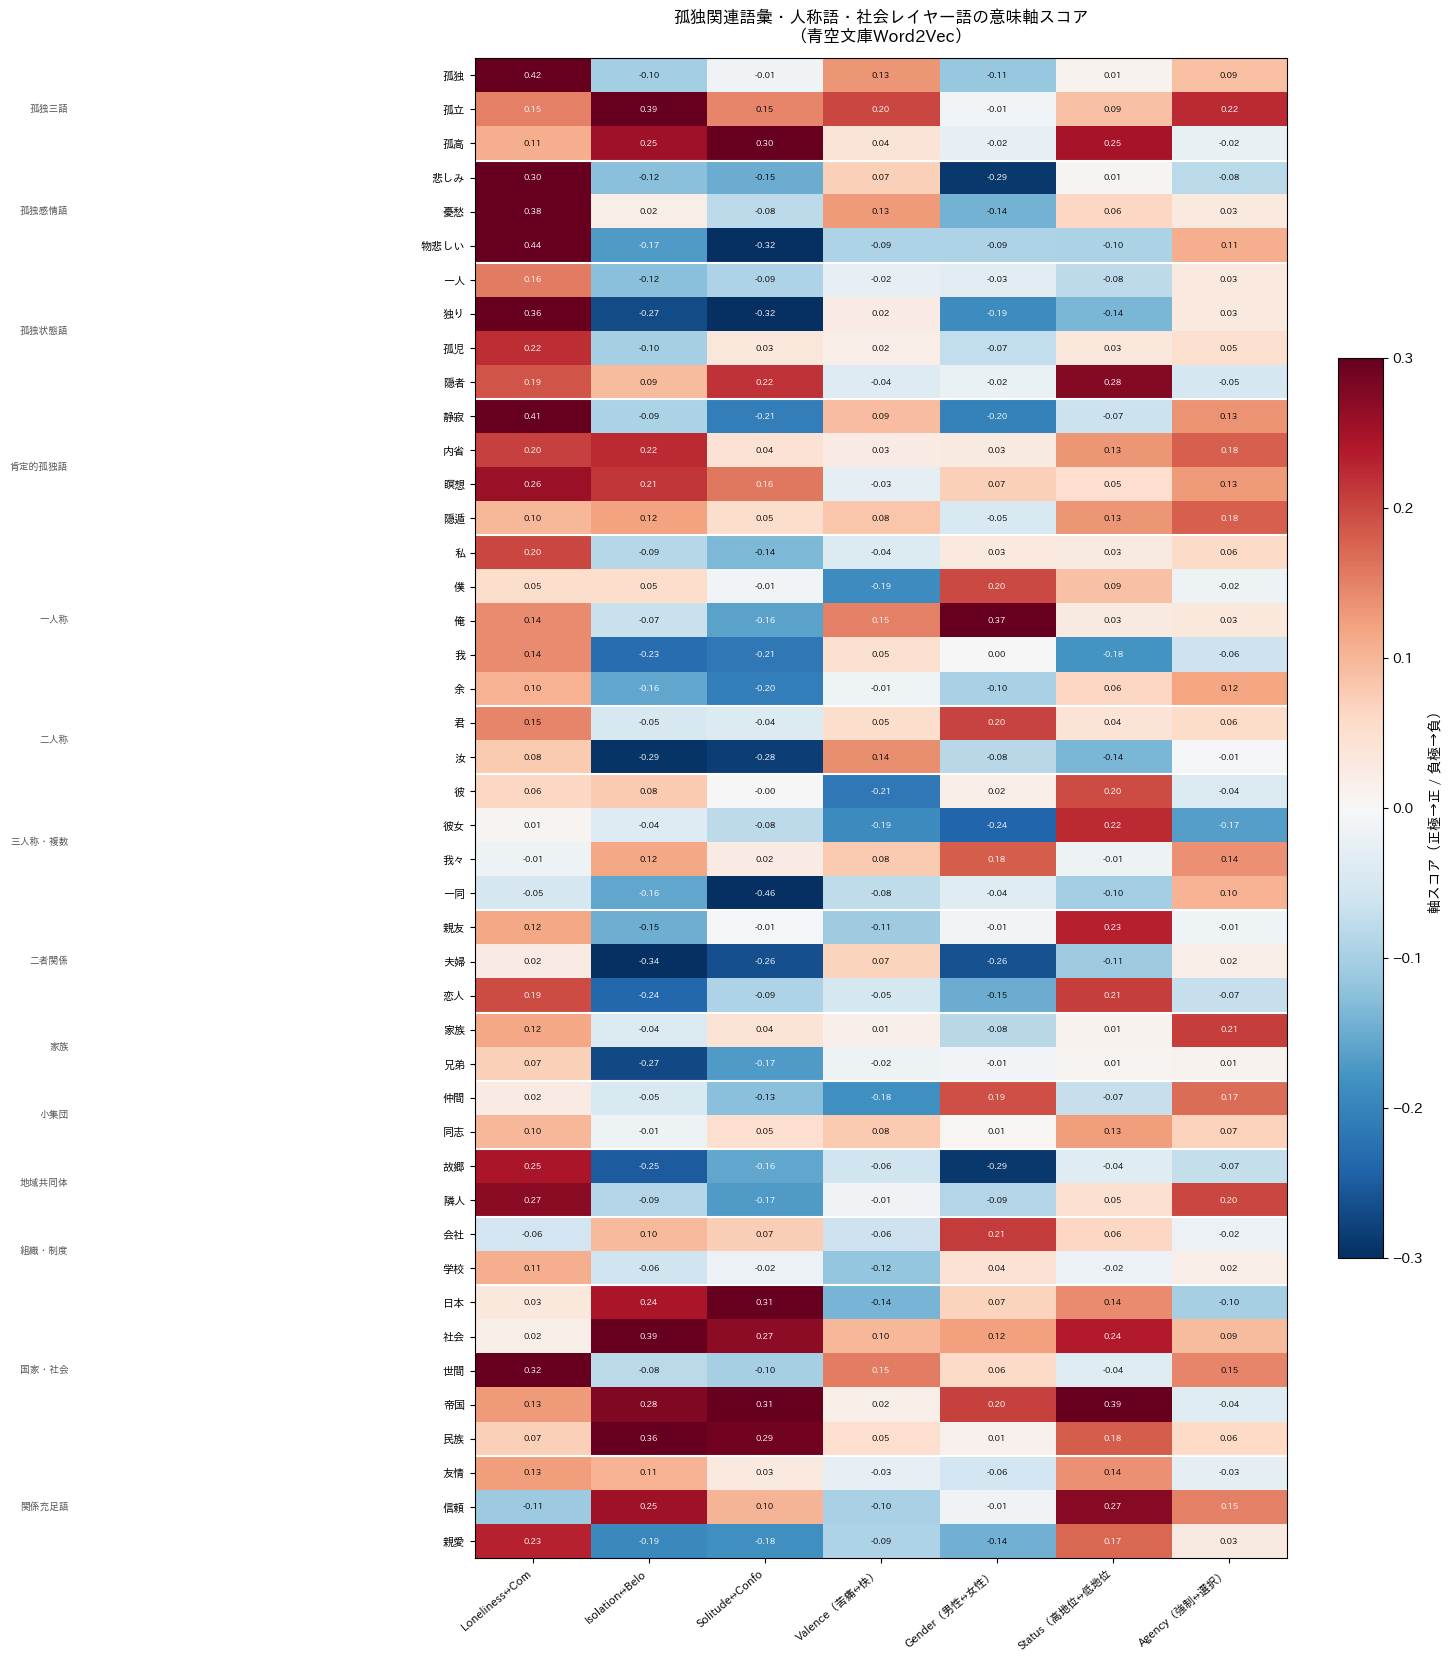

✅ ヒートマップ保存: /content/heatmap_axes.png


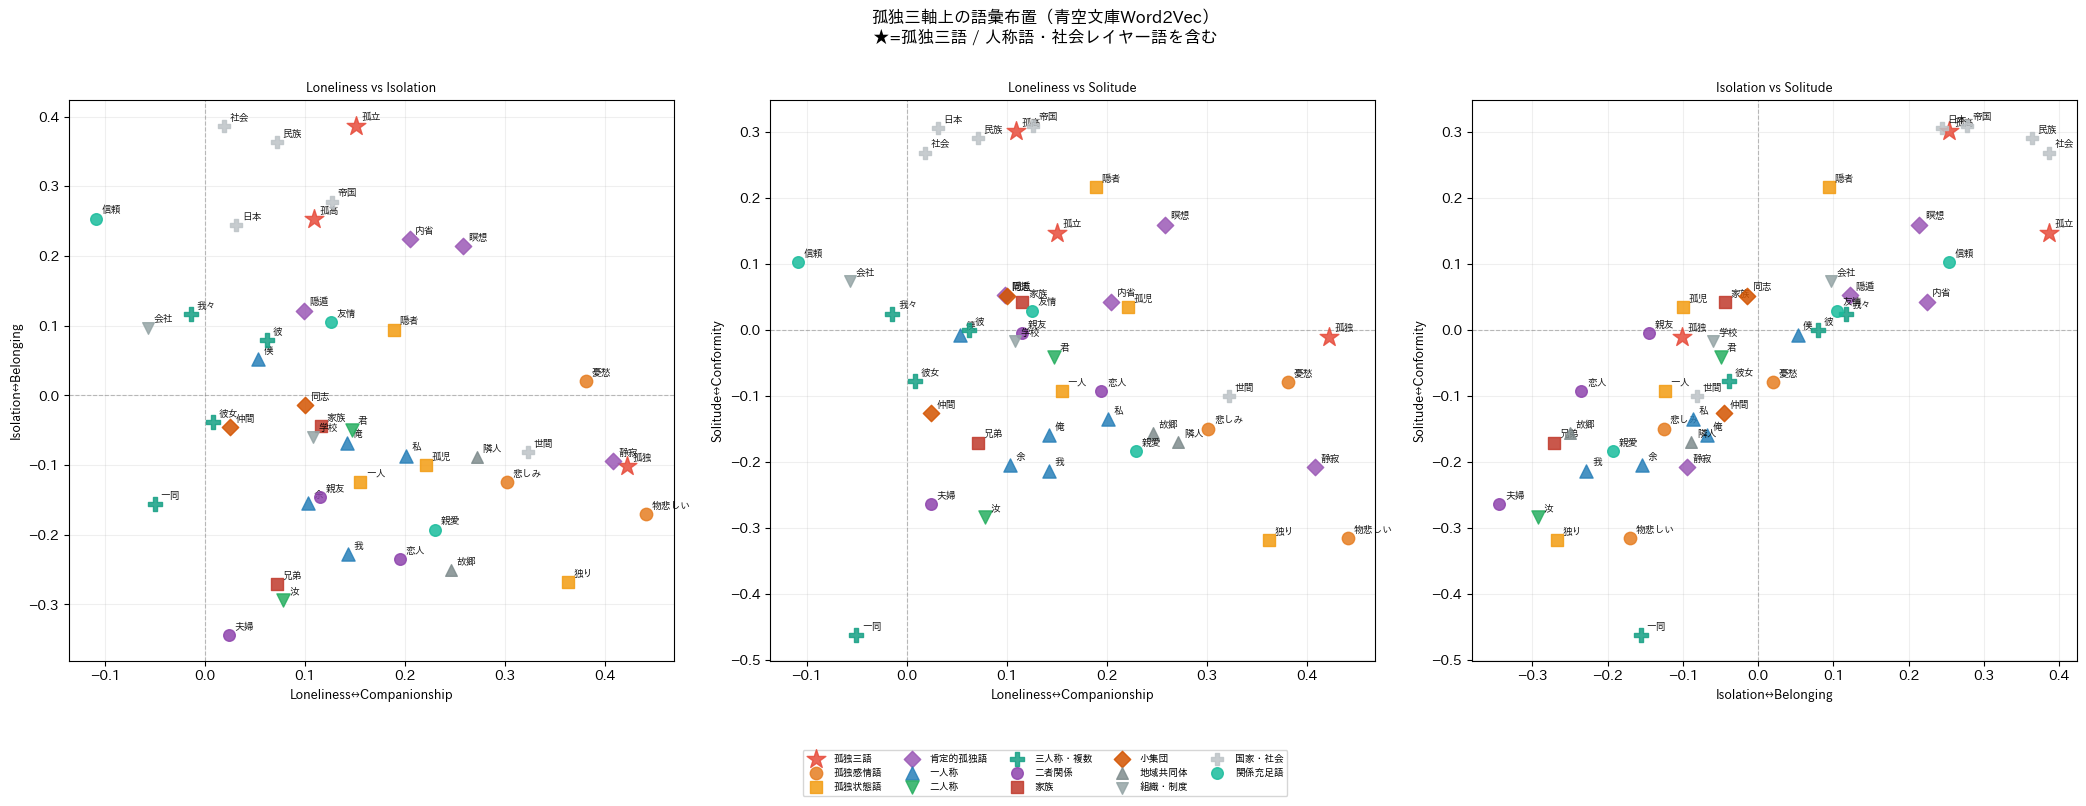

✅ 孤独三軸散布図保存: /content/scatter_loneliness_axes.png


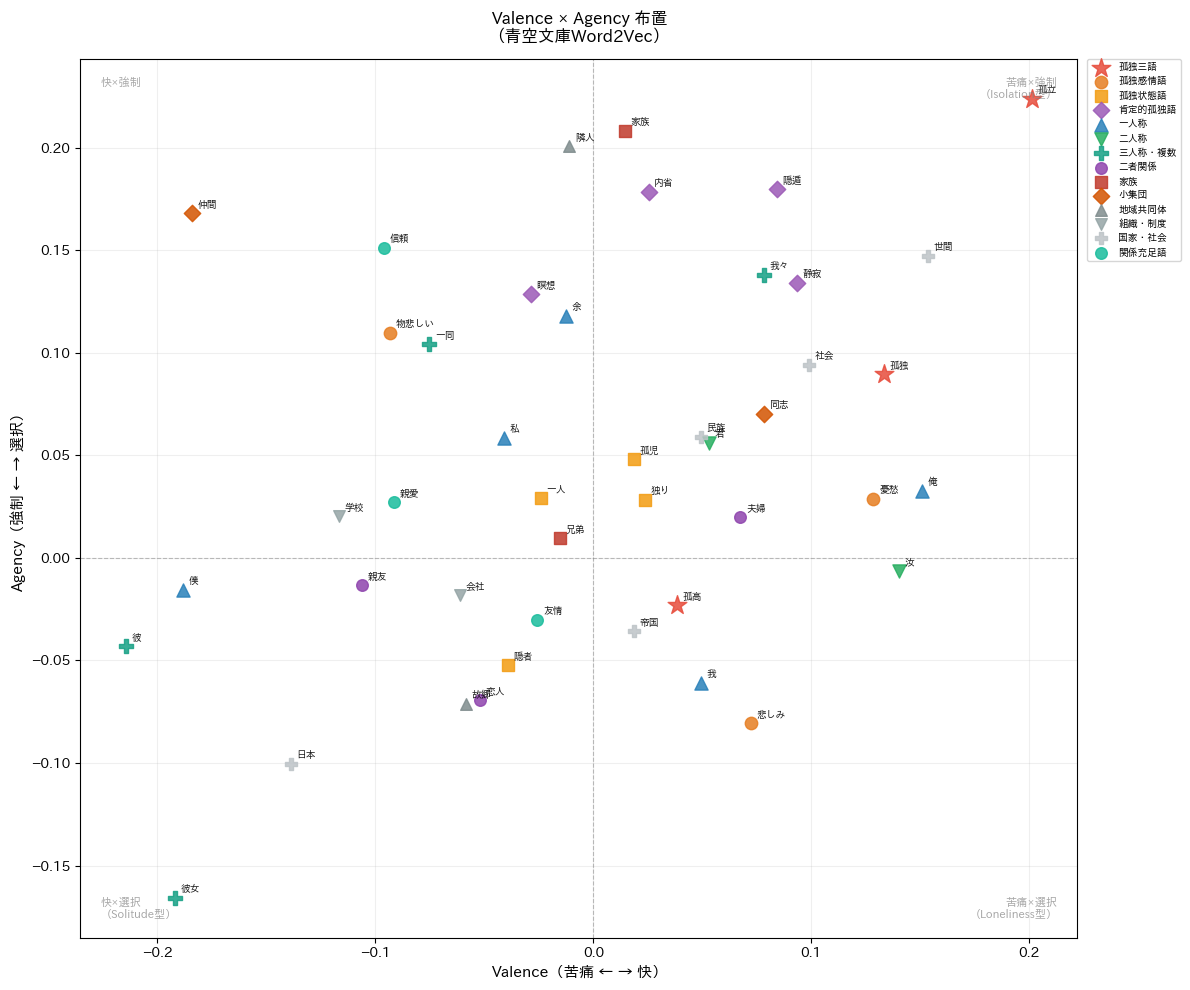

✅ Valence×Agency散布図保存: /content/scatter_valence_agency.png


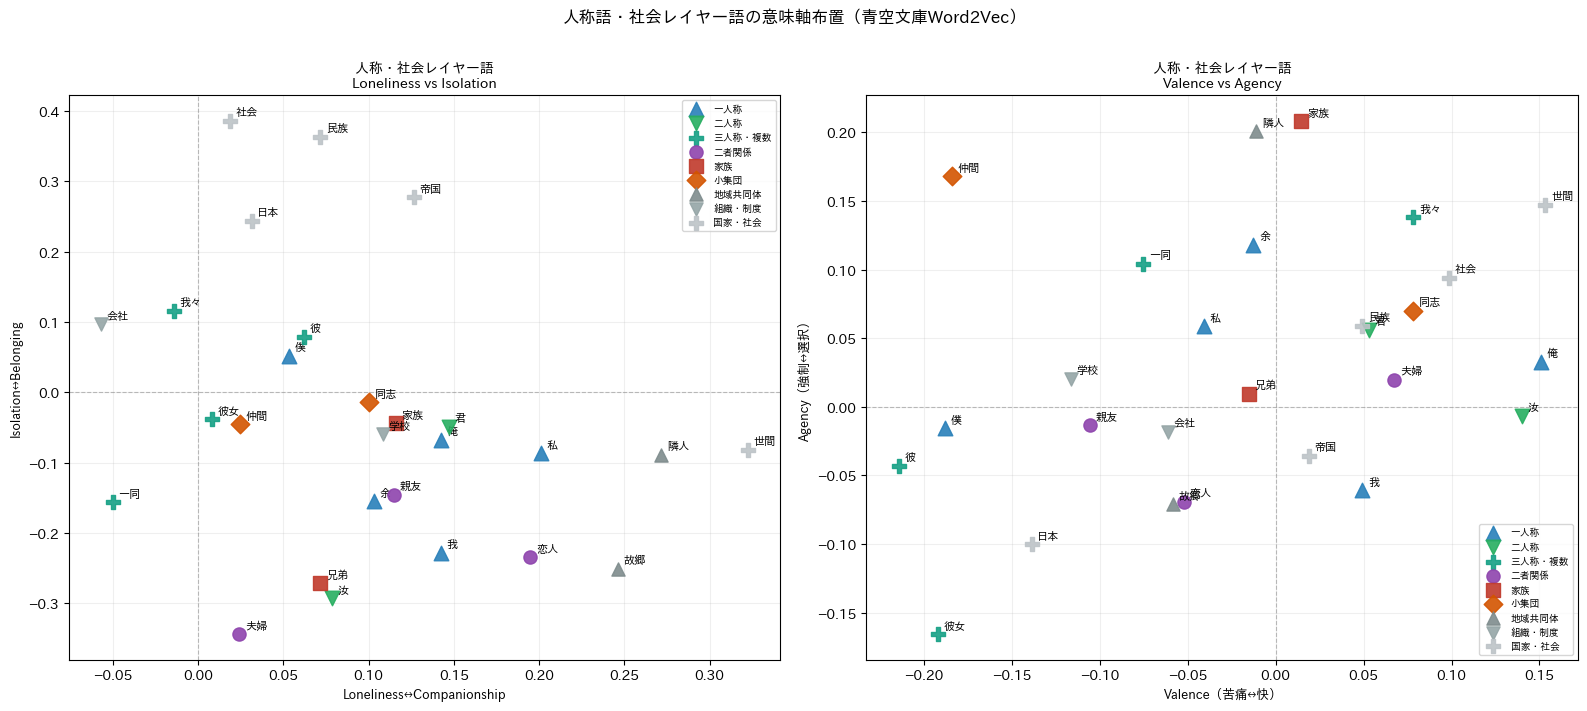

✅ 社会レイヤー散布図保存: /content/scatter_social_layers.png


【Step 5】軸の内的整合性チェック
同一極内の語同士の類似度平均（高いほど軸が安定）

Loneliness↔Companionship
  正極内部類似度: 0.543
  負極内部類似度: 0.533
  正負間類似度  : 0.521（低いほど軸が明確）

Isolation↔Belonging
  正極内部類似度: 0.735
  負極内部類似度: 0.659
  正負間類似度  : 0.557（低いほど軸が明確）

Solitude↔Conformity
  正極内部類似度: 0.704
  負極内部類似度: 0.511
  正負間類似度  : 0.494（低いほど軸が明確）

Valence（苦痛↔快）
  正極内部類似度: 0.539
  負極内部類似度: 0.570
  正負間類似度  : 0.456（低いほど軸が明確）

Agency（強制↔選択）
  正極内部類似度: 0.759
  負極内部類似度: 0.495
  正負間類似度  : 0.544（低いほど軸が明確）

Gender（男性↔女性）
  正極内部類似度: 0.365
  負極内部類似度: 0.436
  正負間類似度  : 0.380（低いほど軸が明確）

Status（高地位↔低地位）
  正極内部類似度: 0.505
  負極内部類似度: 0.533
  正負間類似度  : 0.488（低いほど軸が明確）

✅ 分析完了
出力ファイル:
  /content/heatmap_axes.png            （全軸ヒートマップ）
  /content/scatter_loneliness_axes.png （孤独三軸散布図）
  /content/scatter_valence_agency.png  （Valence×Agency散布図）
  /content/scatter_social_layers.png   （社会レイヤー語散布図）


In [282]:
# ============================================================
# Step 3: ターゲット語の各軸スコア計算
# ============================================================

def axis_score(word, axis_vec, wv):
    """単語の軸スコア（正極方向が正）"""
    if word not in wv:
        return np.nan
    word_vec = wv[word] / np.linalg.norm(wv[word])
    return float(np.dot(word_vec, axis_vec))


print("\n\n" + "=" * 60)
print("【Step 3】ターゲット語の軸スコア")
print("正値 → 正極（孤独・苦痛・強制・男性・高地位）寄り")
print("負値 → 負極（共在・快・選択・女性・低地位）寄り")
print("=" * 60)

score_data = {}
for word in found_targets:
    scores = {}
    for axis_name, axis_vec in axis_vectors.items():
        scores[axis_name] = axis_score(word, axis_vec, wv)
    score_data[word] = scores

score_df = pd.DataFrame(score_data).T
score_df.columns = [c[:12] for c in score_df.columns]
print(score_df.round(3).to_string())


# ============================================================
# Step 4: 可視化
# ============================================================

def plot_scatter_with_groups(ax_plot, ax_x_name, ax_y_name, found_targets,
                              axis_vectors, wv, title=""):
    """グループ別色分け散布図の共通描画関数"""
    if ax_x_name not in axis_vectors or ax_y_name not in axis_vectors:
        return

    for gname, gdata in TARGET_GROUPS.items():
        words_in_group = [w for w in gdata["words"] if w in found_targets]
        if not words_in_group:
            continue

        xs = [axis_score(w, axis_vectors[ax_x_name], wv) for w in words_in_group]
        ys = [axis_score(w, axis_vectors[ax_y_name], wv) for w in words_in_group]

        valid = [(w, x, y) for w, x, y in zip(words_in_group, xs, ys)
                 if not (np.isnan(x) or np.isnan(y))]
        if not valid:
            continue

        ws, vxs, vys = zip(*valid)
        ax_plot.scatter(vxs, vys,
                        c=gdata["color"],
                        marker=gdata["marker"],
                        s=gdata["size"],
                        alpha=0.85,
                        label=gname,
                        zorder=3)
        for w, x, y in valid:
            ax_plot.annotate(w, (x, y),
                             textcoords="offset points",
                             xytext=(4, 4), fontsize=7, alpha=0.9)

    ax_plot.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_plot.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_plot.set_xlabel(ax_x_name, fontsize=9)
    ax_plot.set_ylabel(ax_y_name, fontsize=9)
    ax_plot.set_title(title or f"{ax_x_name[:18]}\nvs {ax_y_name[:18]}", fontsize=9)
    ax_plot.grid(True, alpha=0.2)


# ── 4-1: ヒートマップ（全軸 × 全ターゲット語）──────────────
# グループ順にソートして表示
sorted_targets = [w for g in TARGET_GROUPS.values()
                  for w in g["words"] if w in found_targets]

score_data_sorted = {}
for word in sorted_targets:
    scores = {}
    for axis_name, axis_vec in axis_vectors.items():
        scores[axis_name] = axis_score(word, axis_vec, wv)
    score_data_sorted[word] = scores

score_df_sorted = pd.DataFrame(score_data_sorted).T
col_labels = [c[:14] for c in score_df_sorted.columns]

# グループ境界の位置を計算
group_boundaries = []
idx = 0
for gname, gdata in TARGET_GROUPS.items():
    count = len([w for w in gdata["words"] if w in found_targets])
    if count > 0:
        group_boundaries.append((idx, idx + count, gname))
        idx += count

fig, ax = plt.subplots(figsize=(16, max(8, len(sorted_targets) * 0.38)))
data = score_df_sorted.values
im = ax.imshow(data, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(len(score_df_sorted.index)))
ax.set_yticklabels(score_df_sorted.index, fontsize=8)

# グループ境界線を描画
for start, end, gname in group_boundaries:
    if start > 0:
        ax.axhline(start - 0.5, color='white', linewidth=1.5)
    # グループ名を左端に表示
    ax.text(-0.5, (start + end - 1) / 2, gname,
            ha='right', va='center', fontsize=7,
            color='#555555', transform=ax.get_yaxis_transform())

plt.colorbar(im, ax=ax, label='軸スコア（正極→正 / 負極→負）', shrink=0.6)
ax.set_title("孤独関連語彙・人称語・社会レイヤー語の意味軸スコア\n（青空文庫Word2Vec）",
             fontsize=12, pad=12)

# 値をセルに表示
for i in range(len(score_df_sorted.index)):
    for j in range(len(col_labels)):
        val = data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                    fontsize=6, color='white' if abs(val) > 0.15 else 'black')

plt.tight_layout()
plt.savefig("/content/heatmap_axes.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ ヒートマップ保存: /content/heatmap_axes.png")


# ── 4-2: 孤独三軸の散布図（3ペア）────────────────────────────
axis_pairs_l1 = [
    ("Loneliness↔Companionship", "Isolation↔Belonging",
     "Loneliness vs Isolation"),
    ("Loneliness↔Companionship", "Solitude↔Conformity",
     "Loneliness vs Solitude"),
    ("Isolation↔Belonging",      "Solitude↔Conformity",
     "Isolation vs Solitude"),
]

fig, axes_plot = plt.subplots(1, 3, figsize=(21, 7))
for ax_plot, (ax_x, ax_y, title) in zip(axes_plot, axis_pairs_l1):
    plot_scatter_with_groups(ax_plot, ax_x, ax_y, found_targets,
                             axis_vectors, wv, title=title)

# 凡例を最後のサブプロットに付ける
handles, labels = axes_plot[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5,
           fontsize=7, bbox_to_anchor=(0.5, -0.12))

plt.suptitle("孤独三軸上の語彙布置（青空文庫Word2Vec）\n"
             "★=孤独三語 / 人称語・社会レイヤー語を含む",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("/content/scatter_loneliness_axes.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ 孤独三軸散布図保存: /content/scatter_loneliness_axes.png")


# ── 4-3: Valence × Agency 散布図 ────────────────────────────
ax_x = "Valence（苦痛↔快）"
ax_y = "Agency（強制↔選択）"

if ax_x in axis_vectors and ax_y in axis_vectors:
    fig, ax = plt.subplots(figsize=(12, 10))
    plot_scatter_with_groups(ax, ax_x, ax_y, found_targets,
                             axis_vectors, wv)

    # 象限ラベル
    for (ha, va, x, y, txt) in [
        ('right', 'top',    0.98, 0.98, "苦痛×強制\n（Isolation型）"),
        ('left',  'top',    0.02, 0.98, "快×強制"),
        ('right', 'bottom', 0.98, 0.02, "苦痛×選択\n（Loneliness型）"),
        ('left',  'bottom', 0.02, 0.02, "快×選択\n（Solitude型）"),
    ]:
        ax.text(x, y, txt, transform=ax.transAxes,
                ha=ha, va=va, fontsize=8, color='gray', alpha=0.7)

    ax.set_xlabel("Valence（苦痛 ← → 快）", fontsize=11)
    ax.set_ylabel("Agency（強制 ← → 選択）", fontsize=11)
    ax.set_title("Valence × Agency 布置\n（青空文庫Word2Vec）", fontsize=12, pad=12)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=7, loc='upper left',
              bbox_to_anchor=(1.01, 1), borderaxespad=0)

    plt.tight_layout()
    plt.savefig("/content/scatter_valence_agency.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Valence×Agency散布図保存: /content/scatter_valence_agency.png")


# ── 4-4: 社会レイヤー × 孤独三軸（社会スケール別の布置）────
# 人称・社会レイヤー語だけを抽出して孤独三軸上に布置
social_groups = ["一人称", "二人称", "三人称・複数",
                 "二者関係", "家族", "小集団",
                 "地域共同体", "組織・制度", "国家・社会"]
social_words = [w for gn in social_groups
                for w in TARGET_GROUPS[gn]["words"] if w in found_targets]

if social_words and "Loneliness↔Companionship" in axis_vectors:
    fig, axes_plot = plt.subplots(1, 2, figsize=(16, 7))

    for ax_plot, (ax_x, ax_y, title) in zip(axes_plot, [
        ("Loneliness↔Companionship", "Isolation↔Belonging",
         "人称・社会レイヤー語\nLoneliness vs Isolation"),
        ("Valence（苦痛↔快）", "Agency（強制↔選択）",
         "人称・社会レイヤー語\nValence vs Agency"),
    ]):
        if ax_x not in axis_vectors or ax_y not in axis_vectors:
            continue
        for gname in social_groups:
            gdata = TARGET_GROUPS[gname]
            words = [w for w in gdata["words"] if w in found_targets]
            if not words:
                continue
            xs = [axis_score(w, axis_vectors[ax_x], wv) for w in words]
            ys = [axis_score(w, axis_vectors[ax_y], wv) for w in words]
            valid = [(w, x, y) for w, x, y in zip(words, xs, ys)
                     if not (np.isnan(x) or np.isnan(y))]
            if not valid:
                continue
            ws, vxs, vys = zip(*valid)
            ax_plot.scatter(vxs, vys,
                            c=gdata["color"], marker=gdata["marker"],
                            s=gdata["size"] + 20, alpha=0.9,
                            label=gname, zorder=3)
            for w, x, y in valid:
                ax_plot.annotate(w, (x, y), textcoords="offset points",
                                 xytext=(4, 4), fontsize=8)

        ax_plot.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
        ax_plot.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
        ax_plot.set_xlabel(ax_x, fontsize=9)
        ax_plot.set_ylabel(ax_y, fontsize=9)
        ax_plot.set_title(title, fontsize=10)
        ax_plot.grid(True, alpha=0.2)
        ax_plot.legend(fontsize=7, loc='best')

    plt.suptitle("人称語・社会レイヤー語の意味軸布置（青空文庫Word2Vec）",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig("/content/scatter_social_layers.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ 社会レイヤー散布図保存: /content/scatter_social_layers.png")


# ============================================================
# Step 5: 軸の内的整合性チェック（seed words同士のコサイン類似度）
# ============================================================

print("\n\n" + "=" * 60)
print("【Step 5】軸の内的整合性チェック")
print("同一極内の語同士の類似度平均（高いほど軸が安定）")
print("=" * 60)

for axis_name, axis_data in AXES.items():
    pos_words = [w for w in axis_data["pos"] if w in wv]
    neg_words = [w for w in axis_data["neg"] if w in wv]

    def mean_sim(words, wv):
        if len(words) < 2:
            return np.nan
        sims = [wv.similarity(a, b)
                for a, b in combinations(words, 2)]
        return np.mean(sims)

    pos_sim = mean_sim(pos_words, wv)
    neg_sim = mean_sim(neg_words, wv)

    # 正極と負極の分離度（正極語と負極語の類似度平均）
    cross_sims = []
    for p in pos_words:
        for n in neg_words:
            cross_sims.append(wv.similarity(p, n))
    cross_sim = np.mean(cross_sims) if cross_sims else np.nan

    print(f"\n{axis_name}")
    print(f"  正極内部類似度: {pos_sim:.3f}" if not np.isnan(pos_sim) else "  正極: 語数不足")
    print(f"  負極内部類似度: {neg_sim:.3f}" if not np.isnan(neg_sim) else "  負極: 語数不足")
    print(f"  正負間類似度  : {cross_sim:.3f}（低いほど軸が明確）"
          if not np.isnan(cross_sim) else "  正負間: 計算不能")

print("\n✅ 分析完了")
print("出力ファイル:")
print("  /content/heatmap_axes.png            （全軸ヒートマップ）")
print("  /content/scatter_loneliness_axes.png （孤独三軸散布図）")
print("  /content/scatter_valence_agency.png  （Valence×Agency散布図）")
print("  /content/scatter_social_layers.png   （社会レイヤー語散布図）")

---
## メモ・気づき

（このセルに分析中の気づき・疑問点を随時記録する）

-
-

## 次のステップ

- [ ] BCCWJが届いたら同じパイプラインを適用
- [ ] Sentence-BERT に切り替えて文レベル分析
- [ ] 孤独語を含む文の抽出・クラスタリング